# Rough Volatiility For Option Pricing

In [1]:
import time
import math
from pathlib import Path

import numba
from numba import njit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display
from scipy import optimize, stats

from quantfinlab.dataio import load_ohlcv, load_spx_option_pairs, load_option_chain, load_par_yield_curve
from quantfinlab.options.greeks import compute_greeks_numpy
from quantfinlab.options.iv import implied_vol, implied_vol_table
from quantfinlab.options.parity import infer_forwards_from_parity, infer_forwards_from_paired_quotes
from quantfinlab.options.quote_cleaning import attach_spot_from_series, clean_option_quotes, convert_quotes_to_usd_equivalent, surface_ready_quotes, wide_option_chain_to_long
from quantfinlab.options.rates_dividends import attach_rates, add_discount_factors, infer_carry_from_forward, infer_dividend_yield_from_forward
from quantfinlab.options.surface import fit_surface_panel, surface_grid, surface_iv, surface_iv_grid, surface_residuals
from quantfinlab.options.fourier import cos_prices
from quantfinlab.options.bsm import black76_price, black76_vega, forward_bsm_delta
from quantfinlab.calibration.fft_cos import calibration_weights, compare_fourier_models, fit_daily_models, residual_by_bucket
from quantfinlab.volatility.forecasting import DEFAULT_ARCH_MODEL_SPECS, future_realized_variance, rolling_arch_forecasts_weekly, score_forecasts_by_model
from quantfinlab.volatility.har import rolling_har_forecasts
from quantfinlab.volatility.realized import log_returns
from quantfinlab.plotting.curves import LAB_COLORS, set_plot_style

palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7", "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (7, 3.2),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
})
set_plot_style(palette)

data_dir = Path("../data")
if not data_dir.exists():
    data_dir = Path("data")

cache_dir = data_dir / "cache" / "project18"
cache_dir.mkdir(parents=True, exist_ok=True)

seed = 7
ann_days = 365.25
ann_trading = 252
q_values = [0.5, 1.0, 1.5, 2.0, 3.0]
lags = [1, 2, 4, 8, 16, 32]
horizons = [1, 5, 10, 21, 42, 63]
rng = np.random.default_rng(seed)


In [2]:
spx_spot = load_ohlcv(
    data_dir / "spx_daily_yfinance.csv",
    source="yfinance_csv",
    fields=("close", "raw_close", "open", "high", "low", "volume"),
)
spx_spot = spx_spot.loc["1990":].copy()

spx_pairs_raw = load_spx_option_pairs(
    data_dir / "spx_options_chain_202201_202312.parquet",
    annualization_days=ann_days,
    max_rel_spread=0.60,
    tau_min_days=7.0,
    tau_max_days=180.0,
    k_over_s_range=(0.62, 1.62),
    top_n_per_expiry=90,
    min_pairs_per_expiry=5,
)

us_par = load_par_yield_curve(
    data_dir / "par-yield-curve-rates-1990-2026.csv",
    source="us_treasury",
)


In [3]:
spx_ret = log_returns(spx_spot["close"]).dropna()
spx_var_1d = spx_ret.pow(2).rename("rv_1d")
spx_var_5d_sum = spx_var_1d.rolling(5).sum().rename("rv_5d_sum")
spx_var_10d_sum = spx_var_1d.rolling(10).sum().rename("rv_10d_sum")
spx_var_21d_sum = spx_var_1d.rolling(21).sum().rename("rv_21d_sum")
spx_var_5d = (spx_var_5d_sum / 5.0).rename("rv_5d_daily")
spx_var_10d = (spx_var_10d_sum / 10.0).rename("rv_10d_daily")
spx_var_21d = (spx_var_21d_sum / 21.0).rename("rv_21d_daily")
spx_var = spx_var_10d.dropna().rename("daily_variance_proxy")
spx_log_var_1d = np.log(spx_var_1d.clip(lower=1e-12)).rename("log_rv_1d")
spx_log_var_5d = np.log(spx_var_5d.dropna().clip(lower=1e-12)).rename("log_rv_5d")
spx_log_var_10d = np.log(spx_var_10d.dropna().clip(lower=1e-12)).rename("log_rv_10d")
spx_log_var_21d = np.log(spx_var_21d.dropna().clip(lower=1e-12)).rename("log_rv_21d")
spx_log_var = spx_log_var_10d.rename("log_variance")
spx_targets = future_realized_variance(spx_ret, horizons=tuple(horizons), annualization=ann_trading)

rv_summary = pd.DataFrame([{
    "start": spx_ret.index.min().date(),
    "end": spx_ret.index.max().date(),
    "observations": int(spx_ret.shape[0]),
    "annualized_mean_variance_1d": float(ann_trading * spx_var_1d.mean()),
    "median_annualized_volatility_10d": float(np.sqrt(ann_trading * spx_var).median()),
    "p95_annualized_volatility_10d": float(np.sqrt(ann_trading * spx_var).quantile(0.95)),
}])
display(rv_summary)


,start,end,observations,annualized_mean_variance_1d,median_annualized_volatility_10d,p95_annualized_volatility_10d
0,1990-01-03,2026-02-24,9102,0.032614,0.125971,0.312628


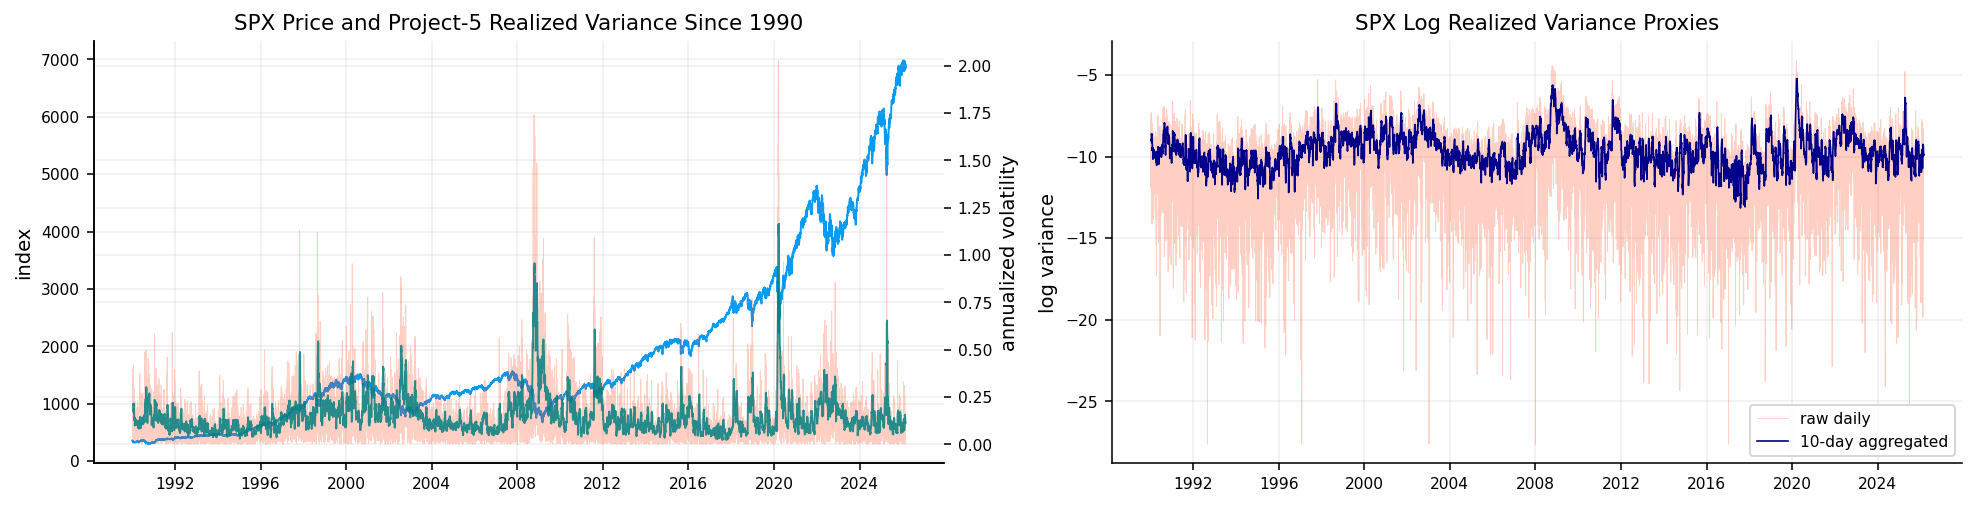

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), constrained_layout=True)
axes[0].plot(spx_spot.index, spx_spot["close"], lw=1.0, color=palette[0], label="SPX")
axes0b = axes[0].twinx()
axes0b.plot(spx_var_1d.index, np.sqrt(ann_trading * spx_var_1d), lw=0.45, alpha=0.25, color=palette[1], label="daily RV")
axes0b.plot(spx_var.index, np.sqrt(ann_trading * spx_var), lw=0.95, alpha=0.85, color=palette[3], label="10-day Project-5 RV")
axes[0].set_title("SPX Price and Project-5 Realized Variance Since 1990")
axes[0].set_ylabel("index")
axes0b.set_ylabel("annualized volatility")
axes[1].plot(spx_log_var_1d.index, spx_log_var_1d, lw=0.45, alpha=0.25, color=palette[1], label="raw daily")
axes[1].plot(spx_log_var.index, spx_log_var, lw=0.85, color=palette[2], label="10-day aggregated")
axes[1].set_title("SPX Log Realized Variance Proxies")
axes[1].set_ylabel("log variance")
axes[1].legend()
plt.show()


In [5]:
def fgn_covariance(h, n):
    k = np.arange(int(n), dtype=float)
    return 0.5 * (np.abs(k + 1.0) ** (2.0 * h) - 2.0 * np.abs(k) ** (2.0 * h) + np.abs(k - 1.0) ** (2.0 * h))


def fbm_cholesky(h, n_steps, n_paths, seed):
    cov = fgn_covariance(float(h), int(n_steps))
    idx = np.abs(np.subtract.outer(np.arange(int(n_steps)), np.arange(int(n_steps))))
    mat = cov[idx] + 1e-12 * np.eye(int(n_steps))
    z = np.random.default_rng(int(seed)).standard_normal((int(n_steps), int(n_paths)))
    increments = np.linalg.cholesky(mat) @ z / (int(n_steps) ** float(h))
    paths = np.vstack([np.zeros((1, int(n_paths))), np.cumsum(increments, axis=0)])
    return pd.DataFrame(paths, index=np.linspace(0.0, 1.0, int(n_steps) + 1))


def path_moment_scaling(x, q_values, lags):
    values = np.asarray(x, dtype=float)
    rows = []
    for q in q_values:
        for lag in lags:
            lag = int(lag)
            if lag >= values.shape[0]:
                continue
            inc = values[lag:] - values[:-lag]
            moment = float(np.nanmean(np.abs(inc) ** float(q)))
            rows.append({"q": float(q), "lag": lag, "moment": moment, "log_lag": np.log(lag), "log_moment": np.log(moment)})
    return pd.DataFrame(rows)


In [6]:
fbm_h_values = [0.05, 0.10, 0.20, 0.50, 0.80]
fbm_paths = {}
fbm_scaling_rows = []
fbm_h_rows = []

for i, h0 in enumerate(fbm_h_values):
    fbm_paths[h0] = fbm_cholesky(h0, 512, 4, seed + i)
    scaling_h = path_moment_scaling(fbm_paths[h0].iloc[:, 0], q_values, lags)
    scaling_h["h_true"] = h0
    fbm_scaling_rows.append(scaling_h)
    for q, g in scaling_h.groupby("q"):
        beta, cov = np.polyfit(g["log_lag"], g["log_moment"], 1, cov=True)
        yhat = np.polyval(beta, g["log_lag"])
        ss_res = float(np.sum((g["log_moment"] - yhat) ** 2))
        ss_tot = float(np.sum((g["log_moment"] - g["log_moment"].mean()) ** 2))
        fbm_h_rows.append({"h_true": h0, "q": q, "slope": beta[0], "h_estimate": beta[0] / q, "standard_error": float(np.sqrt(cov[0, 0])), "r2": 1.0 - ss_res / ss_tot})

fbm_scaling = pd.concat(fbm_scaling_rows, ignore_index=True)
fbm_h_table = pd.DataFrame(fbm_h_rows)
display(fbm_h_table.groupby("h_true", as_index=False).agg(median_h=("h_estimate", "median"), mean_r2=("r2", "mean")))


,h_true,median_h,mean_r2
0,0.05,0.037069,0.976740
1,0.10,0.123190,0.993578
2,0.20,0.176987,0.990194
3,0.50,0.522184,0.997473
4,0.80,0.809222,0.999785


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\2139515692.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, ncol=2)


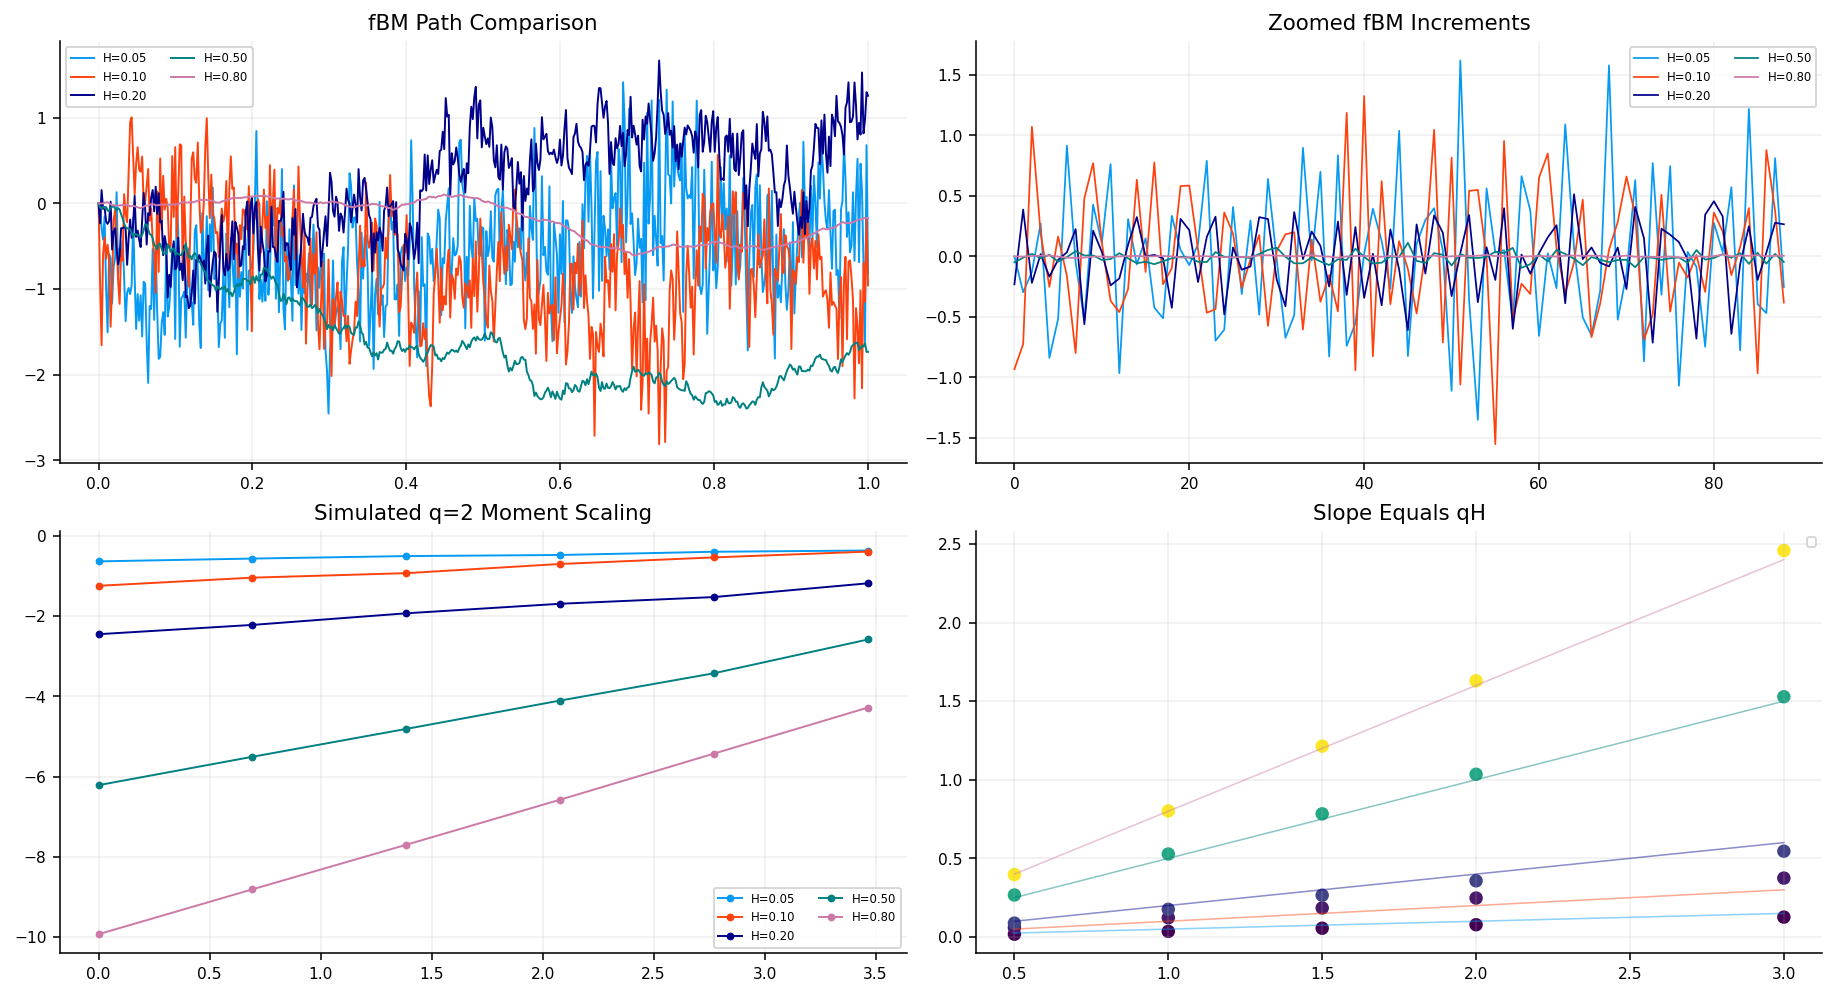

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
for i, h0 in enumerate(fbm_h_values):
    axes[0, 0].plot(fbm_paths[h0].index, fbm_paths[h0].iloc[:, 0], lw=1.0, color=palette[i], label=f"H={h0:.2f}")
    inc = fbm_paths[h0].iloc[:, 0].diff().iloc[1:90]
    axes[0, 1].plot(np.arange(len(inc)), inc, lw=0.9, color=palette[i], label=f"H={h0:.2f}")
for i, (h0, g) in enumerate(fbm_scaling[fbm_scaling["q"].eq(2.0)].groupby("h_true")):
    axes[1, 0].plot(g["log_lag"], g["log_moment"], marker="o", ms=3, lw=1.0, color=palette[i], label=f"H={h0:.2f}")
axes[1, 1].scatter(fbm_h_table["q"], fbm_h_table["slope"], c=fbm_h_table["h_true"], cmap="viridis", s=35)
for h0 in fbm_h_values:
    x = np.asarray(q_values, dtype=float)
    axes[1, 1].plot(x, h0 * x, lw=0.8, alpha=0.45)
axes[0, 0].set_title("fBM Path Comparison")
axes[0, 1].set_title("Zoomed fBM Increments")
axes[1, 0].set_title("Simulated q=2 Moment Scaling")
axes[1, 1].set_title("Slope Equals qH")
for ax in axes.ravel():
    ax.legend(fontsize=6, ncol=2)
plt.show()


In [8]:
def power_variation(x, q_values, lags):
    s = pd.Series(x).dropna()
    values = s.to_numpy(dtype=float)
    rows = []
    for q in q_values:
        for lag in lags:
            lag = int(lag)
            inc = values[lag:] - values[:-lag]
            inc = inc[np.isfinite(inc)]
            moment = float(np.mean(np.abs(inc) ** float(q)))
            rows.append({"q": float(q), "lag": lag, "moment": moment, "log_lag": np.log(lag), "log_moment": np.log(moment), "n": int(inc.size)})
    return pd.DataFrame(rows)


def hurst_ols(scaling):
    rows = []
    for q, g in scaling.groupby("q", sort=True):
        x = g["log_lag"].to_numpy(dtype=float)
        y = g["log_moment"].to_numpy(dtype=float)
        design = np.column_stack([np.ones(len(x)), x])
        beta, _, _, _ = np.linalg.lstsq(design, y, rcond=None)
        fitted = design @ beta
        resid = y - fitted
        ss_res = float(np.sum(resid * resid))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        sigma2 = ss_res / max(len(x) - 2, 1)
        cov = sigma2 * np.linalg.pinv(design.T @ design)
        rows.append({"q": float(q), "slope": float(beta[1]), "h": float(beta[1] / q), "standard_error": float(np.sqrt(max(cov[1, 1], 0.0))), "r2": float(1.0 - ss_res / ss_tot), "n": int(len(g))})
    return pd.DataFrame(rows)


def hurst_pooled(scaling, q_exclude=(3.0,), use_huber=True):
    data = scaling.copy()
    data["log_lag_fit"] = np.log(pd.to_numeric(data["lag"], errors="coerce").replace(0, np.nan))
    data["log_moment_fit"] = np.log(pd.to_numeric(data["moment"], errors="coerce").replace([0, np.inf, -np.inf], np.nan))
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["q", "log_lag_fit", "log_moment_fit"])
    if q_exclude:
        data = data[~data["q"].isin(q_exclude)].copy()
    if len(data) < 4:
        return {"H": np.nan, "se": np.nan, "r2": np.nan, "n": len(data), "method": "pooled"}
    q_unique = sorted(data["q"].unique())
    n, n_q = len(data), len(q_unique)
    q_idx = {q: i for i, q in enumerate(q_unique)}
    X = np.zeros((n, 1 + n_q), dtype=float)
    q_arr = data["q"].to_numpy(float)
    ll_arr = data["log_lag_fit"].to_numpy(float)
    X[:, 0] = q_arr * ll_arr
    for i, rq in enumerate(q_arr):
        X[i, 1 + q_idx[rq]] = 1.0
    y = data["log_moment_fit"].to_numpy(float)
    h_est, se, r2, method_used = np.nan, np.nan, np.nan, "ols"
    if use_huber:
        try:
            from sklearn.linear_model import HuberRegressor
            mdl = HuberRegressor(epsilon=1.35, max_iter=500, fit_intercept=False)
            mdl.fit(X, y)
            h_est = float(mdl.coef_[0])
            y_hat = mdl.predict(X)
            ss_res = float(np.sum((y - y_hat) ** 2))
            ss_tot = float(np.sum((y - np.mean(y)) ** 2))
            r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
            method_used = "huber"
        except Exception:
            use_huber = False
    if not use_huber or not np.isfinite(h_est):
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        h_est = float(beta[0])
        y_hat = X @ beta
        ss_res = float(np.sum((y - y_hat) ** 2))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
        dof = max(n - 1 - n_q, 1)
        sigma2 = ss_res / dof
        try:
            cov = sigma2 * np.linalg.pinv(X.T @ X)
            se = float(np.sqrt(max(cov[0, 0], 0.0)))
        except Exception:
            se = np.nan
        method_used = "ols"
    return {"H": h_est, "se": se, "r2": r2, "n": n, "method": method_used}


def hurst_multiscale(returns, windows=(1, 2, 3, 5, 10, 21), q_values=(0.5, 1.0, 1.5, 2.0), lags=(1, 2, 4, 8, 16, 32), eps=1e-12, use_huber=True):
    rv_1d = (returns * returns).clip(lower=float(eps))
    rows = []
    for w in windows:
        w = int(w)
        if w == 1:
            log_rv = np.log(rv_1d.clip(lower=float(eps))).rename(f"log_rv_{w}d")
        else:
            rv_w = rv_1d.rolling(w).sum() / float(w)
            log_rv = np.log(rv_w.dropna().clip(lower=float(eps))).rename(f"log_rv_{w}d")
        sc = power_variation(log_rv, list(q_values), list(lags))
        h_per_q = hurst_ols(sc)
        h_pooled = hurst_pooled(sc, use_huber=use_huber)
        h_q1 = float(h_per_q[h_per_q["q"].between(0.9, 1.1)]["h"].mean()) if not h_per_q.empty else np.nan
        rows.append({
            "window_days": w,
            "n_obs": int(log_rv.shape[0]),
            "H_pooled": float(h_pooled["H"]) if np.isfinite(float(h_pooled["H"])) else np.nan,
            "H_q1": h_q1,
            "H_median_per_q": float(h_per_q["h"].median()) if not h_per_q.empty else np.nan,
            "r2_pooled": float(h_pooled["r2"]) if h_pooled["r2"] is not None and np.isfinite(float(h_pooled["r2"])) else np.nan,
            "method": str(h_pooled["method"]),
        })
    df = pd.DataFrame(rows)
    short_mask = df["window_days"].le(10)
    df["main_H"] = float(df.loc[short_mask, "H_pooled"].median()) if short_mask.any() else float(df["H_pooled"].median())
    return df


In [9]:
log_var_proxies = {
    "raw daily squared-return RV": spx_log_var_1d,
    "rolling Project-5 RV 5d": spx_log_var_5d,
    "rolling Project-5 RV 10d": spx_log_var_10d,
    "rolling Project-5 RV 21d": spx_log_var_21d,
}
empirical_scaling_by_proxy = {}
empirical_hurst_by_proxy = {}
proxy_rows = []
for proxy_name, proxy_series in log_var_proxies.items():
    scaling_proxy = power_variation(proxy_series, q_values, lags)
    hurst_proxy = hurst_ols(scaling_proxy)
    empirical_scaling_by_proxy[proxy_name] = scaling_proxy.assign(proxy=proxy_name)
    empirical_hurst_by_proxy[proxy_name] = hurst_proxy.assign(proxy=proxy_name)
    proxy_rows.append({
        "source": proxy_name,
        "sample": f"{proxy_series.index.min().date()} to {proxy_series.index.max().date()}",
        "h": float(hurst_proxy["h"].median()),
        "standard_error": float(hurst_proxy["standard_error"].median()),
        "r2": float(hurst_proxy["r2"].mean()),
        "n": int(hurst_proxy["n"].sum()),
        "interpretation": "noisy diagnostic" if "raw daily" in proxy_name else "aggregated Project-5 RV proxy",
    })

roughness_proxy_table = pd.DataFrame(proxy_rows)
emp_scaling = empirical_scaling_by_proxy["rolling Project-5 RV 10d"]
emp_hurst = empirical_hurst_by_proxy["rolling Project-5 RV 10d"]

emp_pooled = hurst_pooled(emp_scaling, use_huber=True)
multi_window_table = hurst_multiscale(spx_ret, windows=(1, 2, 3, 5, 10, 21), q_values=tuple(q_values), lags=tuple(lags), use_huber=True)
h_rv_pooled = float(emp_pooled["H"]) if np.isfinite(float(emp_pooled["H"])) else float(emp_hurst["h"].median())
h_rv_multi = float(multi_window_table["main_H"].iloc[0])
h_rv = float(np.clip(h_rv_multi if np.isfinite(h_rv_multi) else h_rv_pooled, 0.03, 0.48))

# Non-overlapping block RV — checks that H estimate is not overlap-induced persistence
def _block_rv_series(ret, block_size):
    r2 = (ret * ret).to_numpy()
    nb = len(r2) // block_size
    return pd.Series([r2[i * block_size:(i + 1) * block_size].sum() for i in range(nb)])

block_rv_rows = []
for _bsz in [5, 10, 21]:
    _blk = _block_rv_series(spx_ret, _bsz)
    _log_blk = np.log(_blk.clip(1e-12))
    _sc = power_variation(_log_blk, q_values, lags)
    _hp = hurst_pooled(_sc, use_huber=True)
    block_rv_rows.append({"block_days": _bsz, "n_blocks": len(_blk), "H_pooled": float(_hp["H"]), "H_rolling": float(roughness_proxy_table[roughness_proxy_table["source"].str.contains(f"{_bsz}d")]["h"].iloc[0]) if len(roughness_proxy_table[roughness_proxy_table["source"].str.contains(f"{_bsz}d")]) > 0 else np.nan, "r2": float(_hp["r2"])})
block_rv_table = pd.DataFrame(block_rv_rows)

increment_acf = pd.DataFrame({
    "lag": np.arange(1, 31),
    "acf": [spx_log_var.diff().autocorr(lag=i) for i in range(1, 31)],
})

display(roughness_proxy_table.round(4))
display(emp_hurst.round(4))
display(pd.DataFrame([emp_pooled]).round(5))
display(multi_window_table.round(4))
display(block_rv_table.round(4))
print(f"h_rv = {h_rv:.4f}  (pooled 10d: {h_rv_pooled:.4f})")


,source,sample,h,standard_error,r2,n,interpretation
0,raw daily squared-return RV,1990-01-03 to 2026-02-24,0.0018,0.0055,0.0442,30,noisy diagnostic
1,rolling Project-5 RV 5d,1990-01-09 to 2026-02-24,0.2878,0.0748,0.8911,30,aggregated Project-5 RV proxy
2,rolling Project-5 RV 10d,1990-01-16 to 2026-02-24,0.4569,0.0652,0.9635,30,aggregated Project-5 RV proxy
3,rolling Project-5 RV 21d,1990-01-31 to 2026-02-24,0.6039,0.0310,0.9944,30,aggregated Project-5 RV proxy


,q,slope,h,standard_error,r2,n,proxy
0,0.5,0.2732,0.5463,0.0321,0.9476,6,rolling Project-5 RV 10d
1,1.0,0.4957,0.4957,0.0517,0.9584,6,rolling Project-5 RV 10d
2,1.5,0.6853,0.4569,0.0652,0.9650,6,rolling Project-5 RV 10d
3,2.0,0.8501,0.4250,0.0751,0.9697,6,rolling Project-5 RV 10d
4,3.0,1.1223,0.3741,0.0869,0.9766,6,rolling Project-5 RV 10d


,H,se,r2,n,method
0,0.47349,NaN,0.95963,24,huber


,window_days,n_obs,H_pooled,H_q1,H_median_per_q,r2_pooled,method,main_H
0,1,9102,0.0048,0.0023,0.0018,0.9997,huber,0.1313
1,2,9101,0.0447,0.0976,0.0815,0.9349,huber,0.1313
2,3,9100,0.1313,0.1923,0.1669,0.8613,huber,0.1313
3,5,9098,0.2881,0.3211,0.2878,0.8882,huber,0.1313
4,10,9093,0.4735,0.4957,0.4569,0.9596,huber,0.1313
5,21,9082,0.6068,0.6488,0.6039,0.9926,huber,0.1313


,block_days,n_blocks,H_pooled,H_rolling,r2
0,5,1820,0.0944,0.2878,0.9971
1,10,910,0.1183,0.4569,0.9690
2,21,433,0.1572,0.6039,0.9636


h_rv = 0.1313  (pooled 10d: 0.4735)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\1299751826.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6)


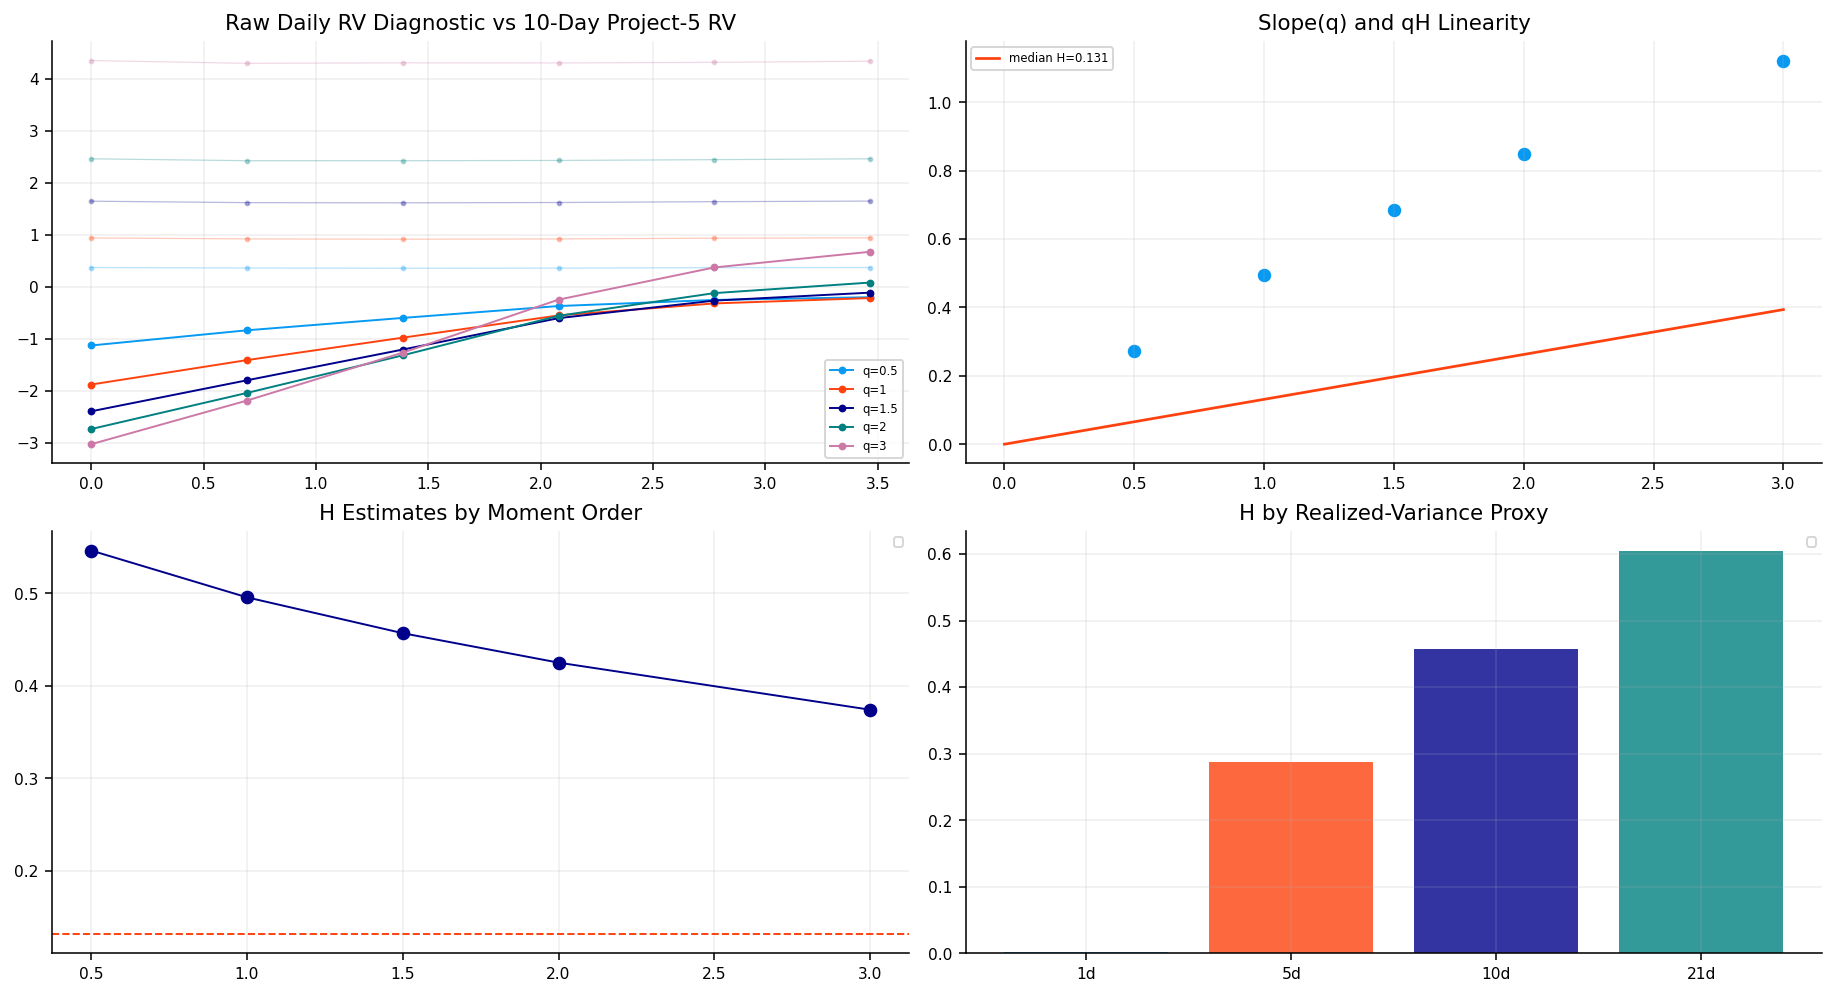

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
for i, (q, g) in enumerate(empirical_scaling_by_proxy["raw daily squared-return RV"].groupby("q", sort=True)):
    axes[0, 0].plot(g["log_lag"], g["log_moment"], marker="o", ms=2, lw=0.65, alpha=0.28, color=palette[i])
for i, (q, g) in enumerate(emp_scaling.groupby("q", sort=True)):
    axes[0, 0].plot(g["log_lag"], g["log_moment"], marker="o", ms=3, lw=1.0, color=palette[i], label=f"q={q:g}")
axes[0, 1].scatter(emp_hurst["q"], emp_hurst["slope"], s=35, color=palette[0])
x = np.linspace(0.0, max(q_values), 80)
axes[0, 1].plot(x, h_rv * x, color=palette[1], lw=1.4, label=f"median H={h_rv:.3f}")
axes[1, 0].plot(emp_hurst["q"], emp_hurst["h"], marker="o", lw=1.0, color=palette[2])
axes[1, 0].axhline(h_rv, color=palette[1], ls="--", lw=1.0)
for i, row in roughness_proxy_table.iterrows():
    axes[1, 1].bar(i, row["h"], color=palette[i % len(palette)], alpha=0.80)
axes[1, 1].set_xticks(range(len(roughness_proxy_table)))
axes[1, 1].set_xticklabels(["1d", "5d", "10d", "21d"])
axes[0, 0].set_title("Raw Daily RV Diagnostic vs 10-Day Project-5 RV")
axes[0, 1].set_title("Slope(q) and qH Linearity")
axes[1, 0].set_title("H Estimates by Moment Order")
axes[1, 1].set_title("H by Realized-Variance Proxy")
for ax in axes.ravel():
    ax.legend(fontsize=6)
plt.show()


In [11]:
def kernel_weights(h, lookback):
    j = np.arange(1, int(lookback) + 1, dtype=float)
    weights = j ** (float(h) - 0.5)
    weights = weights / weights.sum()
    return weights[::-1]


def kernel_weights_horizon(h, lookback, horizon):
    j = np.arange(1, int(lookback) + 1, dtype=float)
    weights = (j + float(horizon)) ** (float(h) + 0.5) - j ** (float(h) + 0.5)
    weights = np.maximum(weights, 0.0)
    weights = weights / weights.sum()
    return weights[::-1]


def kernel_forecasts(rv, targets, h, horizons, train_window, signal_step, annualization):
    v = pd.Series(rv).dropna().clip(lower=1e-12)
    values = v.to_numpy(dtype=float)
    records = []
    for pos in range(int(train_window), len(v) - int(max(horizons)), int(signal_step)):
        hist = values[pos - int(train_window) + 1:pos + 1]
        if len(hist) != int(train_window):
            continue
        for horizon in horizons:
            horizon = int(horizon)
            weights = kernel_weights_horizon(h, train_window, horizon)
            forecast_daily = float(np.sum(hist * weights))
            realized_sum = float(targets.loc[v.index[pos], f"realized_var_sum_{horizon}"])
            records.append({
                "date": v.index[pos],
                "model": "rough_kernel",
                "horizon": horizon,
                "forecast_var_daily": forecast_daily,
                "forecast_var_sum": forecast_daily * horizon,
                "forecast_var_ann": annualization * forecast_daily,
                "forecast_vol_ann": np.sqrt(annualization * forecast_daily),
                "realized_var_sum": realized_sum,
                "realized_var_ann": annualization * realized_sum / horizon,
                "realized_vol_ann": np.sqrt(annualization * realized_sum / horizon) if realized_sum >= 0 else np.nan,
            })
    return pd.DataFrame(records)


In [12]:
arch_specs = [
    {"name": "garch11_normal", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "gjr11_student", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"},
    {"name": "egarch11_normal", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
]

rough_fc = kernel_forecasts(spx_var, spx_targets, h_rv, horizons, train_window=1500, signal_step=21, annualization=ann_trading)
har_fc = rolling_har_forecasts(spx_ret, horizons=tuple(horizons), train_window=1500, refit_every=21, annualization=ann_trading, use_log=True, forecast_start="2018-01-01")

try:
    arch_fc = rolling_arch_forecasts_weekly(spx_ret, specs=arch_specs, horizons=tuple(horizons), train_window=1500, signal_step=42, forecast_start="2020-01-01", annualization=ann_trading, maxiter=120, simulations=100, seed=seed)
except Exception as exc:
    arch_fc = pd.DataFrame([{"date": pd.NaT, "model": "arch_unavailable", "horizon": np.nan, "error": str(exc)}])

forecast_data = pd.concat([rough_fc, har_fc, arch_fc.dropna(subset=["horizon"], how="any")], ignore_index=True, sort=False)
forecast_scores = score_forecasts_by_model(forecast_data)
score_rank = forecast_scores.sort_values(["horizon", "qlike_var"]).groupby("horizon", as_index=False).head(1)
win_counts = pd.concat([
    forecast_scores.sort_values(["horizon", "qlike_var"]).groupby("horizon", as_index=False).head(1).assign(metric="qlike_var"),
    forecast_scores.sort_values(["horizon", "rmse_var"]).groupby("horizon", as_index=False).head(1).assign(metric="rmse_var"),
    forecast_scores.sort_values(["horizon", "mae_var"]).groupby("horizon", as_index=False).head(1).assign(metric="mae_var"),
]).groupby(["metric", "model"], as_index=False).size()

display(forecast_scores.sort_values(["horizon", "qlike_var"]).round(6))
display(win_counts)


,model,horizon,qlike_var,rmse_var,mae_var,rmse_vol,mae_vol,corr_vol,n_obs
0,rough_kernel,1,-8.105938,0.000199,0.000133,0.126905,0.106926,0.119574,359
1,garch11_normal,1,-8.016799,0.000198,0.000135,0.108184,0.091938,0.563862,36
2,egarch11_normal,1,-8.016272,0.000203,0.000137,0.107815,0.093576,0.573411,36
3,gjr11_student,1,-7.896466,0.000203,0.000141,0.111980,0.094171,0.536213,36
4,har_rv,1,-6.097290,0.000222,0.000104,0.112719,0.080295,0.575256,94
5,har_rv,5,-6.577817,0.001143,0.000374,0.074411,0.047946,0.693915,94
6,egarch11_normal,5,-6.287714,0.001787,0.000627,0.101513,0.059138,0.680662,36
7,garch11_normal,5,-6.278677,0.001704,0.000609,0.097704,0.056859,0.699585,36
8,rough_kernel,5,-6.265616,0.001468,0.000631,0.109714,0.078851,0.263733,359
9,gjr11_student,5,-6.088571,0.001727,0.000645,0.101089,0.060236,0.648584,36


,metric,model,size
0,mae_var,har_rv,6
1,qlike_var,garch11_normal,2
2,qlike_var,har_rv,2
3,qlike_var,rough_kernel,2
4,rmse_var,garch11_normal,1
5,rmse_var,har_rv,2
6,rmse_var,rough_kernel,3


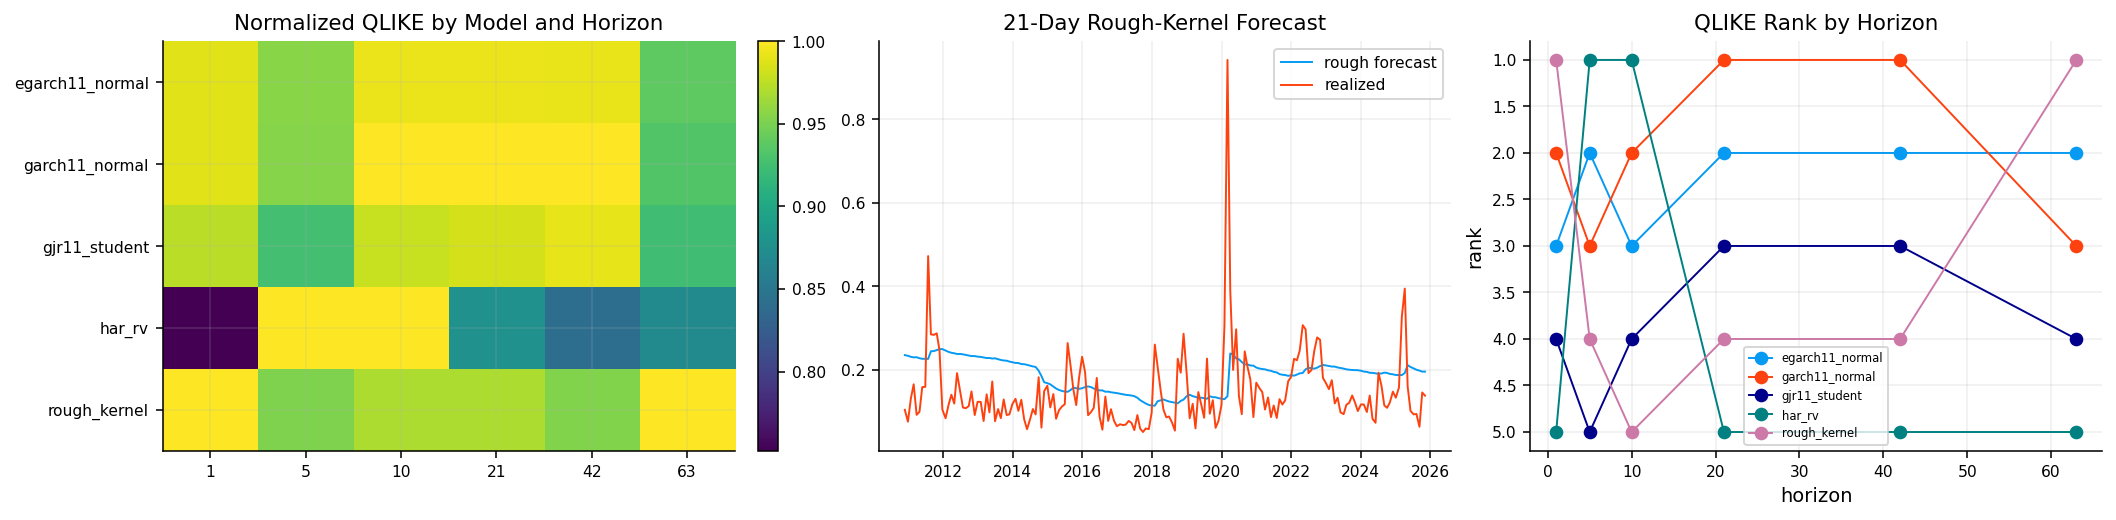

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
heat = forecast_scores.pivot_table(index="model", columns="horizon", values="qlike_var", aggfunc="mean")
heat_norm = heat.div(heat.min(axis=0), axis=1)
im = axes[0].imshow(heat_norm.to_numpy(dtype=float), aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(heat.columns)))
axes[0].set_xticklabels(heat.columns)
axes[0].set_yticks(range(len(heat.index)))
axes[0].set_yticklabels(heat.index)
axes[0].set_title("Normalized QLIKE by Model and Horizon")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
path21 = forecast_data[(forecast_data["model"].eq("rough_kernel")) & (forecast_data["horizon"].eq(21))].tail(180)
axes[1].plot(path21["date"], path21["forecast_vol_ann"], lw=1.0, label="rough forecast")
axes[1].plot(path21["date"], path21["realized_vol_ann"], lw=1.0, label="realized")
axes[1].set_title("21-Day Rough-Kernel Forecast")
axes[1].legend()
rank_frame = forecast_scores.copy()
rank_frame["qlike_rank"] = rank_frame.groupby("horizon")["qlike_var"].rank(method="dense")
for i, (model, g) in enumerate(rank_frame.groupby("model", sort=True)):
    axes[2].plot(g["horizon"], g["qlike_rank"], marker="o", lw=1.0, color=palette[i], label=model)
axes[2].invert_yaxis()
axes[2].set_title("QLIKE Rank by Horizon")
axes[2].set_xlabel("horizon")
axes[2].set_ylabel("rank")
axes[2].legend(fontsize=6)
plt.show()


In [14]:
option_dates = pd.DatetimeIndex(pd.to_datetime(spx_pairs_raw["date"].dropna().unique())).sort_values()
monthly_dates = pd.Series(option_dates).groupby(pd.Series(option_dates).dt.to_period("M")).last().to_list()
vol_on_option_dates = np.sqrt(ann_trading * spx_var).reindex(option_dates, method="nearest")
stress_dates = list(vol_on_option_dates.sort_values(ascending=False).head(8).index)
control_surface_dates = list(vol_on_option_dates.sort_values(ascending=True).head(4).index)
spaced_surface_dates = list(option_dates[np.unique(np.round(np.linspace(0, len(option_dates) - 1, min(24, len(option_dates)))).astype(int))])
surface_dates = pd.DatetimeIndex(sorted(set(monthly_dates).union(spaced_surface_dates).union(stress_dates).union(control_surface_dates)))
surface_dates = surface_dates[surface_dates.isin(option_dates)]

spx_pairs = spx_pairs_raw[spx_pairs_raw["date"].isin(surface_dates)].copy()
spx_pairs["dte_days"] = spx_pairs["tau"] * ann_days
spx_pairs["moneyness"] = spx_pairs["strike"] / spx_pairs["spot"]

rate_start = spx_pairs["date"].min() - pd.Timedelta(days=30)
rate_end = spx_pairs["date"].max()
us_par_options = us_par.loc[(us_par.index >= rate_start) & (us_par.index <= rate_end)].copy()

spx_pairs = attach_rates(spx_pairs, us_par_options, date_col="date", tau_col="tau", out_col="rate")
spx_pairs = add_discount_factors(spx_pairs, rate_col="rate", tau_col="tau", out_col="discount_factor")
forward_table = infer_forwards_from_paired_quotes(spx_pairs)
spx_pairs = spx_pairs.merge(forward_table[["date", "expiry", "forward", "implied_carry", "n_pairs", "parity_error_mad"]], on=["date", "expiry"], how="left")
spx_pairs = infer_dividend_yield_from_forward(spx_pairs, rate_col="rate", carry_col="implied_carry", out_col="implied_dividend_yield")

spx_long = wide_option_chain_to_long(spx_pairs, underlying_default="SPX")
for col in ["rate", "discount_factor", "forward", "implied_carry", "implied_dividend_yield", "n_pairs", "parity_error_mad"]:
    if col not in spx_long.columns and col in spx_pairs.columns:
        spx_long = spx_long.merge(spx_pairs[["date", "expiry", "strike", col]], on=["date", "expiry", "strike"], how="left")

clean_quotes, clean_steps = clean_option_quotes(
    spx_long,
    min_dte=7,
    max_dte=180,
    moneyness_range=(0.62, 1.62),
    max_relative_spread=0.60,
    closest_atm_pairs=70,
    min_pairs_per_expiry=5,
    annualization_days=ann_days,
)

for col in ["rate", "discount_factor", "forward", "implied_carry", "implied_dividend_yield", "n_pairs", "parity_error_mad"]:
    if col not in clean_quotes.columns and col in spx_pairs.columns:
        clean_quotes = clean_quotes.merge(spx_pairs[["date", "expiry", "strike", col]], on=["date", "expiry", "strike"], how="left")

display(clean_steps)
display(clean_quotes[["date", "expiry", "option_type", "spot", "strike", "tau", "mid", "forward", "rate"]].head(10))


,step,rows,removed
0,raw rows,269286,NaN
1,after schema normalization,269286,0.0
2,after positive price filter,269286,0.0
3,after bid/ask/spread filter,269286,0.0
4,after DTE filter,269286,0.0
5,after moneyness filter,269286,0.0
6,after ATM-pair selection,214444,54842.0
7,final rows,214444,0.0


,date,expiry,option_type,spot,strike,tau,mid,forward,rate
0,2022-01-03,2022-01-12,call,4795.57,4625.0,0.024641,171.85,4794.051044,0.0005
1,2022-01-03,2022-01-12,put,4795.57,4625.0,0.024641,3.95,4794.051044,0.0005
2,2022-01-03,2022-01-12,call,4795.57,4630.0,0.024641,168.25,4794.051044,0.0005
3,2022-01-03,2022-01-12,put,4795.57,4630.0,0.024641,4.15,4794.051044,0.0005
4,2022-01-03,2022-01-12,call,4795.57,4635.0,0.024641,163.45,4794.051044,0.0005
5,2022-01-03,2022-01-12,put,4795.57,4635.0,0.024641,4.35,4794.051044,0.0005
6,2022-01-03,2022-01-12,call,4795.57,4640.0,0.024641,158.70,4794.051044,0.0005
7,2022-01-03,2022-01-12,put,4795.57,4640.0,0.024641,4.60,4794.051044,0.0005
8,2022-01-03,2022-01-12,call,4795.57,4645.0,0.024641,153.95,4794.051044,0.0005
9,2022-01-03,2022-01-12,put,4795.57,4645.0,0.024641,4.85,4794.051044,0.0005


In [15]:
iv_quotes = implied_vol_table(
    clean_quotes,
    price_cols=("bid", "mid", "ask"),
    option_type_col="option_type",
    spot_col="spot",
    forward_col="forward",
    strike_col="strike",
    tau_col="tau",
    rate_col="rate",
    discount_col="discount_factor",
    model="black76",
    engine="auto",
)

iv_quotes = compute_greeks_numpy(iv_quotes.dropna(subset=["iv_mid"]).copy(), iv_col="iv_mid")

surface_quotes = surface_ready_quotes(
    iv_quotes,
    min_iv=0.02,
    max_iv=2.50,
    min_tau=7 / ann_days,
    max_tau=180 / ann_days,
    min_weight=0.05,
    max_weight=20.0,
)

coverage = surface_quotes.groupby("date").agg(quotes=("iv_mid", "size"), expiries=("expiry", "nunique"), median_spread=("relative_spread", "median"), median_iv=("iv_mid", "median")).reset_index()
display(coverage)
display(surface_quotes[["date", "expiry", "option_type", "strike", "k", "tau", "iv_mid", "surface_weight"]].head(10))


,date,quotes,expiries,median_spread,median_iv
0,2022-01-03,2939,21,0.014455,0.139032
1,2022-01-31,2800,20,0.014723,0.205393
2,2022-02-02,2940,21,0.016520,0.180581
3,2022-02-28,2908,21,0.015115,0.240580
4,2022-03-04,3183,23,0.026125,0.259087
5,2022-03-31,3075,22,0.023807,0.184119
6,2022-04-05,3189,23,0.013304,0.179744
7,2022-04-29,3026,22,0.015739,0.275974
8,2022-05-05,3204,23,0.020534,0.272724
9,2022-05-06,3176,23,0.020867,0.262823


,date,expiry,option_type,strike,k,tau,iv_mid,surface_weight
0,2022-01-03,2022-01-12,call,4625.0,-0.035899,0.024641,0.147003,0.115824
1,2022-01-03,2022-01-12,put,4625.0,-0.035899,0.024641,0.158925,0.057651
2,2022-01-03,2022-01-12,call,4630.0,-0.034819,0.024641,0.157572,0.143638
3,2022-01-03,2022-01-12,put,4630.0,-0.034819,0.024641,0.157107,0.064338
4,2022-01-03,2022-01-12,call,4635.0,-0.033740,0.024641,0.155625,0.139801
5,2022-01-03,2022-01-12,put,4635.0,-0.033740,0.024641,0.155177,0.071405
6,2022-01-03,2022-01-12,call,4640.0,-0.032661,0.024641,0.153994,0.139752
7,2022-01-03,2022-01-12,put,4640.0,-0.032661,0.024641,0.153565,0.163813
8,2022-01-03,2022-01-12,call,4645.0,-0.031584,0.024641,0.152229,0.132149
9,2022-01-03,2022-01-12,put,4645.0,-0.031584,0.024641,0.151817,0.090400


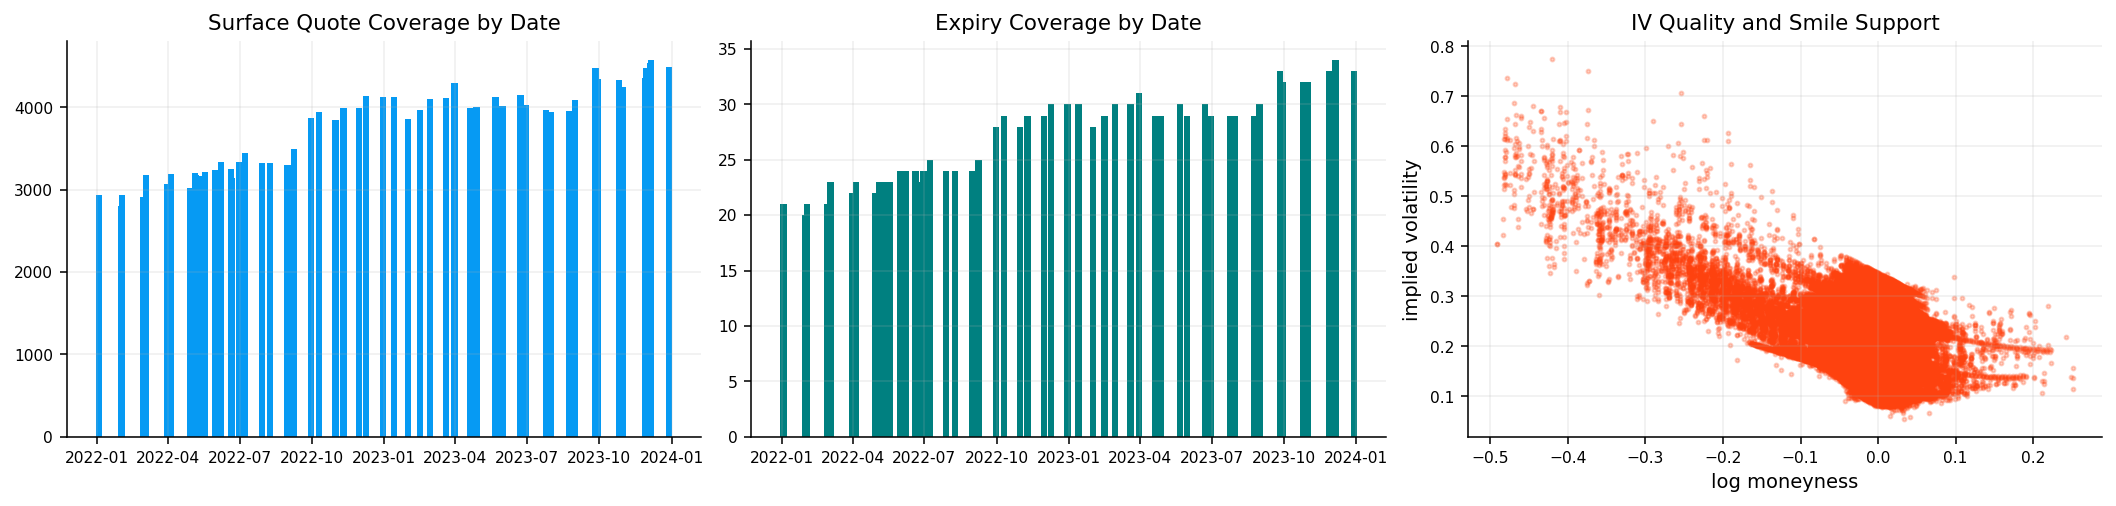

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), constrained_layout=True)
axes[0].bar(coverage["date"], coverage["quotes"], width=8, color=palette[0])
axes[0].set_title("Surface Quote Coverage by Date")
axes[1].bar(coverage["date"], coverage["expiries"], width=8, color=palette[3])
axes[1].set_title("Expiry Coverage by Date")
axes[2].scatter(surface_quotes["k"], surface_quotes["iv_mid"], s=4, alpha=0.25, color=palette[1])
axes[2].set_title("IV Quality and Smile Support")
axes[2].set_xlabel("log moneyness")
axes[2].set_ylabel("implied volatility")
plt.show()


In [17]:
surface_fit = fit_surface_panel(
    surface_quotes,
    date_col="date",
    k_col="k",
    tau_col="tau",
    iv_col="iv_mid",
    weight_col="surface_weight",
    visual_params=dict(n_k_basis=12, n_tau_basis=8, degree=3, lambda_k=3.0, lambda_tau=2.0),
    dupire_params=dict(n_k_basis=10, n_tau_basis=7, degree=3, lambda_k=12.0, lambda_tau=20.0),
    min_quotes=100,
    min_expiries=4,
)

fit_summary = surface_fit["fit_summary"].copy()
main_date = fit_summary[fit_summary["fit"].eq("visual")].sort_values(["weighted_rmse", "quote_count"], ascending=[True, False])["date"].iloc[0]
main_date = pd.Timestamp(main_date).normalize()
q_main = surface_quotes[surface_quotes["date"].eq(main_date)].copy()
fit_visual = surface_fit["visual_fits"][main_date]
k_grid = surface_grid(q_main, k_col="k", tau_col="tau", k_quantiles=(0.02, 0.98), tau_quantiles=(0.02, 0.98), n_k=65, n_tau=35, annualization_days=ann_days)
sigma_grid = surface_iv_grid(fit_visual, k_grid)
surface_err = surface_residuals(q_main, fits={"smooth": fit_visual}, k_col="k", tau_col="tau", iv_col="iv_mid")

display(fit_summary.sort_values(["date", "fit"]).round(5))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\1977237117.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(fit_summary.sort_values(["date", "fit"]).round(5))


,fit,target,quote_count,number_of_maturities,rmse,weighted_rmse,mae,median_abs_error,p95_abs_error,mean_residual,residual_std,k_min,k_max,tau_min,tau_max,date
0,dupire,log_total_variance,2939,21,0.00520,0.00388,0.00360,0.00256,0.00979,-0.00092,0.00512,-0.06503,0.06725,0.02464,0.48734,2022-01-03
1,visual,log_total_variance,2939,21,0.00342,0.00179,0.00192,0.00126,0.00524,-0.00011,0.00342,-0.06503,0.06725,0.02464,0.48734,2022-01-03
2,dupire,log_total_variance,2800,20,0.00557,0.00403,0.00365,0.00234,0.01322,-0.00101,0.00548,-0.09944,0.10390,0.02464,0.45175,2022-01-31
3,visual,log_total_variance,2800,20,0.00337,0.00237,0.00227,0.00132,0.00756,-0.00017,0.00336,-0.09944,0.10390,0.02464,0.45175,2022-01-31
4,dupire,log_total_variance,2940,21,0.00447,0.00366,0.00326,0.00250,0.01008,-0.00095,0.00437,-0.09105,0.08807,0.02464,0.48460,2022-02-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,visual,log_total_variance,4539,34,0.00712,0.00294,0.00257,0.00106,0.00774,0.00013,0.00712,-0.42772,0.12232,0.02190,0.48734,2023-12-05
110,dupire,log_total_variance,4574,34,0.00581,0.00275,0.00275,0.00169,0.00733,0.00049,0.00579,-0.42417,0.12588,0.02190,0.48460,2023-12-06
111,visual,log_total_variance,4574,34,0.00506,0.00210,0.00200,0.00107,0.00505,0.00027,0.00505,-0.42417,0.12588,0.02190,0.48460,2023-12-06
112,dupire,log_total_variance,4486,33,0.00900,0.00401,0.00340,0.00149,0.01093,0.00011,0.00900,-0.46941,0.10011,0.02738,0.47912,2023-12-29


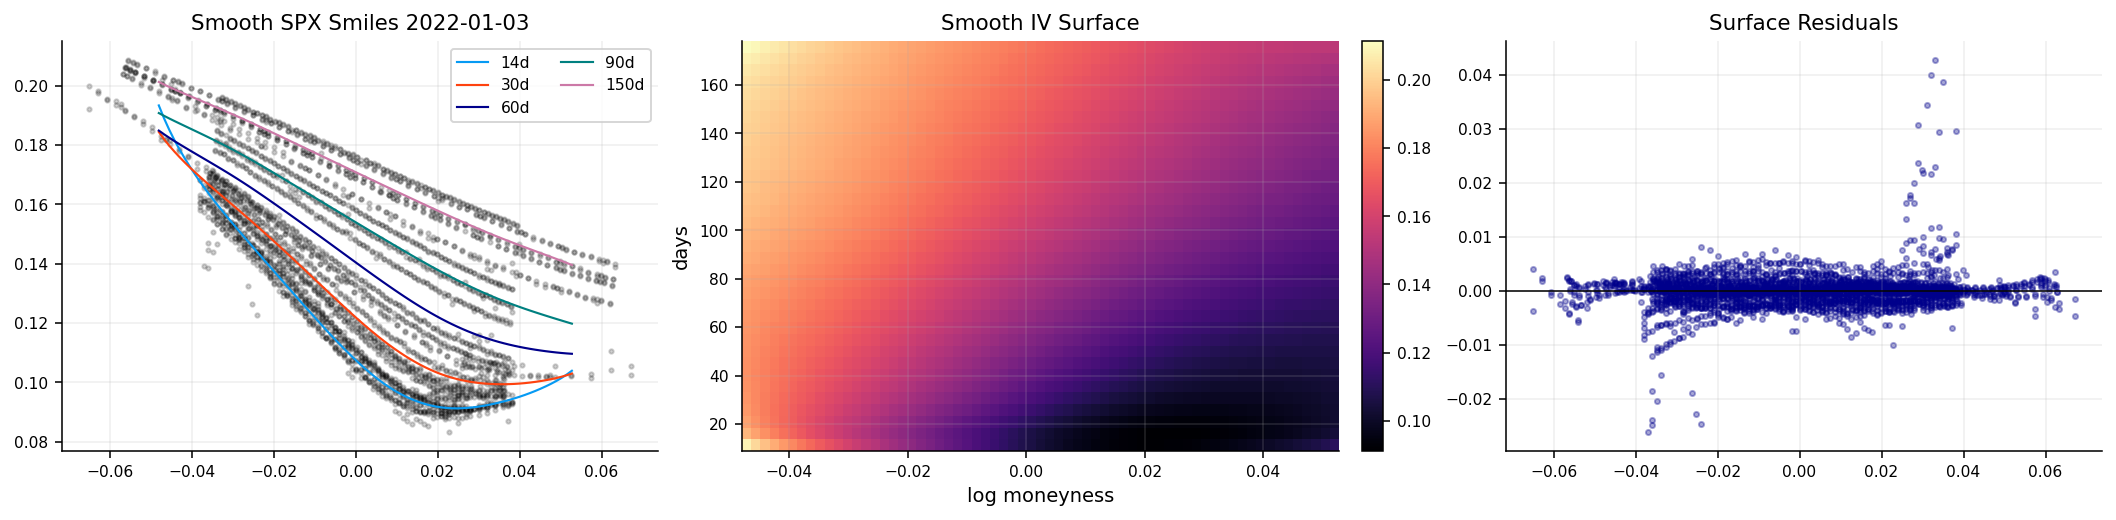

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
for i, d in enumerate([14, 30, 60, 90, 150]):
    tau = d / ann_days
    k_line = np.linspace(k_grid["k"].min(), k_grid["k"].max(), 80)
    axes[0].plot(k_line, surface_iv(fit_visual, k_line, np.full_like(k_line, tau)), lw=1.1, color=palette[i], label=f"{d}d")
axes[0].scatter(q_main["k"], q_main["iv_mid"], s=5, alpha=0.18, color="black")
axes[0].set_title(f"Smooth SPX Smiles {main_date.date()}")
axes[0].legend(ncol=2)
im = axes[1].imshow(sigma_grid, origin="lower", aspect="auto", extent=[k_grid["k"].min(), k_grid["k"].max(), k_grid["tau"].min() * ann_days, k_grid["tau"].max() * ann_days], cmap="magma")
axes[1].set_title("Smooth IV Surface")
axes[1].set_xlabel("log moneyness")
axes[1].set_ylabel("days")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[2].scatter(surface_err["k"], surface_err["residual_smooth"], s=7, alpha=0.35, color=palette[2])
axes[2].axhline(0.0, color="black", lw=0.8)
axes[2].set_title("Surface Residuals")
plt.show()


In [19]:
def atm_skew(q, fit, tau_values, dk=0.01):
    rows = []
    for tau in tau_values:
        left = float(surface_iv(fit, np.array([-dk]), np.array([tau]))[0])
        right = float(surface_iv(fit, np.array([dk]), np.array([tau]))[0])
        atm = float(surface_iv(fit, np.array([0.0]), np.array([tau]))[0])
        rows.append({"tau": float(tau), "tau_days": float(tau * ann_days), "atm_iv": atm, "atm_skew": (right - left) / (2.0 * dk), "n": int(len(q[np.isclose(q["tau"], tau, atol=3 / ann_days)]))})
    return pd.DataFrame(rows)


def power_law(psi, tau_min_days=None, tau_max_days=None, window=""):
    q = psi.replace([np.inf, -np.inf], np.nan).dropna(subset=["tau", "atm_skew"]).copy()
    if tau_min_days is not None:
        q = q[q["tau_days"].ge(float(tau_min_days))].copy()
    if tau_max_days is not None:
        q = q[q["tau_days"].le(float(tau_max_days))].copy()
    q = q[(q["tau"] > 0) & (q["atm_skew"].abs() > 0)]
    if len(q) < 3:
        return pd.DataFrame([{"window": window, "c": np.nan, "alpha": np.nan, "h_from_skew": np.nan, "r2": np.nan, "n": int(len(q))}])
    x = np.log(q["tau"].to_numpy(dtype=float))
    y = np.log(q["atm_skew"].abs().to_numpy(dtype=float))
    design = np.column_stack([np.ones(len(x)), x])
    beta, _, _, _ = np.linalg.lstsq(design, y, rcond=None)
    fitted = design @ beta
    ss_res = float(np.sum((y - fitted) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    alpha = -float(beta[1])
    return pd.DataFrame([{"window": window, "c": float(np.exp(beta[0])), "alpha": alpha, "h_from_skew": 0.5 - alpha, "r2": 1.0 - ss_res / ss_tot, "n": int(len(q))}])


In [20]:
skew_windows = {
    "short_1_7_45": (7, 45),
    "short_2_7_60": (7, 60),
    "medium_14_90": (14, 90),
    "old_14_150": (14, 150),
}

tau_values = np.array([7, 10, 14, 21, 30, 45, 60, 90, 120, 150], dtype=float) / ann_days
psi_main = atm_skew(q_main, fit_visual, tau_values)
skew_fit_main_by_window = pd.concat([
    power_law(psi_main, tau_min_days=lo, tau_max_days=hi, window=name)
    for name, (lo, hi) in skew_windows.items()
], ignore_index=True)
skew_fit_main = skew_fit_main_by_window[skew_fit_main_by_window["window"].eq("short_2_7_60")].copy()
if skew_fit_main["r2"].fillna(0.0).iloc[0] < 0.80:
    skew_fit_main = skew_fit_main_by_window.sort_values(["r2", "n"], ascending=[False, False]).head(1).copy()

skew_rows = []
for d, fit in surface_fit["visual_fits"].items():
    qd = surface_quotes[surface_quotes["date"].eq(d)].copy()
    psi_d = atm_skew(qd, fit, tau_values)
    for name, (lo, hi) in skew_windows.items():
        fit_d = power_law(psi_d, tau_min_days=lo, tau_max_days=hi, window=name)
        row = fit_d.iloc[0].to_dict()
        row["date"] = d
        skew_rows.append(row)
skew_history_all = pd.DataFrame(skew_rows).sort_values(["date", "window"])
skew_history = skew_history_all[skew_history_all["window"].eq("short_2_7_60")].copy()
valid_skew_dates = skew_history[(skew_history["r2"].ge(0.80)) & (skew_history["n"].ge(6))].copy()
skew_quality_summary = pd.DataFrame([{
    "window": "short_2_7_60",
    "median_h_all_dates": float(skew_history["h_from_skew"].median()),
    "median_h_high_quality_dates": float(valid_skew_dates["h_from_skew"].median()),
    "dates": int(len(skew_history)),
    "high_quality_dates": int(len(valid_skew_dates)),
    "rejected_dates": int(len(skew_history) - len(valid_skew_dates)),
}])

display(psi_main.round(5))
display(skew_fit_main_by_window[["window", "alpha", "h_from_skew", "r2", "n"]].round(4))
display(skew_history[["date", "window", "alpha", "h_from_skew", "r2", "n"]].round(4))
display(skew_quality_summary.round(4))


,tau,tau_days,atm_iv,atm_skew,n
0,0.01916,7.0,0.12127,-1.48860,139
1,0.02738,10.0,0.10650,-1.29444,279
2,0.03833,14.0,0.10757,-1.25572,420
3,0.05749,21.0,0.11365,-1.23274,420
4,0.08214,30.0,0.12196,-1.19868,280
5,0.12320,45.0,0.13212,-1.09725,140
6,0.16427,60.0,0.14050,-0.99334,0
7,0.24641,90.0,0.15403,-0.82747,140
8,0.32854,120.0,0.16431,-0.72585,0
9,0.41068,150.0,0.17091,-0.65616,140


,window,alpha,h_from_skew,r2,n
0,short_1_7_45,0.1004,0.3996,0.9039,5
1,short_2_7_60,0.1358,0.3642,0.8779,6
2,medium_14_90,0.2731,0.2269,0.9275,5
3,old_14_150,0.3359,0.1641,0.9557,7


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\2677019905.py:41: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(skew_history[["date", "window", "alpha", "h_from_skew", "r2", "n"]].round(4))


,date,window,alpha,h_from_skew,r2,n
1,2022-01-03,short_2_7_60,0.1358,0.3642,0.8779,6
5,2022-01-31,short_2_7_60,0.2657,0.2343,0.9969,6
9,2022-02-02,short_2_7_60,0.2146,0.2854,0.9889,6
13,2022-02-28,short_2_7_60,0.3878,0.1122,0.9994,6
17,2022-03-04,short_2_7_60,0.3519,0.1481,0.9928,6
21,2022-03-31,short_2_7_60,0.0950,0.4050,0.8660,6
25,2022-04-05,short_2_7_60,0.0747,0.4253,0.6954,6
29,2022-04-29,short_2_7_60,0.2996,0.2004,0.9797,6
33,2022-05-05,short_2_7_60,0.1939,0.3061,0.9012,6
37,2022-05-06,short_2_7_60,0.1398,0.3602,0.7573,6


,window,median_h_all_dates,median_h_high_quality_dates,dates,high_quality_dates,rejected_dates
0,short_2_7_60,0.4107,0.3645,57,34,23


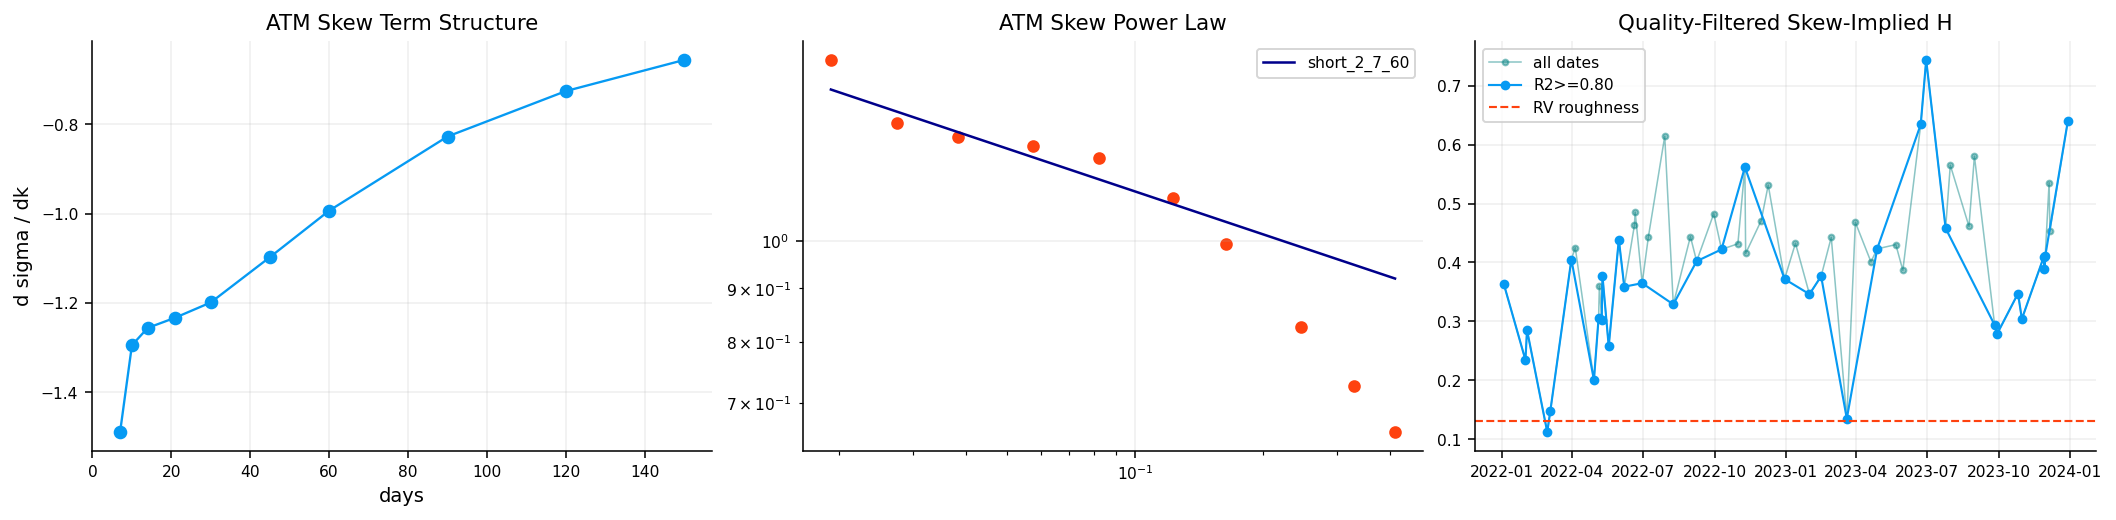

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
axes[0].plot(psi_main["tau_days"], psi_main["atm_skew"], marker="o", lw=1.2, color=palette[0])
axes[0].set_title("ATM Skew Term Structure")
axes[0].set_xlabel("days")
axes[0].set_ylabel("d sigma / dk")
axes[1].scatter(psi_main["tau"], psi_main["atm_skew"].abs(), s=30, color=palette[1])
xs = np.linspace(psi_main["tau"].min(), psi_main["tau"].max(), 80)
axes[1].plot(xs, skew_fit_main["c"].iloc[0] * xs ** (-skew_fit_main["alpha"].iloc[0]), color=palette[2], lw=1.3, label=str(skew_fit_main["window"].iloc[0]))
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("ATM Skew Power Law")
axes[1].legend()
axes[2].plot(skew_history["date"], skew_history["h_from_skew"], marker="o", ms=3, lw=0.8, alpha=0.45, color=palette[3], label="all dates")
axes[2].plot(valid_skew_dates["date"], valid_skew_dates["h_from_skew"], marker="o", ms=4, lw=1.1, color=palette[0], label="R2>=0.80")
axes[2].axhline(h_rv, color=palette[1], lw=1.1, ls="--", label="RV roughness")
axes[2].set_title("Quality-Filtered Skew-Implied H")
axes[2].legend()
plt.show()


In [22]:
def surface_calib_grid(quotes, fits, dte_targets=(7, 10, 14, 21, 30, 45, 60, 90, 120, 150), min_quotes_per_date=45, ann=ann_days):
    fit_map = {pd.Timestamp(k).normalize(): v for k, v in fits.items()}
    x = quotes.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce").dt.normalize()
    x["expiry"] = pd.to_datetime(x["expiry"], errors="coerce").dt.normalize()
    rows = []
    for d, day in x.groupby("date", sort=True):
        d = pd.Timestamp(d).normalize()
        fit = fit_map.get(d)
        if fit is None:
            continue
        k_support = pd.to_numeric(day["k"], errors="coerce")
        tau_support = pd.to_numeric(day["tau"], errors="coerce")
        ok = np.isfinite(k_support) & np.isfinite(tau_support)
        if ok.sum() < 20:
            continue
        k_lo, k_hi = np.nanquantile(k_support[ok], [0.02, 0.98])
        tau_lo, tau_hi = np.nanmin(tau_support[ok]), np.nanmax(tau_support[ok])
        spot = float(pd.to_numeric(day["spot"], errors="coerce").median())
        if not np.isfinite(spot) or spot <= 0:
            continue
        buf = 0.025
        k_low_d = max(k_lo + buf, -0.35)
        k_high_d = min(k_hi - buf, 0.25)
        if k_high_d <= k_low_d:
            k_low_d, k_high_d = max(k_lo, -0.35), min(k_hi, 0.25)
        spread = k_high_d - k_low_d
        n_k_nodes = 11 if spread > 0.30 else (9 if spread > 0.15 else 7)
        date_k_targets = np.linspace(k_low_d, k_high_d, n_k_nodes).tolist()
        if k_low_d < 0.0 < k_high_d and 0.0 not in date_k_targets:
            date_k_targets = sorted(set(date_k_targets) | {0.0})
        date_rows = []
        for dte in dte_targets:
            tau = float(dte) / float(ann)
            if tau < tau_lo - 4.0 / ann or tau > tau_hi + 4.0 / ann:
                continue
            near = day.assign(_gap=(pd.to_numeric(day["tau"], errors="coerce") - tau).abs()).sort_values("_gap").head(max(12, min(40, len(day) // 6)))
            rate = float(pd.to_numeric(near.get("rate", pd.Series(0.0, index=near.index)), errors="coerce").median())
            div = float(pd.to_numeric(near.get("implied_dividend_yield", near.get("dividend_yield", pd.Series(0.0, index=near.index))), errors="coerce").median())
            discount = float(pd.to_numeric(near.get("discount_factor", pd.Series(np.exp(-rate * tau), index=near.index)), errors="coerce").median())
            forward = float(pd.to_numeric(near.get("forward", pd.Series(spot * np.exp((rate - div) * tau), index=near.index)), errors="coerce").median())
            if not np.isfinite(forward) or forward <= 0:
                forward = spot * np.exp((rate - div) * tau)
            if not np.isfinite(discount) or discount <= 0:
                discount = np.exp(-rate * tau)
            iv_unc = pd.to_numeric(near.get("iv_uncertainty", pd.Series(np.nan, index=near.index)), errors="coerce")
            source_unc = float(np.nanmedian(iv_unc)) if iv_unc.notna().any() else 0.015
            source_unc = float(np.clip(source_unc, 0.008, 0.08))
            quality = float(np.nanmedian(pd.to_numeric(near.get("surface_weight", pd.Series(1.0, index=near.index)), errors="coerce")))
            quality = float(np.clip(quality if np.isfinite(quality) else 1.0, 0.25, 4.0))
            for kt in date_k_targets:
                if kt < k_lo - 0.025 or kt > k_hi + 0.025:
                    continue
                sigma = float(surface_iv(fit, np.array([kt]), np.array([tau]))[0])
                if not np.isfinite(sigma):
                    continue
                sigma = float(np.clip(sigma, 0.02, 4.0))
                strike = float(forward * np.exp(kt))
                option_type = "put" if kt < 0.0 else "call"
                mid = float(black76_price(option_type, forward, strike, tau, sigma, discount))
                vega = float(black76_vega(forward, strike, tau, sigma, discount))
                if not np.isfinite(mid) or not np.isfinite(vega) or mid <= 0 or vega <= 0:
                    continue
                scale = max(vega * source_unc, 1e-5 * spot, 1e-4 * mid)
                half = max(0.5 * scale, 2e-6 * spot, 1e-5 * mid)
                maturity_weight = float(np.clip(np.sqrt(30.0 / max(float(dte), 3.0)), 0.65, 1.65))
                moneyness_weight = float(np.clip(np.exp(-max(abs(kt) - 0.22, 0.0) / 0.25), 0.45, 1.15))
                date_rows.append({
                    "date": d, "expiry": d + pd.Timedelta(days=float(dte)), "target_source": "surface_grid",
                    "quote_id": f"{d.date()}_{dte}_{kt:.3f}_{option_type}", "spot": spot, "forward": forward,
                    "strike": strike, "option_type": option_type, "tau": tau, "dte_days": float(dte),
                    "rate": rate, "discount_factor": discount, "dividend_yield": div, "implied_dividend_yield": div,
                    "k": float(kt), "log_moneyness": float(np.log(strike / spot)), "moneyness": float(strike / spot),
                    "iv_mid": sigma, "iv_bid": max(sigma - source_unc, 1e-6), "iv_ask": sigma + source_unc,
                    "vega": vega, "mid": mid, "bid": max(mid - half, 0.0), "ask": mid + half,
                    "half_spread": half, "relative_spread": 2.0 * half / mid, "rel_spread": 2.0 * half / mid,
                    "iv_target_error": source_unc, "calib_scale_px": scale,
                    "quote_quality_weight": quality, "maturity_weight": maturity_weight, "moneyness_weight": moneyness_weight,
                    "obs_weight": quality * maturity_weight * moneyness_weight, "source_quote_count": int(len(day)),
                })
        if len(date_rows) >= min_quotes_per_date:
            out_day = pd.DataFrame(date_rows)
            out_day["obs_weight"] = out_day["obs_weight"] / max(float(np.nanmedian(out_day["obs_weight"])), 1e-12)
            rows.append(out_day)
    return calibration_weights(pd.concat(rows, ignore_index=True)) if rows else pd.DataFrame()


calibration_quotes = surface_calib_grid(
    surface_quotes,
    surface_fit["visual_fits"],
    min_quotes_per_date=45,
)

date_counts = calibration_quotes.groupby("date").size()
eligible_fit_dates = pd.DatetimeIndex(date_counts[date_counts >= 45].index).sort_values()
monthly_fit_dates = pd.Series(eligible_fit_dates).groupby(pd.Series(eligible_fit_dates).dt.to_period("M")).last().to_list()
vol_fit_dates = np.sqrt(ann_trading * spx_var).reindex(eligible_fit_dates, method="nearest")
stress_fit_dates = list(vol_fit_dates.sort_values(ascending=False).head(6).index)
control_fit_dates = list(vol_fit_dates.sort_values(ascending=True).head(4).index)
def evenly_spaced_dates(dates, n):
    dates = pd.DatetimeIndex(dates).sort_values()
    if len(dates) <= int(n):
        return list(dates)
    loc = np.unique(np.round(np.linspace(0, len(dates) - 1, int(n))).astype(int))
    return list(dates[loc])


spaced_fit_dates = evenly_spaced_dates(eligible_fit_dates, 24)
fit_dates = pd.DatetimeIndex(sorted(set(monthly_fit_dates).union(spaced_fit_dates).union(stress_fit_dates).union(control_fit_dates)))
fit_dates = fit_dates[fit_dates.isin(eligible_fit_dates)]
rough_priority_dates = pd.DatetimeIndex(sorted(set(stress_fit_dates).union(control_fit_dates).union([eligible_fit_dates[-1]]))).intersection(eligible_fit_dates)
rough_background_dates = [d for d in fit_dates if d not in set(rough_priority_dates)]
rough_fill_count = max(1, 18 - len(rough_priority_dates))
rough_fit_candidates = set(rough_priority_dates).union(evenly_spaced_dates(rough_background_dates, rough_fill_count))
rough_fit_dates = pd.DatetimeIndex(sorted(rough_fit_candidates))
rough_fit_dates = rough_fit_dates[rough_fit_dates.isin(eligible_fit_dates)]
heston_cache = cache_dir / "spx_heston_surface_grid_daily.parquet"
heston_fit_cache = cache_dir / "spx_heston_surface_grid_fit.parquet"


In [23]:
if heston_cache.exists() and heston_fit_cache.exists():
    heston_daily = pd.read_parquet(heston_cache)
    heston_prices = pd.read_parquet(heston_fit_cache)
else:
    heston_out = fit_daily_models(
        calibration_quotes,
        ["heston"],
        calibration_dates=fit_dates,
        min_quotes=80,
        max_nfev=80,
        engine="cpp",
        n_terms=160,
        truncation_width=16.0,
    )
    heston_daily = heston_out["params"]
    heston_prices = heston_out["fit"]
    heston_daily.to_parquet(heston_cache, index=False)
    heston_prices.to_parquet(heston_fit_cache, index=False)

heston_table = compare_fourier_models(daily=heston_daily)
heston_buckets = residual_by_bucket(heston_prices)
display(heston_daily.round(5))
display(heston_table.round(5))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\3151898688.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(heston_daily.round(5))


,model,date,success,nfev,runtime_sec,quotes,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,p0,p1,p2,p3,p4,feller_ratio
0,heston,2022-01-03,True,37,11.11105,80,0.42381,1.25085,0.00465,0.7750,NaN,0.54331,0.01280,4.26527,0.07553,1.60128,-0.68698,0.25129
1,heston,2022-01-31,True,24,10.63544,80,0.91599,2.23194,0.00805,0.5500,NaN,1.20163,0.06693,12.00000,0.06565,3.37697,-0.60233,0.13816
2,heston,2022-02-02,True,12,4.78645,80,0.76823,1.98318,0.00736,0.5625,NaN,1.00653,0.03781,9.94753,0.06000,2.49853,-0.62883,0.19122
3,heston,2022-02-28,True,14,3.73290,80,0.85625,2.39582,0.01057,0.4750,NaN,1.10421,0.09241,12.00000,0.07146,2.85501,-0.69212,0.21039
4,heston,2022-03-31,True,12,5.39115,100,0.96335,1.86731,0.00978,0.5200,1.71895,1.14542,0.03134,10.80840,0.06538,2.25274,-0.71222,0.27851
5,heston,2022-04-29,True,10,3.05116,80,1.70479,2.92045,0.01419,0.4250,NaN,2.37252,0.14557,12.00000,0.09149,4.00000,-0.58406,0.13724
6,heston,2022-05-05,True,8,2.51283,80,0.65653,2.07177,0.01070,0.6625,NaN,0.77727,0.11850,12.00000,0.07985,2.90385,-0.60129,0.22726
7,heston,2022-05-09,True,11,3.19299,80,1.13001,2.88896,0.01027,0.4125,NaN,1.49971,0.15720,12.00000,0.09700,4.00000,-0.47022,0.14551
8,heston,2022-05-10,True,8,2.98414,80,1.21169,2.96431,0.01048,0.3375,NaN,1.57884,0.14423,12.00000,0.09431,4.00000,-0.41440,0.14147
9,heston,2022-05-18,True,9,2.85762,80,0.92275,2.62972,0.00855,0.4000,NaN,1.15213,0.10452,12.00000,0.08614,2.74838,-0.50200,0.27369


,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,runtime_sec
0,heston,44,3780,1.0,0.86366,1.2401,0.01045,0.55642,1.58404,1.10742,195.80669


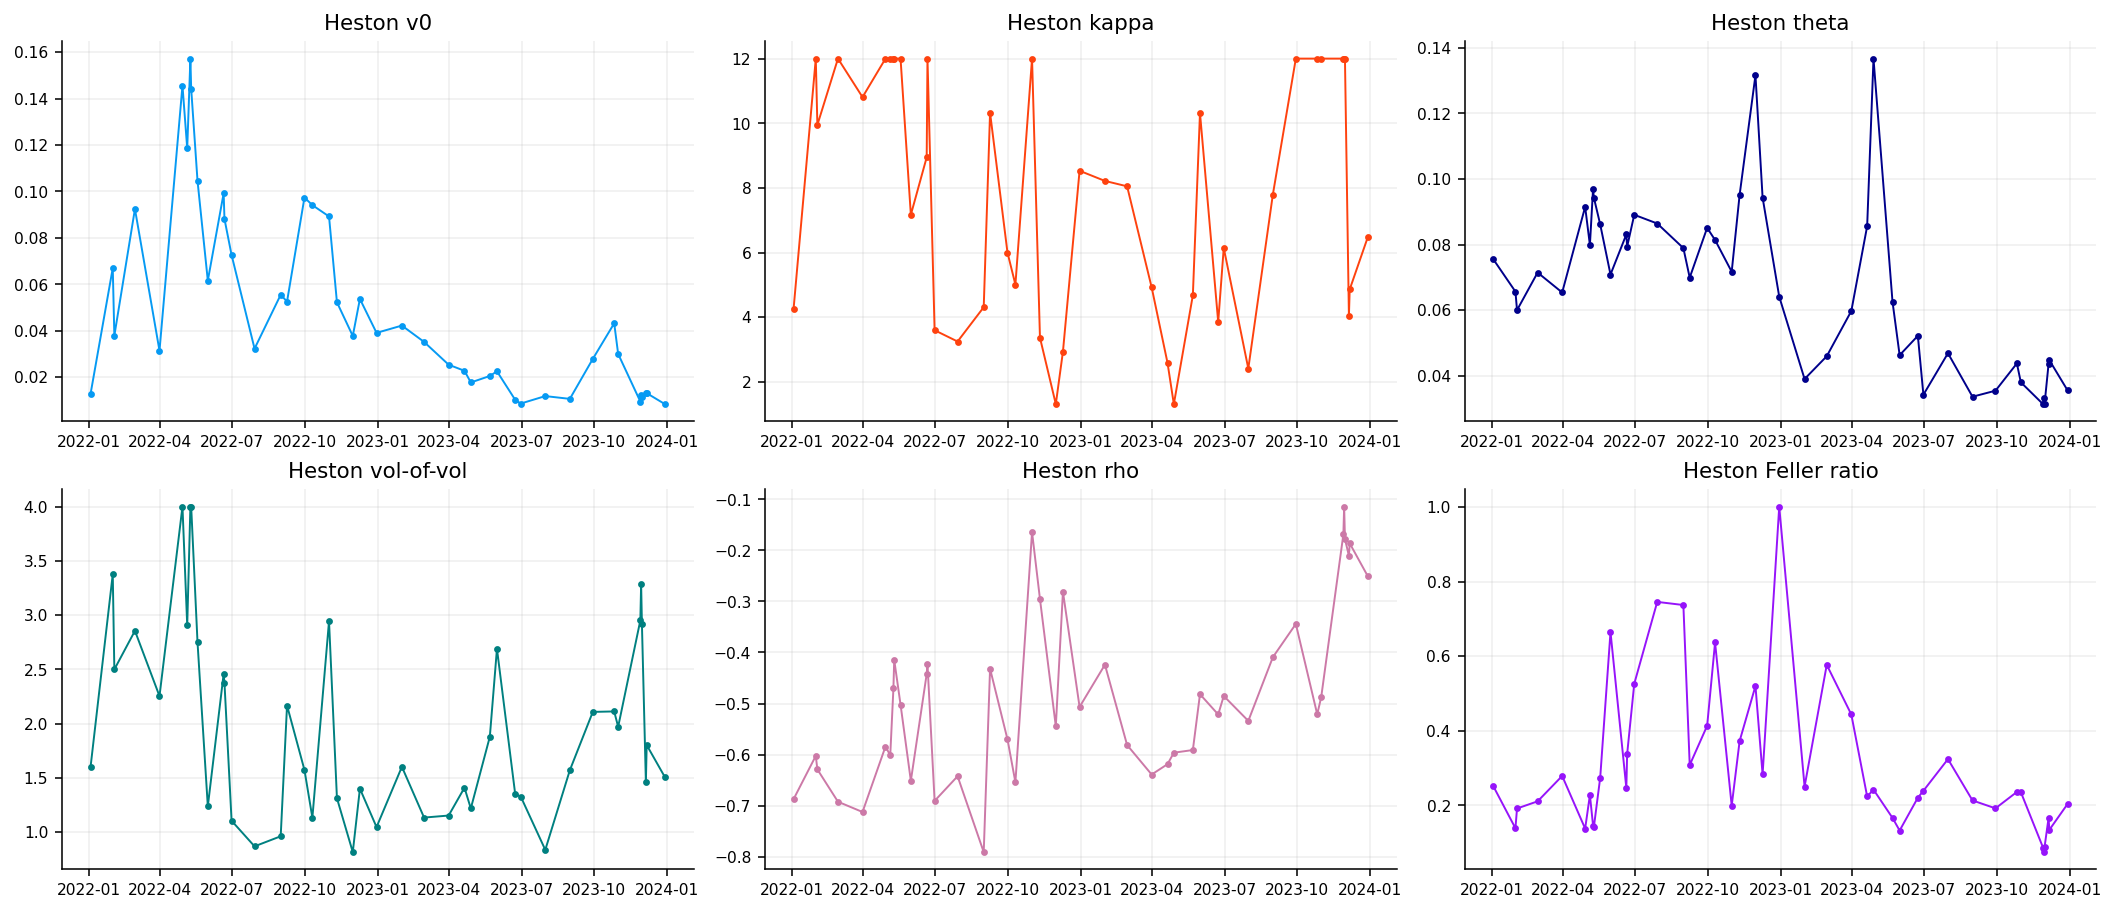

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.4), constrained_layout=True)
axes = axes.ravel()
heston_daily["feller_ratio"] = 2.0 * heston_daily["p1"] * heston_daily["p2"] / heston_daily["p3"].pow(2).replace(0.0, np.nan)
for i, (col, label) in enumerate([("p0", "v0"), ("p1", "kappa"), ("p2", "theta"), ("p3", "vol-of-vol"), ("p4", "rho"), ("feller_ratio", "Feller ratio")]):
    axes[i].plot(heston_daily["date"], heston_daily[col], marker="o", ms=2.5, lw=1.0, color=palette[i])
    axes[i].set_title(f"Heston {label}")
heston_main_date = heston_prices.groupby("date").size().sort_values(ascending=False).index[0]
heston_fit_main = heston_prices[heston_prices["date"].eq(heston_main_date)].copy()
heston_fit_main["k"] = np.log(heston_fit_main["strike"] / heston_fit_main["spot"])
plt.show()


In [25]:
def xi_from_surface(fit, tau_values):
    # Dense grid for PCHIP interpolation of total variance w(tau) = tau * sigma_ATM(tau)^2
    tau_arr = np.sort(np.asarray(tau_values, dtype=float))
    dense_tau = np.sort(np.unique(np.concatenate([tau_arr, np.linspace(max(tau_arr[0] * 0.5, 1e-4), tau_arr[-1] * 1.1, 60)])))
    dense_tau = dense_tau[dense_tau > 0]
    base = []
    for tau in dense_tau:
        sigma = float(surface_iv(fit, np.array([0.0]), np.array([tau]))[0])
        if np.isfinite(sigma) and sigma > 0:
            base.append({"tau": float(tau), "total_variance": sigma * sigma * float(tau)})
    try:
        from scipy.interpolate import PchipInterpolator
        if len(base) < 3:
            raise ValueError("too few points for PCHIP")
        tv_df = pd.DataFrame(base).sort_values("tau").reset_index(drop=True)
        pchip = PchipInterpolator(tv_df["tau"].values, tv_df["total_variance"].values)
        pchip_d = pchip.derivative()
        out_rows = []
        for tau in tau_arr:
            sigma = float(surface_iv(fit, np.array([0.0]), np.array([tau]))[0])
            fv = max(float(pchip_d(tau)), 1e-6)
            out_rows.append({"tau": float(tau), "total_variance": float(pchip(tau)), "atm_iv": sigma if np.isfinite(sigma) else np.nan, "variance": fv})
        return pd.DataFrame(out_rows)
    except Exception:
        out_rows = []
        last_tau, last_total = 0.0, 0.0
        for tau in tau_arr:
            sigma = float(surface_iv(fit, np.array([0.0]), np.array([tau]))[0])
            total = sigma * sigma * float(tau) if np.isfinite(sigma) and sigma > 0 else last_total
            out_rows.append({"tau": float(tau), "total_variance": total, "atm_iv": sigma if np.isfinite(sigma) else np.nan, "variance": max((total - last_total) / max(tau - last_tau, 1e-8), 1e-6)})
            last_tau, last_total = tau, total
        return pd.DataFrame(out_rows)


@njit
def rbergomi_xi_interp(t, xi_tau, xi_var):
    if t <= xi_tau[0]:
        return xi_var[0]
    for i in range(1, len(xi_tau)):
        if t <= xi_tau[i]:
            w = (t - xi_tau[i - 1]) / max(xi_tau[i] - xi_tau[i - 1], 1e-12)
            return xi_var[i - 1] * (1.0 - w) + xi_var[i] * w
    return xi_var[len(xi_var) - 1]


@njit
def rbergomi_paths_numba(spot, xi_tau, xi_var, h, nu, rho, rate, dividend_yield, tau, z1, z2):
    n, m = z1.shape
    dt = tau / m
    out_s = np.empty((n, m + 1))
    out_v = np.empty((n, m + 1))
    kernel = np.empty(m)
    rough_var = np.empty(m)
    alpha = h + 0.5
    scale = np.sqrt(max(2.0 * h, 1e-12)) * (dt ** h) / max(alpha, 1e-12)
    for j in range(m):
        kernel[j] = ((j + 1.0) ** alpha - j ** alpha)
    # Precompute actual discrete variance of the rough driver at each step.
    # Using t^(2H) is wrong for finite step counts; the true var is scale^2 * sum(kernel[l]^2).
    for j in range(m):
        rv = 0.0
        for l in range(j + 1):
            rv += kernel[l] * kernel[l]
        rough_var[j] = scale * scale * rv
    for i in range(n):
        out_s[i, 0] = spot
        out_v[i, 0] = rbergomi_xi_interp(0.0, xi_tau, xi_var)
        for j in range(m):
            rough = 0.0
            for l in range(j + 1):
                rough += kernel[l] * z1[i, j - l]
            rough *= scale
            xi_t = rbergomi_xi_interp((j + 1.0) * dt, xi_tau, xi_var)
            v = xi_t * np.exp(nu * rough - 0.5 * nu * nu * rough_var[j])
            if v < 1e-10:
                v = 1e-10
            if v > 25.0:
                v = 25.0
            out_v[i, j + 1] = v
            dw = rho * z1[i, j] + np.sqrt(max(1.0 - rho * rho, 1e-12)) * z2[i, j]
            out_s[i, j + 1] = out_s[i, j] * np.exp((rate - dividend_yield - 0.5 * v) * dt + np.sqrt(v * dt) * dw)
    return out_s, out_v


def _next_pow2(n):
    p = 1
    while p < n:
        p <<= 1
    return p


def _crn(paths, steps, seed, use_sobol=True):
    paths, steps, half = int(paths), int(steps), int(paths) // 2
    z1_h = z2_h = None
    if use_sobol:
        try:
            from scipy.stats.qmc import Sobol
            from scipy.stats import norm as _norm
            n_sobol = _next_pow2(half)
            sob1 = Sobol(d=steps, scramble=True, seed=int(seed))
            sob2 = Sobol(d=steps, scramble=True, seed=int(seed) + 1)
            u1 = sob1.random(n_sobol)[:half]
            u2 = sob2.random(n_sobol)[:half]
            u1 = np.clip(u1, 1e-12, 1.0 - 1e-12)
            u2 = np.clip(u2, 1e-12, 1.0 - 1e-12)
            z1_h = _norm.ppf(u1).astype(float)
            z2_h = _norm.ppf(u2).astype(float)
        except Exception:
            pass
    if z1_h is None:
        rng = np.random.default_rng(int(seed))
        z1_h = rng.standard_normal((half, steps))
        z2_h = rng.standard_normal((half, steps))
    return np.vstack([z1_h, -z1_h]), np.vstack([z2_h, -z2_h])


def rbergomi_sim(spot, xi, h, nu, rho, rate, dividend_yield, tau, paths, steps, seed, antithetic=True, z1=None, z2=None):
    if z1 is not None and z2 is not None:
        pass
    else:
        rng = np.random.default_rng(int(seed))
        half = int(paths) // 2 if antithetic else int(paths)
        z1 = rng.standard_normal((half, int(steps)))
        z2 = rng.standard_normal((half, int(steps)))
        if antithetic:
            z1 = np.vstack([z1, -z1])
            z2 = np.vstack([z2, -z2])
    xi_tau = np.asarray(xi["tau"], dtype=float)
    xi_var = np.asarray(xi["variance"], dtype=float)
    return rbergomi_paths_numba(float(spot), xi_tau, xi_var, float(h), float(nu), float(rho), float(rate), float(dividend_yield), float(tau), z1, z2)


def rbergomi_mc_smile(spot, xi, h, nu, rho, rate, dividend_yield, tau, strikes, paths, steps, seed, z1=None, z2=None):
    s, v = rbergomi_sim(spot, xi, h, nu, rho, rate, dividend_yield, tau, paths, steps, seed, antithetic=(z1 is None), z1=z1, z2=z2)
    terminal = s[:, -1]
    discount = np.exp(-float(rate) * float(tau))
    forward = float(spot) * np.exp((float(rate) - float(dividend_yield)) * float(tau))
    n_k = len(strikes)
    prices = np.empty(n_k)
    price_ses = np.empty(n_k)
    ivs = np.full(n_k, np.nan)
    for i, K in enumerate(strikes):
        # OTM pricing: puts for k<0, calls for k>=0 — avoids ITM IV inversion noise
        if K < forward:
            payoff = np.maximum(K - terminal, 0.0)
            px = discount * float(payoff.mean())
            se = discount * float(payoff.std(ddof=1) / np.sqrt(len(payoff)))
            iv_arr = implied_vol("put", np.array([px]), forward, np.array([K]), tau, discount, engine="auto")
        else:
            payoff = np.maximum(terminal - K, 0.0)
            px = discount * float(payoff.mean())
            se = discount * float(payoff.std(ddof=1) / np.sqrt(len(payoff)))
            iv_arr = implied_vol("call", np.array([px]), forward, np.array([K]), tau, discount, engine="auto")
        prices[i] = px
        price_ses[i] = se
        ivs[i] = float(iv_arr[0]) if len(iv_arr) > 0 and np.isfinite(iv_arr[0]) else np.nan
    k_arr = np.log(strikes / forward)  # forward moneyness, consistent with surface
    return pd.DataFrame({"tau": tau, "tau_days": tau * ann_days, "strike": strikes, "k": k_arr, "price": prices, "price_se": price_ses, "iv": ivs})


In [26]:
xi_curve = xi_from_surface(fit_visual, np.array([14, 21, 30, 45, 60, 90, 120, 150], dtype=float) / ann_days)
spot_main = float(q_main["spot"].median())
rate_rb = float(q_main["rate"].median())
div_rb = float(q_main["implied_dividend_yield"].median())
q_main_rbergomi_target = calibration_quotes[calibration_quotes["date"].eq(pd.Timestamp(main_date).normalize())].copy()
if q_main_rbergomi_target.empty:
    q_main_rbergomi_target = q_main.copy()
rb_h = float(np.clip(skew_fit_main["h_from_skew"].iloc[0], 0.04, 0.45))
rb_nu = 1.8
rb_rho = -0.70
k_smile = np.linspace(-0.28, 0.18, 31)

_fwd_ref = spot_main * np.exp((rate_rb - div_rb) * 30.0 / ann_days)
strikes_smile = _fwd_ref * np.exp(k_smile)

def rbergomi_iv_loss(params, z1_crn, z2_crn):
    h, nu, rho = params
    smiles = pd.concat([
        rbergomi_mc_smile(spot_main, xi_curve, h, nu, rho, rate_rb, div_rb, d / ann_days, strikes_smile,
                             len(z1_crn), z1_crn.shape[1], seed, z1=z1_crn, z2=z2_crn)
        for d in [14, 30, 60, 90]
    ], ignore_index=True)
    target = q_main_rbergomi_target[
        q_main_rbergomi_target["tau"].mul(ann_days).between(10, 100) &
        q_main_rbergomi_target["k"].between(k_smile.min(), k_smile.max())
    ].copy()
    errors, weights = [], []
    for _, row in target.iterrows():
        if not np.isfinite(row["iv_mid"]):
            continue
        valid_smiles = smiles[np.isfinite(smiles["iv"])].copy()
        if valid_smiles.empty:
            continue
        tau_choice = float(valid_smiles.iloc[(valid_smiles["tau_days"] - row["tau"] * ann_days).abs().argsort()[:1]]["tau_days"].iloc[0])
        slice_smile = valid_smiles[valid_smiles["tau_days"].eq(tau_choice)].sort_values("k")
        if len(slice_smile) >= 2 and row["k"] >= slice_smile["k"].min() and row["k"] <= slice_smile["k"].max():
            model_iv = float(np.interp(row["k"], slice_smile["k"], slice_smile["iv"]))
        else:
            score = (valid_smiles["tau_days"] - row["tau"] * ann_days).abs() + 25.0 * (valid_smiles["k"] - row["k"]).abs()
            model_iv = float(valid_smiles.loc[int(score.idxmin()), "iv"])
        err = float(model_iv - row["iv_mid"])
        if np.isfinite(err):
            w = float(row.get("obs_weight", row.get("surface_weight", 1.0)))
            errors.append(err)
            weights.append(w)
    errors = np.asarray(errors, dtype=float)
    weights = np.asarray(weights, dtype=float)
    loss = float(np.average(errors * errors, weights=np.clip(weights, 0.05, 20.0))) if errors.size else np.inf
    return loss, smiles


_crn_paths_search = 2048
_crn_steps = 80
z1_crn_search, z2_crn_search = _crn(_crn_paths_search, _crn_steps, seed, use_sobol=True)

candidate_params = [
    (rb_h, rb_nu, rb_rho),
    (max(0.05, rb_h - 0.06), rb_nu, rb_rho),
    (min(0.45, rb_h + 0.06), rb_nu, rb_rho),
    (0.08, rb_nu, rb_rho),
    (0.16, rb_nu, rb_rho),
    (0.28, rb_nu, rb_rho),
    (rb_h, 1.2, rb_rho),
    (rb_h, 2.6, rb_rho),
    (rb_h, 3.6, rb_rho),
    (rb_h, rb_nu, -0.90),
    (rb_h, rb_nu, -0.45),
    (rb_h, rb_nu, -0.20),
    (float(np.clip(skew_fit_main["h_from_skew"].iloc[0], 0.04, 0.45)), 2.2, -0.80),
    (max(0.05, rb_h - 0.05), 2.6, -0.90),
    (min(0.45, rb_h + 0.08), 1.2, -0.45),
]
loss_rows = []
candidate_results = []
for i, params in enumerate(candidate_params):
    loss, smile = rbergomi_iv_loss(params, z1_crn_search, z2_crn_search)
    loss_rows.append({"restart": i, "h": params[0], "nu": params[1], "rho": params[2], "iv_mse": loss, "iv_rmse": np.sqrt(loss)})
    candidate_results.append((loss, params, smile))

z1_crn_fine, z2_crn_fine = _crn(8192, _crn_steps, seed + 99, use_sobol=True)
best_loss = np.inf
best_smile = pd.DataFrame()
best_params = (rb_h, rb_nu, rb_rho)
for _, params, _ in sorted(candidate_results, key=lambda x: x[0])[:3]:
    loss_fine, smile_fine = rbergomi_iv_loss(params, z1_crn_fine, z2_crn_fine)
    if loss_fine < best_loss:
        best_loss = loss_fine
        best_smile = smile_fine
        best_params = params

def _rb_loss_scalar(x):
    h_ = float(np.clip(x[0], 0.04, 0.40))
    nu_ = float(np.clip(x[1], 0.3, 5.0))
    rho_ = float(np.clip(x[2], -0.99, -0.05))
    return rbergomi_iv_loss((h_, nu_, rho_), z1_crn_fine, z2_crn_fine)[0]

for _, p0_, _ in sorted(candidate_results, key=lambda x: x[0])[:3]:
    p0c = [float(np.clip(p0_[0], 0.04, 0.40)), float(np.clip(p0_[1], 0.3, 5.0)), float(np.clip(p0_[2], -0.99, -0.05))]
    try:
        opt = optimize.minimize(_rb_loss_scalar, p0c, method="Nelder-Mead",
                                options={"maxiter": 200, "xatol": 1e-4, "fatol": 1e-5, "adaptive": True})
        if opt.fun < best_loss:
            best_loss = opt.fun
            best_params = (float(np.clip(opt.x[0], 0.04, 0.40)), float(np.clip(opt.x[1], 0.3, 5.0)), float(np.clip(opt.x[2], -0.99, -0.05)))
            best_smile = rbergomi_iv_loss(best_params, z1_crn_fine, z2_crn_fine)[1]
    except Exception:
        pass

rbergomi_loss_table = pd.DataFrame(loss_rows).sort_values("iv_mse")
rb_h, rb_nu, rb_rho = best_params

rbergomi_s, rbergomi_v = rbergomi_sim(spot_main, xi_curve, rb_h, rb_nu, rb_rho, rate_rb, div_rb, 90 / ann_days, 3000, 96, seed, antithetic=True)
rbergomi_iv = pd.concat([
    rbergomi_mc_smile(spot_main, xi_curve, rb_h, rb_nu, rb_rho, rate_rb, div_rb, d / ann_days, strikes_smile, 4000, 96, seed + int(d))
    for d in [14, 30, 60, 90]
], ignore_index=True)

sens_rows = []
for name, values in [("h", [0.06, rb_h, 0.30]), ("nu", [0.9, rb_nu, 3.0]), ("rho", [-0.90, rb_rho, -0.25])]:
    for value in values:
        h1 = value if name == "h" else rb_h
        nu1 = value if name == "nu" else rb_nu
        rho1 = value if name == "rho" else rb_rho
        s1 = rbergomi_mc_smile(spot_main, xi_curve, h1, nu1, rho1, rate_rb, div_rb, 30 / ann_days, strikes_smile, 2500, 80, seed + int(abs(value) * 1000))
        s1["parameter"] = name
        s1["value"] = value
        sens_rows.append(s1)
rbergomi_sensitivity = pd.concat(sens_rows, ignore_index=True)

conv_rows = []
for p in [800, 1600, 3200, 6400]:
    s1 = rbergomi_mc_smile(spot_main, xi_curve, rb_h, rb_nu, rb_rho, rate_rb, div_rb, 30 / ann_days, np.array([spot_main]), p, 80, seed + p)
    conv_rows.append({"paths": p, "atm_call_price": float(s1["price"].iloc[0]), "price_se": float(s1["price_se"].iloc[0]), "atm_iv": float(s1["iv"].iloc[0])})
rbergomi_convergence = pd.DataFrame(conv_rows)

display(xi_curve.round(5))
display(rbergomi_loss_table.round(6))
display(rbergomi_convergence.round(6))


,tau,total_variance,atm_iv,variance
0,0.03833,0.00044,0.10757,0.01338
1,0.05749,0.00074,0.11365,0.01768
2,0.08214,0.00122,0.12196,0.02091
3,0.12320,0.00215,0.13212,0.02466
4,0.16427,0.00324,0.14050,0.02828
5,0.24641,0.00585,0.15403,0.03512
6,0.32854,0.00887,0.16431,0.03735
7,0.41068,0.01200,0.17091,0.03972


,restart,h,nu,rho,iv_mse,iv_rmse
14,14,0.444219,1.2,-0.45,0.000214,0.014614
11,11,0.364219,1.8,-0.20,0.000264,0.016236
10,10,0.364219,1.8,-0.45,0.001328,0.036443
6,6,0.364219,1.2,-0.70,0.001394,0.037341
2,2,0.424219,1.8,-0.70,0.001426,0.037757
0,0,0.364219,1.8,-0.70,0.003366,0.058015
9,9,0.364219,1.8,-0.90,0.005626,0.075010
12,12,0.364219,2.2,-0.80,0.006642,0.081497
7,7,0.364219,2.6,-0.70,0.006816,0.082559
1,1,0.304219,1.8,-0.70,0.007853,0.088618


,paths,atm_call_price,price_se,atm_iv
0,800,55.836772,3.243942,0.105047
1,1600,56.291046,2.390488,0.105876
2,3200,56.713916,1.638684,0.106648
3,6400,54.929668,1.167085,0.103391


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\641628204.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6)


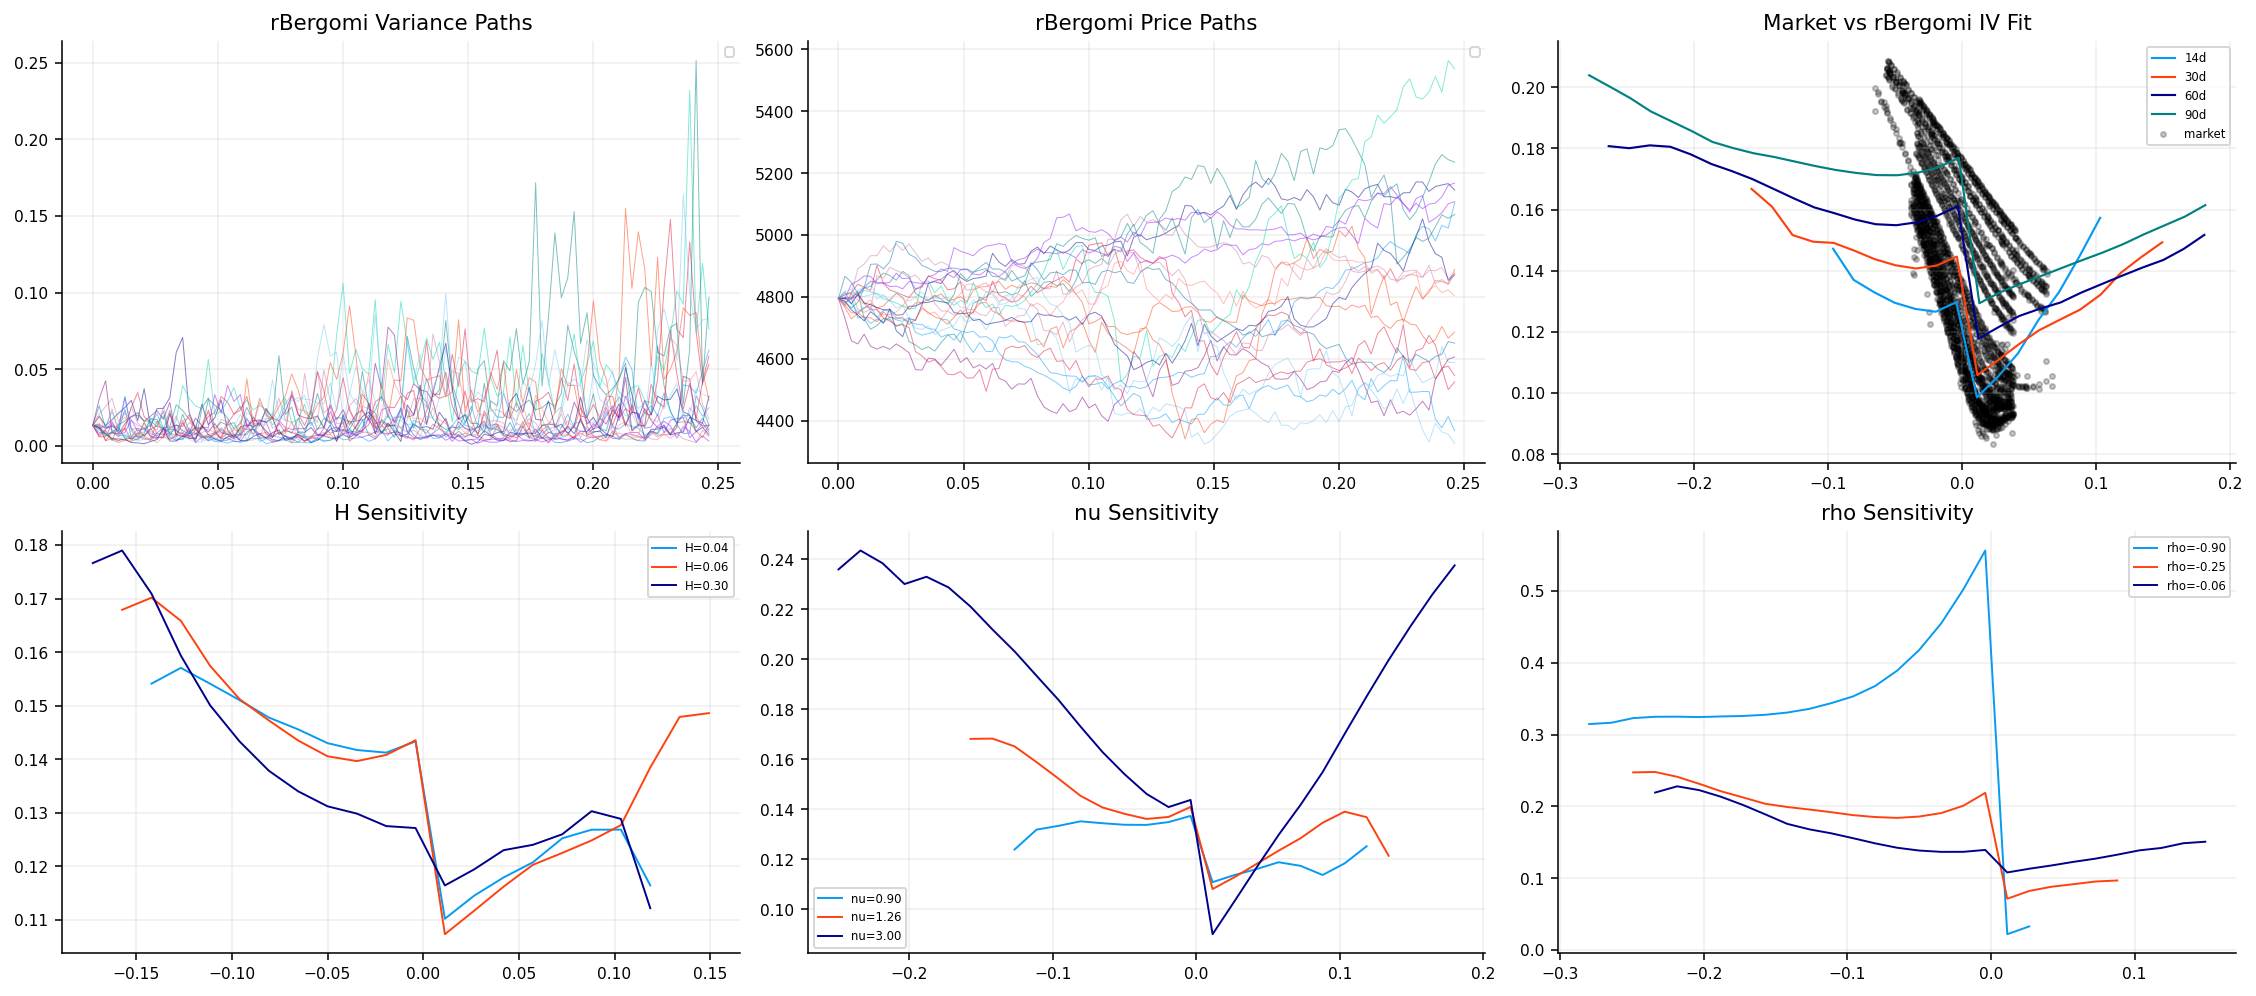

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
time_grid = np.linspace(0.0, 90 / ann_days, rbergomi_v.shape[1])
for i in range(20):
    axes[0, 0].plot(time_grid, rbergomi_v[i], lw=0.5, alpha=0.5)
    axes[0, 1].plot(time_grid, rbergomi_s[i], lw=0.5, alpha=0.5)
for i, (d, g) in enumerate(rbergomi_iv.groupby("tau_days")):
    axes[0, 2].plot(g["k"], g["iv"], lw=1.1, color=palette[i], label=f"{d:.0f}d")
axes[0, 2].scatter(q_main["k"], q_main["iv_mid"], s=7, alpha=0.22, color="black", label="market")
for i, (value, g) in enumerate(rbergomi_sensitivity[rbergomi_sensitivity["parameter"].eq("h")].groupby("value")):
    axes[1, 0].plot(g["k"], g["iv"], lw=1.0, color=palette[i], label=f"H={value:.2f}")
for i, (value, g) in enumerate(rbergomi_sensitivity[rbergomi_sensitivity["parameter"].eq("nu")].groupby("value")):
    axes[1, 1].plot(g["k"], g["iv"], lw=1.0, color=palette[i], label=f"nu={value:.2f}")
for i, (value, g) in enumerate(rbergomi_sensitivity[rbergomi_sensitivity["parameter"].eq("rho")].groupby("value")):
    axes[1, 2].plot(g["k"], g["iv"], lw=1.0, color=palette[i], label=f"rho={value:.2f}")
axes[0, 0].set_title("rBergomi Variance Paths")
axes[0, 1].set_title("rBergomi Price Paths")
axes[0, 2].set_title("Market vs rBergomi IV Fit")
axes[1, 0].set_title("H Sensitivity")
axes[1, 1].set_title("nu Sensitivity")
axes[1, 2].set_title("rho Sensitivity")
for ax in axes.ravel():
    ax.legend(fontsize=6)
plt.show()


In [28]:
def rough_heston_params_array(params):
    if isinstance(params, pd.Series):
        h = float(params.get("h", h_rv))
        return np.array([h, params["p0"], params["p1"], params["p2"], params["p3"], params["p4"]], dtype=float)
    return np.asarray(params, dtype=float)


def riccati_rhs(u, psi, kappa, sigma_v, rho):
    return -0.5 * (u * u + 1j * u) + (1j * u * rho * sigma_v - kappa) * psi + 0.5 * sigma_v * sigma_v * psi * psi


@njit
def fractional_riccati_adams_numba(u, alpha, kappa, sigma_v, rho, tau, n_steps, gamma_alpha_1, gamma_alpha_2, gamma_beta_1):
    m = max(1, int(n_steps))
    n_u = u.size
    dt = tau / m
    dt_alpha = dt ** alpha
    psi = np.zeros((m + 1, n_u), dtype=np.complex128)
    f = np.zeros((m + 1, n_u), dtype=np.complex128)
    predictor_weights = np.empty(m, dtype=np.float64)
    for j in range(1, m + 1):
        predictor_weights[j - 1] = (j ** alpha - (j - 1.0) ** alpha) * dt_alpha / gamma_alpha_1
    for col in range(n_u):
        uu = u[col]
        f[0, col] = -0.5 * (uu * uu + 1j * uu)
    for i in range(1, m + 1):
        n = i - 1
        a0 = n ** (alpha + 1.0) - (n - alpha) * (n + 1.0) ** alpha
        for col in range(n_u):
            uu = u[col]
            pred = 0.0 + 0.0j
            for j in range(i):
                pred += predictor_weights[i - 1 - j] * f[j, col]
            f_pred = -0.5 * (uu * uu + 1j * uu) + (1j * uu * rho * sigma_v - kappa) * pred + 0.5 * sigma_v * sigma_v * pred * pred
            corr = a0 * f[0, col]
            for j in range(1, i):
                jj = float(j)
                weight = (n - jj + 2.0) ** (alpha + 1.0) + (n - jj) ** (alpha + 1.0) - 2.0 * (n - jj + 1.0) ** (alpha + 1.0)
                corr += weight * f[j, col]
            psi[i, col] = dt_alpha * (corr + f_pred) / gamma_alpha_2
            val = psi[i, col]
            f[i, col] = -0.5 * (uu * uu + 1j * uu) + (1j * uu * rho * sigma_v - kappa) * val + 0.5 * sigma_v * sigma_v * val * val
    integral = np.empty(n_u, dtype=np.complex128)
    for col in range(n_u):
        total = 0.5 * (psi[0, col] + psi[m, col])
        for j in range(1, m):
            total += psi[j, col]
        integral[col] = dt * total
    beta = 1.0 - alpha
    fractional_terminal = np.empty(n_u, dtype=np.complex128)
    if beta <= 1e-10:
        for col in range(n_u):
            fractional_terminal[col] = psi[m, col]
    else:
        dt_beta = dt ** beta
        for col in range(n_u):
            total = 0.0 + 0.0j
            for j in range(1, m + 1):
                weight = ((m - j + 1.0) ** beta - (m - j) ** beta) * dt_beta / gamma_beta_1
                total += weight * psi[j, col]
            fractional_terminal[col] = total
    return psi, integral, fractional_terminal


def riccati_terms(u, params, tau, n_steps):
    h, v0, kappa, theta, sigma_v, rho = rough_heston_params_array(params)
    alpha = np.clip(h, 1e-6, 0.5) + 0.5
    m = max(1, int(n_steps))
    tau = max(float(tau), 1e-12)
    dt = tau / m
    t = np.linspace(0.0, tau, m + 1)
    u = np.asarray(u, dtype=np.complex128).reshape(-1)
    gamma_alpha_1 = math.gamma(alpha + 1.0)
    gamma_alpha_2 = math.gamma(alpha + 2.0)
    gamma_beta_1 = math.gamma(max(1.0 - alpha, 0.0) + 1.0)
    try:
        psi, integral, fractional_terminal = fractional_riccati_adams_numba(
            u,
            float(alpha),
            float(kappa),
            float(sigma_v),
            float(rho),
            float(tau),
            int(m),
            float(gamma_alpha_1),
            float(gamma_alpha_2),
            float(gamma_beta_1),
        )
        return t, psi, integral, fractional_terminal, alpha
    except Exception:
        pass
    psi = np.zeros((m + 1, len(u)), dtype=complex)
    f = np.zeros_like(psi)
    f[0] = riccati_rhs(u, psi[0], kappa, sigma_v, rho)
    j = np.arange(1, m + 1, dtype=float)
    predictor_weights = (j ** alpha - (j - 1.0) ** alpha) * dt ** alpha / gamma_alpha_1
    for i in range(1, m + 1):
        pred = predictor_weights[:i][::-1] @ f[:i]
        f_pred = riccati_rhs(u, pred, kappa, sigma_v, rho)
        n = i - 1
        a = np.empty(i, dtype=float)
        a[0] = n ** (alpha + 1.0) - (n - alpha) * (n + 1.0) ** alpha
        if i > 1:
            jj = np.arange(1, i, dtype=float)
            a[1:] = (n - jj + 2.0) ** (alpha + 1.0) + (n - jj) ** (alpha + 1.0) - 2.0 * (n - jj + 1.0) ** (alpha + 1.0)
        psi[i] = dt ** alpha * (a @ f[:i] + f_pred) / gamma_alpha_2
        f[i] = riccati_rhs(u, psi[i], kappa, sigma_v, rho)
    integral = np.trapezoid(psi, t, axis=0)
    beta = max(1.0 - alpha, 0.0)
    if beta <= 1e-10:
        fractional_terminal = psi[-1]
    else:
        j = np.arange(1, m + 1, dtype=float)
        frac_weights = ((m - j + 1.0) ** beta - (m - j) ** beta) * dt ** beta / gamma_beta_1
        fractional_terminal = frac_weights @ psi[1:]
    return t, psi, integral, fractional_terminal, alpha


def fractional_riccati(u, params, tau, n_steps):
    t, psi, integral, fractional_terminal, alpha = riccati_terms(np.asarray([u]), params, tau, n_steps)
    path = psi[:, 0]
    return pd.DataFrame({"t": t, "real": np.real(path), "imag": np.imag(path), "abs": np.abs(path), "alpha": alpha})


def rough_heston_cf(u, params, spot, rate, dividend_yield, tau, riccati_steps=128):
    h, v0, kappa, theta, sigma_v, rho = rough_heston_params_array(params)
    u_arr = np.asarray(u, dtype=complex)
    shape = u_arr.shape
    tau = float(tau)
    t, psi, integral, fractional_terminal, alpha = riccati_terms(u_arr.reshape(-1), params, tau, riccati_steps)
    exponent = 1j * u_arr.reshape(-1) * (np.log(float(spot)) + (float(rate) - float(dividend_yield)) * tau) + kappa * theta * integral + v0 * fractional_terminal
    real = np.real(exponent)
    imag = np.imag(exponent)
    finite = np.isfinite(real) & np.isfinite(imag)
    real = np.clip(np.where(finite, real, -700.0), -700.0, 0.0)
    imag = np.where(finite, imag, 0.0)
    return np.exp(real + 1j * imag).reshape(shape)


def rough_heston_cf_diag(params, spot, rate, dividend_yield, tau, riccati_steps=512):
    u = np.r_[0.0, 0.5, 1.0, 2.0, 5.0, 10.0, -1j].astype(complex)
    h, v0, kappa, theta, sigma_v, rho = rough_heston_params_array(params)
    t, psi, integral, fractional_terminal, alpha = riccati_terms(u, params, tau, riccati_steps)
    exponent = 1j * u * (np.log(float(spot)) + (float(rate) - float(dividend_yield)) * tau) + kappa * theta * integral + v0 * fractional_terminal
    real = np.real(exponent)
    imag = np.imag(exponent)
    finite = np.isfinite(real) & np.isfinite(imag)
    clip_mask = finite & ((real > 700.0) | (real < -700.0))
    safe_phi = np.exp(np.clip(np.where(finite, real, -700.0), -700.0, 700.0) + 1j * np.where(finite, imag, 0.0))
    return pd.DataFrame([{
        "tau": float(tau),
        "riccati_steps": int(riccati_steps),
        "cf_clip_count": int(np.count_nonzero(clip_mask)),
        "cf_nonfinite_count": int(np.count_nonzero(~finite)),
        "max_real_exponent": float(np.nanmax(real)),
        "min_real_exponent": float(np.nanmin(real)),
        "phi_zero_error": float(abs(safe_phi[0] - 1.0)),
        "martingale_error": float(abs(safe_phi[-1] - float(spot) * np.exp((float(rate) - float(dividend_yield)) * tau)) / max(float(spot) * np.exp((float(rate) - float(dividend_yield)) * tau), 1e-12)),
    }])


def rough_heston_px(params, strike, tau, spot, rate, dividend_yield, option_type, n_terms=96, truncation_width=16.0, riccati_steps=512):
    h, v0, kappa, theta, sigma_v, rho = rough_heston_params_array(params)
    def cf(u, tau_i, spot_i, rate_i, dividend_i):
        return rough_heston_cf(u, params, spot_i, rate_i, dividend_i, tau_i, riccati_steps=riccati_steps)
    return cos_prices(
        "custom",
        None,
        strike,
        tau,
        spot,
        rate,
        dividend_yield,
        option_type=option_type,
        n_terms=int(n_terms),
        truncation_width=float(truncation_width),
        engine="cpp",
        cf=cf,
        variance_hint=max(v0, theta, 1e-6),
    )


In [29]:
rough_test_row = calibration_quotes.iloc[0]
rough_test_heston = heston_daily[heston_daily["date"].eq(rough_test_row["date"])]
if rough_test_heston.empty:
    rough_test_heston = heston_daily.dropna().iloc[[0]]
rough_test_params = np.array([np.clip(h_rv, 0.04, 0.35), rough_test_heston["p0"].iloc[0], rough_test_heston["p1"].iloc[0], rough_test_heston["p2"].iloc[0], rough_test_heston["p3"].iloc[0], rough_test_heston["p4"].iloc[0]], dtype=float)

riccati_rows = []
for u_value in [0.5 + 0.0j, 1.0 - 0.5j, 2.5 + 0.0j, 5.0 - 1.0j]:
    last_abs = np.nan
    for n in [128, 256, 512, 1024]:
        ric = fractional_riccati(u_value, rough_test_params, 90 / ann_days, n)
        terminal_abs = float(ric["abs"].iloc[-1])
        riccati_rows.append({"u": str(u_value), "riccati_steps": n, "terminal_real": float(ric["real"].iloc[-1]), "terminal_imag": float(ric["imag"].iloc[-1]), "terminal_abs": terminal_abs, "abs_change": abs(terminal_abs - last_abs) if np.isfinite(last_abs) else np.nan})
        last_abs = terminal_abs
riccati_grid_test = pd.DataFrame(riccati_rows)

price_rows = []
spot_test = float(rough_test_row["spot"])
rate_test = float(rough_test_row["rate"])
div_test = float(rough_test_row.get("implied_dividend_yield", 0.0))
for tau_day in [7, 30, 90]:
    tau = tau_day / ann_days
    for strike_type, k_value, option_type in [("OTM put", -0.15, "put"), ("ATM", 0.0, "call"), ("OTM call", 0.15, "call")]:
        strike = np.array([spot_test * np.exp(k_value)])
        prices_by_n = {}
        for n in [128, 256, 512, 1024]:
            prices_by_n[n] = float(rough_heston_px(rough_test_params, strike, np.array([tau]), spot_test, rate_test, div_test, option_type, n_terms=128, riccati_steps=n)[0])
        order_estimate = np.log2(abs(prices_by_n[256] - prices_by_n[512]) / abs(prices_by_n[512] - prices_by_n[1024])) if abs(prices_by_n[512] - prices_by_n[1024]) > 1e-12 else np.nan
        price_rows.append({"strike_type": strike_type, "tau_days": tau_day, "k": k_value, "option_type": option_type, "price_128": prices_by_n[128], "price_256": prices_by_n[256], "price_512": prices_by_n[512], "price_1024": prices_by_n[1024], "richardson_512": 2.0 * prices_by_n[512] - prices_by_n[256], "abs_512_1024": abs(prices_by_n[512] - prices_by_n[1024]), "order_estimate": order_estimate})
price_grid_test = pd.DataFrame(price_rows)

heston_sanity_params = rough_test_params.copy()
heston_sanity_params[0] = 0.5
heston_limit_rows = []
for tau_day in [7, 30, 90]:
    tau = tau_day / ann_days
    sanity_k = np.linspace(-0.30, 0.30, 9)
    sanity_strikes = spot_test * np.exp(sanity_k)
    sanity_tau = np.full_like(sanity_strikes, tau)
    rough_sanity_prices = rough_heston_px(heston_sanity_params, sanity_strikes, sanity_tau, spot_test, rate_test, div_test, "call", n_terms=160, riccati_steps=1024)
    heston_sanity_prices = cos_prices("heston", heston_sanity_params[1:], sanity_strikes, sanity_tau, spot_test, rate_test, div_test, option_type="call", engine="cpp", n_terms=192, truncation_width=16.0)
    for kk, strike, pr, ph in zip(sanity_k, sanity_strikes, rough_sanity_prices, heston_sanity_prices):
        heston_limit_rows.append({"tau_days": tau_day, "k": kk, "strike": strike, "rough_h_0_5_price": pr, "heston_price": ph, "abs_diff": abs(pr - ph)})
heston_limit_test = pd.DataFrame(heston_limit_rows)

cf_diagnostics = pd.concat([
    rough_heston_cf_diag(rough_test_params, spot_test, rate_test, div_test, tau_day / ann_days, riccati_steps=1024)
    for tau_day in [7, 30, 90]
], ignore_index=True)

display(riccati_grid_test.round(8))
display(price_grid_test.round(8))
display(heston_limit_test.groupby("tau_days").agg(max_abs_diff=("abs_diff", "max"), median_abs_diff=("abs_diff", "median")).round(8))
display(cf_diagnostics.round(8))


,u,riccati_steps,terminal_real,terminal_imag,terminal_abs,abs_change
0,(0.5+0j),128,-0.025575,-0.040876,0.048218,NaN
1,(0.5+0j),256,-0.025576,-0.040877,0.048219,1.640000e-06
2,(0.5+0j),512,-0.025576,-0.040878,0.048220,5.200000e-07
3,(0.5+0j),1024,-0.025576,-0.040878,0.048220,1.600000e-07
4,(1-0.5j),128,-0.095918,0.015275,0.097127,NaN
5,(1-0.5j),256,-0.095922,0.015275,0.097131,3.880000e-06
6,(1-0.5j),512,-0.095923,0.015275,0.097132,1.220000e-06
7,(1-0.5j),1024,-0.095924,0.015275,0.097132,3.900000e-07
8,(2.5+0j),128,-0.497124,0.006300,0.497164,NaN
9,(2.5+0j),256,-0.497151,0.006296,0.497190,2.648000e-05


,strike_type,tau_days,k,option_type,price_128,price_256,price_512,price_1024,richardson_512,abs_512_1024,order_estimate
0,OTM put,7,-0.15,put,1.089565,1.067325,1.066788,1.066476,1.066251,0.000312,0.784566
1,ATM,7,0.00,call,23.496406,23.358640,23.359538,23.359063,23.360437,0.000475,0.919472
2,OTM call,7,0.15,call,0.000000,0.011191,0.011138,0.011128,0.011085,0.000010,2.483701
3,OTM put,30,-0.15,put,11.077887,10.757598,10.755387,10.754459,10.753177,0.000928,1.252374
4,ATM,30,0.00,call,65.116460,64.902948,64.907669,64.908857,64.912390,0.001188,1.990207
5,OTM call,30,0.15,call,0.122947,0.200948,0.201054,0.200955,0.201160,0.000099,0.104372
6,OTM put,90,-0.15,put,42.858203,43.359352,43.530662,43.529066,43.701972,0.001596,6.745955
7,ATM,90,0.00,call,139.678234,140.557915,140.753864,140.757659,140.949813,0.003795,5.690342
8,OTM call,90,0.15,call,2.285561,2.735065,2.900334,2.899065,3.065604,0.001269,7.024830


,max_abs_diff,median_abs_diff
tau_days,,
7,0.016083,0.000527
30,0.032522,0.009349
90,0.014660,0.003519


,tau,riccati_steps,cf_clip_count,cf_nonfinite_count,max_real_exponent,min_real_exponent,phi_zero_error,martingale_error
0,0.019165,1024,0,0,8.475182,-0.019529,0.0,0.0
1,0.082136,1024,0,0,8.474307,-0.089261,0.0,0.0
2,0.246407,1024,0,0,8.472027,-0.271777,0.0,0.0


In [30]:
def fit_rough_heston_one_date(q, start, h_fixed, max_nfev=18, n_terms=72, riccati_steps=256, surface_fit=None, lambda_skew=0.0):
    t0 = time.perf_counter()
    day = calibration_weights(q).reset_index(drop=True)
    target = day["mid"].to_numpy(float)
    scale = day["calib_scale_px"].to_numpy(float) / np.sqrt(day["obs_weight"].to_numpy(float))
    groups = []
    for _, idx in day.groupby(["date", "expiry", "option_type"], sort=False).groups.items():
        pos = np.asarray(idx, dtype=int)
        g = day.iloc[pos]
        groups.append((pos, g["strike"].to_numpy(float), g["tau"].to_numpy(float), float(g["spot"].median()), float(g["rate"].median()), float(g.get("implied_dividend_yield", pd.Series(0.0, index=g.index)).median()), str(g["option_type"].iloc[0])))
    lo = np.array([0.035, 1e-5, 0.05, 1e-5, 0.02, -0.999])
    hi = np.array([0.45, 4.0, 12.0, 4.0, 4.0, 0.999])
    p0 = np.clip(np.asarray(start, dtype=float), lo, hi)
    h_fixed = float(np.clip(h_fixed, lo[0], hi[0]))
    riccati_inner = max(32, riccati_steps // 3)
    _spot_d = float(day["spot"].iloc[0])
    _rate_d = float(pd.to_numeric(day.get("rate", pd.Series(0.0, index=day.index)), errors="coerce").median())
    _div_d = float(pd.to_numeric(day.get("implied_dividend_yield", pd.Series(0.0, index=day.index)), errors="coerce").median())
    _tau_vals = sorted(set(day["tau"].round(5)))
    market_skew = {}
    if surface_fit is not None and float(lambda_skew) > 0.0:
        _dk = 0.01
        for _tau_s in [7, 14, 21, 30, 45, 60]:
            _t = _tau_s / ann_days
            if _t < min(_tau_vals) - 5 / ann_days or _t > max(_tau_vals) + 5 / ann_days:
                continue
            _ilo = float(surface_iv(surface_fit, np.array([-_dk]), np.array([_t]))[0])
            _ihi = float(surface_iv(surface_fit, np.array([_dk]), np.array([_t]))[0])
            if np.isfinite(_ilo) and np.isfinite(_ihi):
                market_skew[_t] = (_ihi - _ilo) / (2 * _dk)
    _skew_scale = max(float(np.mean(np.abs(list(market_skew.values())))) if market_skew else 1.0, 0.05)
    def residual(p, rc_steps):
        px = np.empty(len(day), dtype=float)
        for pos, strike, tau, spot, rate, div, option_type in groups:
            try:
                px[pos] = rough_heston_px(p, strike, tau, spot, rate, div, option_type, n_terms=n_terms, riccati_steps=rc_steps)
            except FloatingPointError:
                px[pos] = np.nan
        if not np.all(np.isfinite(px)):
            return np.full_like(target, 1e6)
        return (px - target) / scale
    def skew_residuals(p):
        sk = []
        if not market_skew:
            return np.array([], dtype=float)
        _dk = 0.01
        for _t, _psi_mkt in market_skew.items():
            try:
                _fwd = _spot_d * np.exp((_rate_d - _div_d) * _t)
                _disc = np.exp(-_rate_d * _t)
                _Klo = np.array([_fwd * np.exp(-_dk)])
                _Khi = np.array([_fwd * np.exp(_dk)])
                _pxlo = rough_heston_px(p, _Klo, np.array([_t]), _spot_d, _rate_d, _div_d, "put", n_terms=n_terms, riccati_steps=riccati_inner)
                _pxhi = rough_heston_px(p, _Khi, np.array([_t]), _spot_d, _rate_d, _div_d, "call", n_terms=n_terms, riccati_steps=riccati_inner)
                _ivlo = float(implied_vol("put", _pxlo, _fwd, _Klo, _t, _disc)[0])
                _ivhi = float(implied_vol("call", _pxhi, _fwd, _Khi, _t, _disc)[0])
                if np.isfinite(_ivlo) and np.isfinite(_ivhi):
                    sk.append(float(np.sqrt(float(lambda_skew))) * ((_ivhi - _ivlo) / (2 * _dk) - _psi_mkt) / _skew_scale)
            except Exception:
                pass
        return np.asarray(sk, dtype=float)
    def residual_fixed(x):
        p = np.r_[h_fixed, x]
        res = residual(p, riccati_inner)
        sk = skew_residuals(p) if market_skew else np.array([], dtype=float)
        return np.concatenate([res, sk]) if sk.size else res
    fixed = optimize.least_squares(residual_fixed, p0[1:], bounds=(lo[1:], hi[1:]), max_nfev=int(max_nfev), xtol=1e-7, ftol=1e-7, gtol=1e-7)
    res_x = np.r_[h_fixed, fixed.x]
    res_fun = residual(res_x, riccati_steps)
    best_loss = float(np.nanmean(res_fun * res_fun))
    px = target + res_fun * scale
    fit = day.copy()
    fit["model"] = "rough_heston"
    fit["model_price"] = px
    fit["price_residual"] = px - target
    vega = pd.to_numeric(fit.get("vega", 1.0), errors="coerce").abs().replace(0.0, np.nan).to_numpy(float)
    inside = ((px >= pd.to_numeric(fit.get("bid", fit["mid"]), errors="coerce").to_numpy(float)) & (px <= pd.to_numeric(fit.get("ask", fit["mid"]), errors="coerce").to_numpy(float)))
    k_col = pd.to_numeric(fit.get("k", np.zeros(len(fit))), errors="coerce").to_numpy(float)
    dte_col = pd.to_numeric(fit.get("dte_days", fit.get("tau", 0.0) * ann_days), errors="coerce").to_numpy(float)
    otype_col = fit.get("option_type", pd.Series(["call"] * len(fit))).to_numpy()
    otm_put_mask = (otype_col == "put") & (k_col < -0.10)
    short_mat_mask = dte_col <= 30
    otm_put_rmse = float(np.sqrt(np.nanmean(((px[otm_put_mask] - target[otm_put_mask]) / np.maximum(scale[otm_put_mask], 1e-8)) ** 2))) if otm_put_mask.any() else np.nan
    short_maturity_rmse = float(np.sqrt(np.nanmean(((px[short_mat_mask] - target[short_mat_mask]) / np.maximum(scale[short_mat_mask], 1e-8)) ** 2))) if short_mat_mask.any() else np.nan
    row = {
        "model": "rough_heston",
        "date": pd.Timestamp(day["date"].iloc[0]).normalize(),
        "success": bool(fixed.success or np.sqrt(best_loss) < 5.0),
        "nfev": int(fixed.nfev),
        "runtime_sec": float(time.perf_counter() - t0),
        "quotes": int(len(day)),
        "weighted_price_rmse": float(np.sqrt(np.nanmean(((px - target) / scale) ** 2))),
        "median_abs_price_error": float(np.nanmedian(np.abs(px - target))),
        "weighted_iv_rmse": float(np.sqrt(np.nanmean(((px - target) / np.maximum(vega, 1e-6)) ** 2))),
        "bid_ask_hit_rate": float(np.nanmean(inside)),
        "otm_put_rmse": otm_put_rmse,
        "short_maturity_rmse": short_maturity_rmse,
        "stage_fixed_rmse": float(np.sqrt(np.nanmean(fixed.fun * fixed.fun))),
        "stage_free_rmse": float(np.sqrt(best_loss)),
        "h_mode": "fixed",
        "h_anchor": h_fixed,
        "h_fixed": h_fixed,
        "h": float(res_x[0]),
        "p0": float(res_x[1]),
        "p1": float(res_x[2]),
        "p2": float(res_x[3]),
        "p3": float(res_x[4]),
        "p4": float(res_x[5]),
    }
    return row, fit, res_x


In [31]:
rough_cache = cache_dir / "spx_rough_heston_surface_grid_fixed_h_daily.parquet"
rough_fit_cache = cache_dir / "spx_rough_heston_surface_grid_fixed_h_fit.parquet"
expected_rough_dates = pd.DatetimeIndex([
    d for d in rough_fit_dates
    if len(calibration_quotes[calibration_quotes["date"].eq(d)]) >= 45
]).sort_values()

if rough_cache.exists() and rough_fit_cache.exists():
    rough_daily = pd.read_parquet(rough_cache)
    rough_prices = pd.read_parquet(rough_fit_cache)
    if "runtime_sec" not in rough_daily.columns:
        rough_daily["runtime_sec"] = 0.0
else:
    rough_daily = pd.DataFrame()
    rough_prices = pd.DataFrame()

completed_dates = set(pd.to_datetime(rough_daily["date"]).dt.normalize()) if not rough_daily.empty and "date" in rough_daily.columns else set()
if len(completed_dates.intersection(set(expected_rough_dates))) < len(expected_rough_dates):
    rows = rough_daily.to_dict("records") if not rough_daily.empty else []
    fits = [rough_prices] if not rough_prices.empty else []
    if rows:
        last_row = pd.DataFrame(rows).sort_values("date").iloc[-1]
        last = np.array([last_row["h"], last_row["p0"], last_row["p1"], last_row["p2"], last_row["p3"], last_row["p4"]], dtype=float)
    else:
        last = None
    skew_h_source = valid_skew_dates if not valid_skew_dates.empty else skew_history
    skew_h_lookup = skew_h_source.set_index("date")["h_from_skew"].dropna().sort_index()
    for d in expected_rough_dates:
        if pd.Timestamp(d).normalize() in completed_dates:
            continue
        day = calibration_quotes[calibration_quotes["date"].eq(d)].copy()
        if len(day) < 45:
            continue
        hrow = heston_daily[heston_daily["date"].eq(d)]
        if not skew_h_lookup.empty:
            nearest_h = skew_h_lookup.reindex([pd.Timestamp(d).normalize()], method="nearest").iloc[0]
        else:
            nearest_h = h_rv
        h_fixed = float(np.clip(nearest_h if np.isfinite(nearest_h) else h_rv, 0.04, 0.45))
        if last is None:
            if not hrow.empty:
                start = np.array([h_fixed, hrow["p0"].iloc[0], hrow["p1"].iloc[0], hrow["p2"].iloc[0], hrow["p3"].iloc[0], hrow["p4"].iloc[0]], dtype=float)
            else:
                atm = float(np.nanmedian(day["iv_mid"]))
                start = np.array([h_fixed, atm * atm, 2.0, atm * atm, 0.6, -0.6], dtype=float)
        else:
            start = last
            start[0] = h_fixed
        _sfit_d = surface_fit["visual_fits"].get(pd.Timestamp(d).normalize(), surface_fit["visual_fits"].get(str(pd.Timestamp(d).date())))
        row, fit, last = fit_rough_heston_one_date(day, start, h_fixed=h_fixed, max_nfev=8, n_terms=48, riccati_steps=128, surface_fit=_sfit_d, lambda_skew=2.0)
        rows.append(row)
        fits.append(fit)
        rough_daily = pd.DataFrame(rows).drop_duplicates(subset=["date"], keep="last").sort_values("date")
        rough_prices = pd.concat(fits, ignore_index=True) if fits else pd.DataFrame()
        rough_daily.to_parquet(rough_cache, index=False)
        rough_prices.to_parquet(rough_fit_cache, index=False)
        completed_dates.add(pd.Timestamp(d).normalize())
        print(f"rough-Heston {pd.Timestamp(d).date()} | {len(completed_dates)}/{len(expected_rough_dates)} | {row['runtime_sec']:.1f}s | rmse={row['weighted_price_rmse']:.3f}", flush=True)

rough_buckets = residual_by_bucket(rough_prices)

common_fit_dates = sorted(set(pd.to_datetime(heston_daily["date"]).dt.normalize()).intersection(set(pd.to_datetime(rough_daily["date"]).dt.normalize())))
heston_common = heston_daily[heston_daily["date"].isin(common_fit_dates)].copy()
rough_common = rough_daily[rough_daily["date"].isin(common_fit_dates)].copy()
heston_only_table = compare_fourier_models(daily=heston_daily)
_rough_agg_cols = dict(dates=("date", "nunique"), quotes=("quotes", "sum"), success_rate=("success", "mean"), weighted_price_rmse=("weighted_price_rmse", "mean"), weighted_iv_rmse=("weighted_iv_rmse", "mean"), bid_ask_hit_rate=("bid_ask_hit_rate", "mean"), median_abs_price_error=("median_abs_price_error", "median"), runtime_sec=("runtime_sec", "sum"))
if "otm_put_rmse" in rough_daily.columns:
    _rough_agg_cols["otm_put_rmse"] = ("otm_put_rmse", "mean")
if "short_maturity_rmse" in rough_daily.columns:
    _rough_agg_cols["short_maturity_rmse"] = ("short_maturity_rmse", "mean")
rough_only_table = rough_daily.groupby("model", as_index=False).agg(**_rough_agg_cols)
_rough_common_agg = rough_common.groupby("model", as_index=False).agg(**_rough_agg_cols) if not rough_common.empty else pd.DataFrame()
model_quality = pd.concat([
    compare_fourier_models(daily=heston_common),
    _rough_common_agg,
], ignore_index=True, sort=False)

bucket_improvement = heston_buckets.merge(
    rough_buckets,
    on=["moneyness_bucket", "dte_bucket"],
    how="inner",
    suffixes=("_heston", "_rough"),
)
bucket_improvement["heston_abs_median_scaled_residual"] = bucket_improvement["median_scaled_residual_heston"].abs()
bucket_improvement["rough_abs_median_scaled_residual"] = bucket_improvement["median_scaled_residual_rough"].abs()
bucket_improvement["improvement_percent"] = 100.0 * (bucket_improvement["heston_abs_median_scaled_residual"] - bucket_improvement["rough_abs_median_scaled_residual"]) / bucket_improvement["heston_abs_median_scaled_residual"].replace(0.0, np.nan)
bucket_improvement = bucket_improvement[["moneyness_bucket", "dte_bucket", "heston_abs_median_scaled_residual", "rough_abs_median_scaled_residual", "improvement_percent", "rows_heston", "rows_rough"]].sort_values("improvement_percent", ascending=False)

display(rough_daily.round(5))
display(heston_only_table.round(5))
display(rough_only_table.round(5))
display(model_quality.round(5))
display(bucket_improvement.head(12).round(4))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\370601643.py:89: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(rough_daily.round(5))


,model,date,success,nfev,runtime_sec,quotes,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,...,stage_free_rmse,h_mode,h_anchor,h_fixed,h,p0,p1,p2,p3,p4
0,rough_heston,2022-01-03,True,8,9.26219,80,0.64466,1.96121,0.00700,0.6375,...,0.64466,fixed,0.36422,0.36422,0.36422,0.01242,3.75937,0.07218,1.17425,-0.78668
1,rough_heston,2022-04-29,True,8,12.41891,80,1.88975,4.31087,0.01563,0.2125,...,1.88975,fixed,0.20038,0.20038,0.20038,0.19151,11.99766,0.05690,1.53982,-0.66041
2,rough_heston,2022-05-05,True,8,13.70202,80,0.71369,2.00877,0.01209,0.5875,...,0.71369,fixed,0.30609,0.30609,0.30609,0.14020,10.69967,0.06750,1.93608,-0.63853
3,rough_heston,2022-05-09,True,8,13.30466,80,1.15201,2.31670,0.01040,0.4625,...,1.15201,fixed,0.30218,0.30218,0.30218,0.19126,12.00000,0.08222,2.72313,-0.46628
4,rough_heston,2022-05-10,True,7,11.32057,80,1.22658,2.73772,0.01044,0.4125,...,1.22658,fixed,0.37688,0.37688,0.37688,0.16132,12.00000,0.08649,3.23155,-0.40036
5,rough_heston,2022-05-18,True,8,9.83128,80,1.11831,2.62367,0.00997,0.3625,...,1.11831,fixed,0.25777,0.25777,0.25777,0.14951,11.99951,0.08156,2.91805,-0.42555
6,rough_heston,2022-06-20,True,8,10.65986,80,0.86278,1.97677,0.01202,0.4625,...,0.86278,fixed,0.36485,0.36485,0.36485,0.10012,4.94621,0.07918,1.57578,-0.42528
7,rough_heston,2022-06-21,True,8,14.37742,100,1.21301,1.98424,0.01030,0.3600,...,1.21301,fixed,0.36485,0.36485,0.36485,0.09132,10.48878,0.07326,1.62545,-0.41682
8,rough_heston,2022-09-30,True,8,13.66221,80,0.94487,1.01640,0.01703,0.7750,...,0.94487,fixed,0.42220,0.42220,0.42220,0.09756,4.01612,0.08242,1.21725,-0.56095
9,rough_heston,2022-12-09,True,8,11.15326,80,1.91462,4.09715,0.01982,0.2125,...,1.91462,fixed,0.37184,0.37184,0.37184,0.05399,4.74660,0.06320,0.87672,-0.36542


,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,runtime_sec
0,heston,44,3780,1.0,0.86366,1.2401,0.01045,0.55642,1.58404,1.10742,195.80669


,model,dates,quotes,success_rate,weighted_price_rmse,weighted_iv_rmse,bid_ask_hit_rate,median_abs_price_error,runtime_sec,otm_put_rmse,short_maturity_rmse
0,rough_heston,18,1580,1.0,1.11457,0.01286,0.46028,1.63127,211.3299,1.63515,1.41136


,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,runtime_sec
0,heston,18,1580,1.0,0.98682,1.19828,0.01124,0.49833,1.46530,1.28191,73.65275
1,rough_heston,18,1580,1.0,1.11457,1.63127,0.01286,0.46028,1.63515,1.41136,211.32990


,moneyness_bucket,dte_bucket,heston_abs_median_scaled_residual,rough_abs_median_scaled_residual,improvement_percent,rows_heston,rows_rough
14,"(-0.05, 0.05]","(30, 60]",0.2234,0.0433,80.6045,542,226
3,"(-0.3, -0.15]","(60, 90]",0.5611,0.1341,76.0977,10,6
2,"(-0.3, -0.15]","(30, 60]",0.3903,0.1738,55.4596,22,14
6,"(-0.15, -0.05]","(0, 14]",0.9078,0.4512,50.2930,294,117
17,"(-0.05, 0.05]","(120, 180]",0.1535,0.1001,34.7786,286,118
8,"(-0.15, -0.05]","(30, 60]",0.4050,0.3704,8.5495,188,72
23,"(0.05, 0.15]","(120, 180]",1.0609,0.9793,7.6968,7,4
22,"(0.05, 0.15]","(90, 120]",0.9302,0.8601,7.5305,6,4
19,"(0.05, 0.15]","(14, 30]",0.6764,0.6549,3.1817,4,4
18,"(0.05, 0.15]","(0, 14]",0.4484,0.4876,-8.7584,6,6


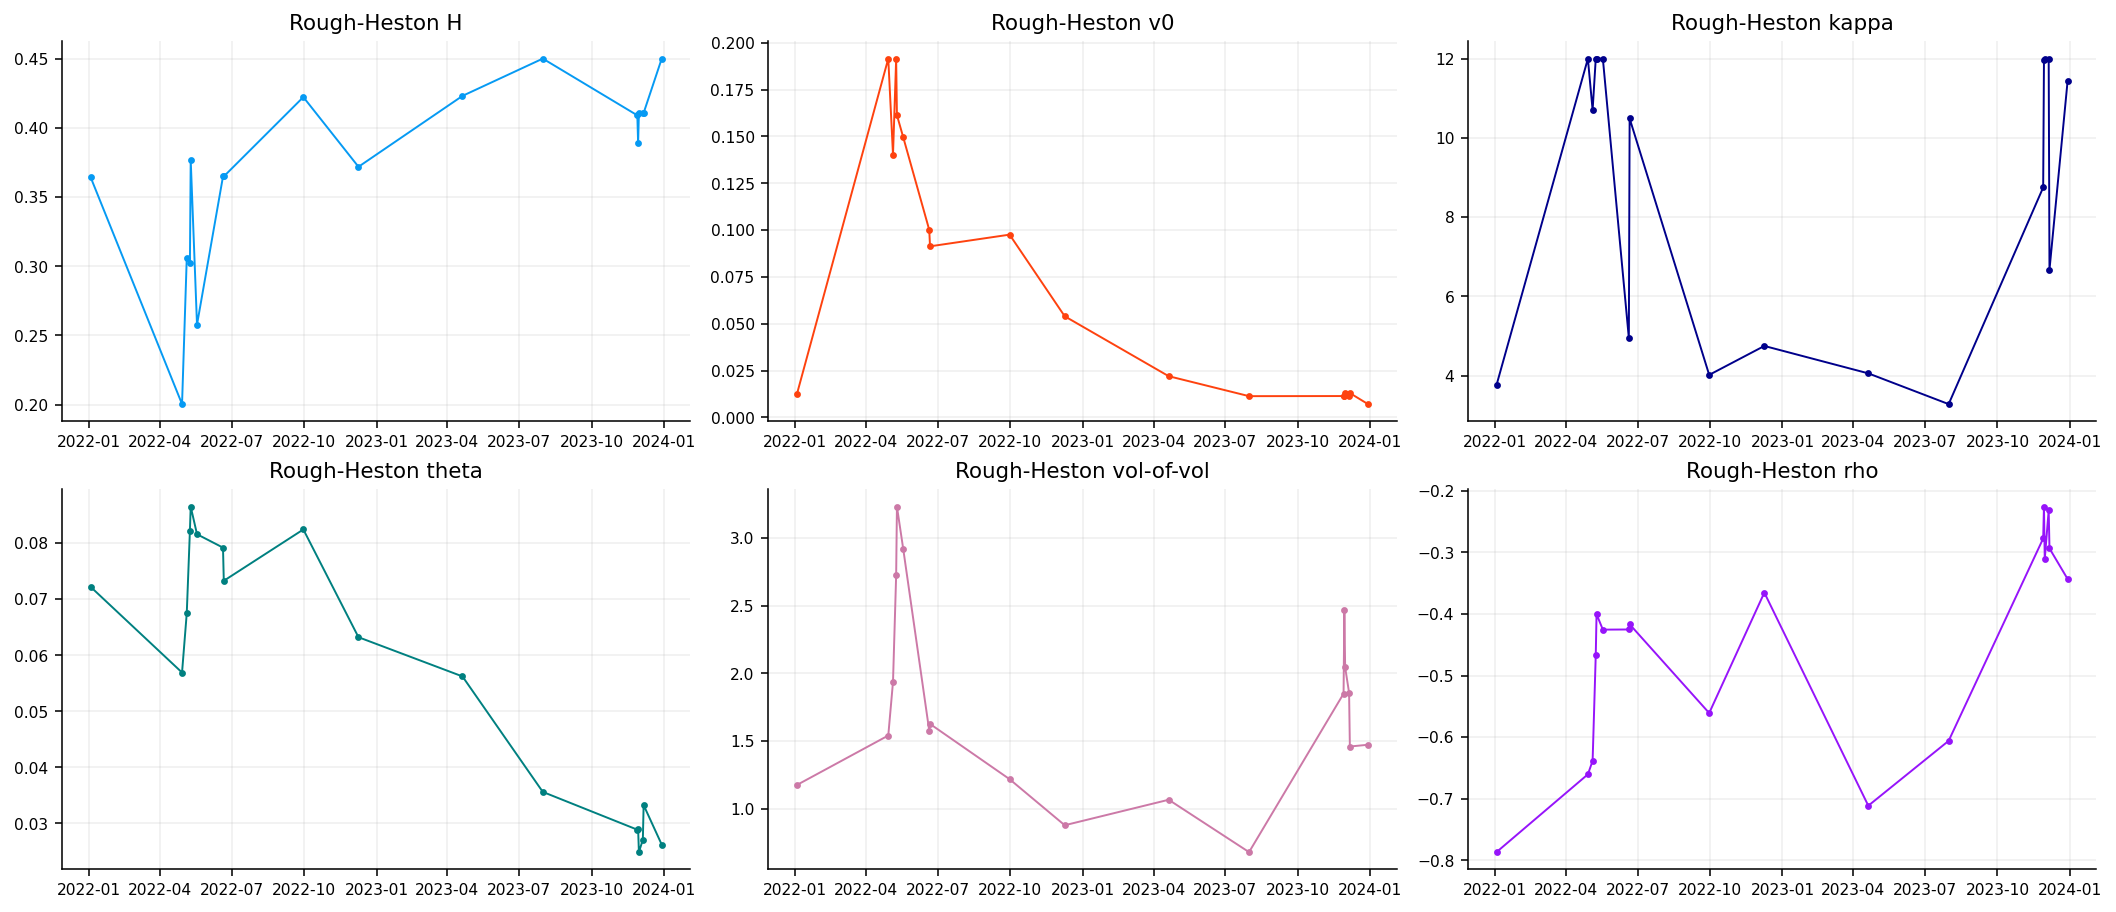

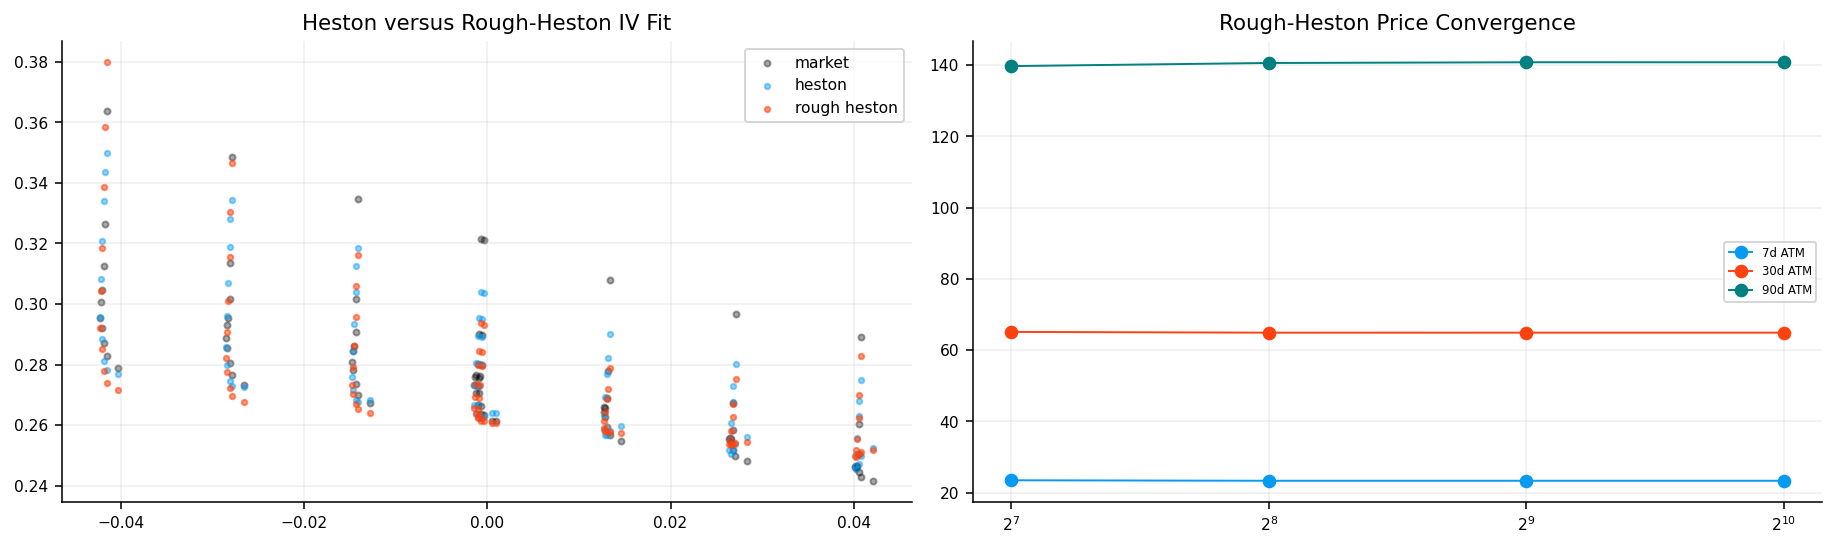

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.4), constrained_layout=True)
axes = axes.ravel()
for i, (col, label) in enumerate([("h", "H"), ("p0", "v0"), ("p1", "kappa"), ("p2", "theta"), ("p3", "vol-of-vol"), ("p4", "rho")]):
    axes[i].plot(rough_daily["date"], rough_daily[col], marker="o", ms=2.5, lw=1.0, color=palette[i])
    axes[i].set_title(f"Rough-Heston {label}")
plt.show()

selected_skew_dates = valid_skew_dates[valid_skew_dates["date"].isin(common_fit_dates)].copy()
if selected_skew_dates.empty:
    selected_skew_dates = skew_history[skew_history["date"].isin(common_fit_dates)].copy()
rough_main_date = selected_skew_dates.sort_values(["r2", "n"], ascending=[False, False])["date"].iloc[0] if not selected_skew_dates.empty else rough_prices.groupby("date").size().sort_values(ascending=False).index[0]
rough_fit_main = rough_prices[rough_prices["date"].eq(rough_main_date)].copy()
heston_fit_for_rough_date = heston_prices[heston_prices["date"].eq(rough_main_date)].copy()
for frame in [rough_fit_main, heston_fit_for_rough_date]:
    frame["k"] = np.log(frame["strike"] / frame["spot"])
rough_fit_main["model_iv"] = rough_fit_main["iv_mid"] + rough_fit_main["price_residual"] / rough_fit_main["vega"].replace(0.0, np.nan)
heston_fit_for_rough_date["model_iv"] = heston_fit_for_rough_date["iv_mid"] + heston_fit_for_rough_date["price_residual"] / heston_fit_for_rough_date["vega"].replace(0.0, np.nan)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
axes[0].scatter(rough_fit_main["k"], rough_fit_main["iv_mid"], s=10, alpha=0.35, color="black", label="market")
axes[0].scatter(heston_fit_for_rough_date["k"], heston_fit_for_rough_date["model_iv"], s=8, alpha=0.45, color=palette[0], label="heston")
axes[0].scatter(rough_fit_main["k"], rough_fit_main["model_iv"], s=8, alpha=0.55, color=palette[1], label="rough heston")
axes[0].set_title("Heston versus Rough-Heston IV Fit")
axes[0].legend()
for i, row in price_grid_test.iterrows():
    if row["strike_type"] == "ATM":
        axes[1].plot([128, 256, 512, 1024], [row["price_128"], row["price_256"], row["price_512"], row["price_1024"]], marker="o", lw=1.0, color=palette[int(row["tau_days"] in [30, 90]) + (2 if row["tau_days"] == 90 else 0)], label=f"{int(row['tau_days'])}d ATM")
axes[1].set_xscale("log", base=2)
axes[1].set_title("Rough-Heston Price Convergence")
axes[1].legend(fontsize=6)
plt.show()


e:\daneshgah\quantitative-finance-lab\.venv\Lib\site-packages\numba\core\typing\typeof.py:268: FutureWarning: future versions will not create a writeable array from broadcast_array. Set the writable flag explicitly to avoid this warning.
  readonly = not val.flags.writeable


,model,tau,tau_days,atm_iv,atm_skew,n
0,market,0.019165,7.0,0.321564,-0.970961,280
1,market,0.027379,10.0,0.290005,-0.860513,420
2,market,0.038330,14.0,0.280243,-0.802222,560
3,market,0.057495,21.0,0.276439,-0.741694,420
4,market,0.082136,30.0,0.275759,-0.681182,280
5,market,0.123203,45.0,0.273102,-0.601959,280
6,market,0.164271,60.0,0.270727,-0.558568,140
7,market,0.246407,90.0,0.266568,-0.518243,140
8,market,0.328542,120.0,0.263562,-0.488308,140
9,market,0.410678,150.0,0.261370,-0.455412,0


,model,alpha,h_from_skew,r2,n
0,market,0.24223,0.25777,0.99258,6
1,heston,0.37881,0.12119,0.97210,6
2,rough_heston,0.56082,-0.06082,0.99845,6


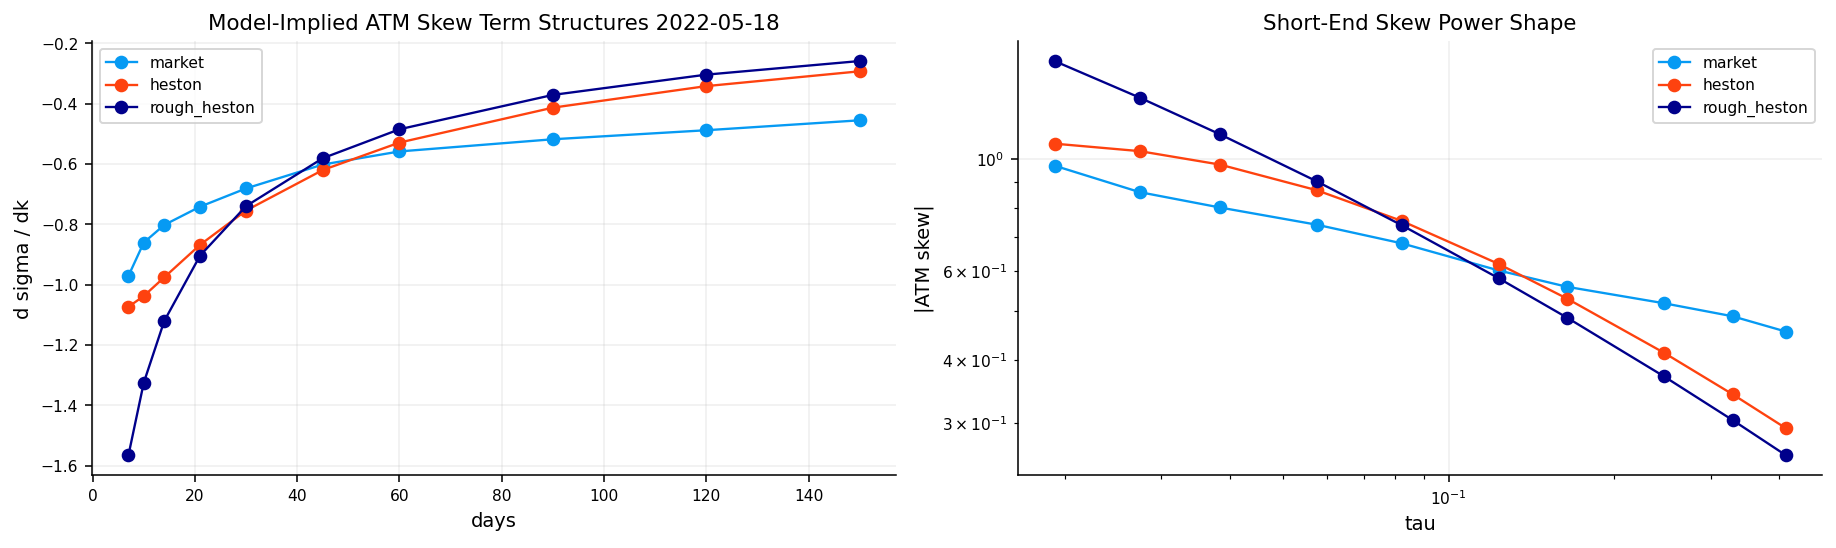

In [33]:
def model_atm_skew(model_name, params, spot, rate, dividend_yield, tau_values, dk=0.01):
    rows = []
    for tau in np.asarray(tau_values, dtype=float):
        k_nodes = np.array([-dk, 0.0, dk], dtype=float)
        strikes = spot * np.exp(k_nodes)
        tau_arr = np.full_like(strikes, tau)
        if model_name == "heston":
            price = cos_prices("heston", params, strikes, tau_arr, spot, rate, dividend_yield, option_type="call", engine="cpp", n_terms=192, truncation_width=16.0)
        elif model_name == "rough_heston":
            price = rough_heston_px(params, strikes, tau_arr, spot, rate, dividend_yield, "call", n_terms=128, riccati_steps=512)
        else:
            continue
        forward = spot * np.exp((rate - dividend_yield) * tau)
        discount = np.exp(-rate * tau)
        iv = implied_vol("call", price, forward, strikes, tau_arr, discount, engine="auto")
        rows.append({"model": model_name, "tau": tau, "tau_days": tau * ann_days, "atm_iv": float(iv[1]), "atm_skew": float((iv[2] - iv[0]) / (2.0 * dk)), "n": 3})
    return pd.DataFrame(rows)


selected_date = pd.Timestamp(rough_main_date).normalize()
selected_quotes = surface_quotes[surface_quotes["date"].eq(selected_date)].copy()
selected_fit = surface_fit["visual_fits"][selected_date]
selected_spot = float(selected_quotes["spot"].median())
selected_rate = float(selected_quotes["rate"].median())
selected_div = float(selected_quotes["implied_dividend_yield"].median())
selected_market_skew = atm_skew(selected_quotes, selected_fit, tau_values).assign(model="market")
selected_heston_row = heston_daily[heston_daily["date"].eq(selected_date)].iloc[0]
selected_rough_row = rough_daily[rough_daily["date"].eq(selected_date)].iloc[0]
selected_heston_params = np.array([selected_heston_row["p0"], selected_heston_row["p1"], selected_heston_row["p2"], selected_heston_row["p3"], selected_heston_row["p4"]], dtype=float)
selected_rough_params = rough_heston_params_array(selected_rough_row)
selected_heston_skew = model_atm_skew("heston", selected_heston_params, selected_spot, selected_rate, selected_div, tau_values)
selected_rough_skew = model_atm_skew("rough_heston", selected_rough_params, selected_spot, selected_rate, selected_div, tau_values)
model_skew_table = pd.concat([selected_market_skew[["model", "tau", "tau_days", "atm_iv", "atm_skew", "n"]], selected_heston_skew, selected_rough_skew], ignore_index=True)
model_skew_power = pd.concat([
    power_law(model_skew_table[model_skew_table["model"].eq(model)], tau_min_days=7, tau_max_days=60, window=model).assign(model=model)
    for model in model_skew_table["model"].unique()
], ignore_index=True)

display(model_skew_table.round(6))
display(model_skew_power[["model", "alpha", "h_from_skew", "r2", "n"]].round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
for i, (model, g) in enumerate(model_skew_table.groupby("model", sort=False)):
    axes[0].plot(g["tau_days"], g["atm_skew"], marker="o", lw=1.2, color=palette[i], label=model)
    axes[1].plot(g["tau"], g["atm_skew"].abs(), marker="o", lw=1.2, color=palette[i], label=model)
axes[0].set_title(f"Model-Implied ATM Skew Term Structures {selected_date.date()}")
axes[0].set_xlabel("days")
axes[0].set_ylabel("d sigma / dk")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Short-End Skew Power Shape")
axes[1].set_xlabel("tau")
axes[1].set_ylabel("|ATM skew|")
for ax in axes:
    ax.legend()
plt.show()


In [34]:
def heston_delta_fd(params, strike, tau, spot, rate, dividend_yield, bump):
    ds = spot * bump
    p_up = cos_prices("heston", params, strike, tau, spot + ds, rate, dividend_yield, option_type="call", engine="cpp", n_terms=128, truncation_width=16.0)
    p_dn = cos_prices("heston", params, strike, tau, spot - ds, rate, dividend_yield, option_type="call", engine="cpp", n_terms=128, truncation_width=16.0)
    return (p_up - p_dn) / (2.0 * ds)


def rough_delta_fd(params, strike, tau, spot, rate, dividend_yield, bump):
    ds = spot * bump
    p_up = rough_heston_px(params, strike, tau, spot + ds, rate, dividend_yield, "call")
    p_dn = rough_heston_px(params, strike, tau, spot - ds, rate, dividend_yield, "call")
    return (p_up - p_dn) / (2.0 * ds)


In [35]:
delta_k = np.linspace(-0.35, 0.25, 49)
delta_days = np.array([7, 14, 30, 60, 90], dtype=float)
delta_rows = []
delta_date = pd.Timestamp(rough_main_date).normalize()
delta_quotes = surface_quotes[surface_quotes["date"].eq(delta_date)].copy()
spot_delta = float(delta_quotes["spot"].median())
heston_delta_row = heston_daily[heston_daily["date"].eq(delta_date)].iloc[0]
rough_delta_row = rough_daily[rough_daily["date"].eq(delta_date)].iloc[0]
heston_params_last = np.array([heston_delta_row["p0"], heston_delta_row["p1"], heston_delta_row["p2"], heston_delta_row["p3"], heston_delta_row["p4"]], dtype=float)
rough_params_last = rough_heston_params_array(rough_delta_row)
rate_main = float(delta_quotes["rate"].median())
div_main = float(delta_quotes["implied_dividend_yield"].median())
sigma_atm = float(delta_quotes["iv_mid"].median())
surface_fit_by_date = {pd.Timestamp(k).normalize(): v for k, v in surface_fit["visual_fits"].items()}
delta_surface_fit = surface_fit_by_date.get(delta_date)

for d in delta_days:
    tau = d / ann_days
    strike = spot_delta * np.exp(delta_k)
    forward = spot_delta * np.exp((rate_main - div_main) * tau)
    discount = np.exp(-rate_main * tau)
    flat_bsm_delta = np.asarray(forward_bsm_delta("call", forward, strike, tau, sigma_atm, discount), dtype=float) * np.exp((rate_main - div_main) * tau)
    if delta_surface_fit is not None:
        surface_sigma = np.asarray(surface_iv(delta_surface_fit, delta_k, np.full_like(delta_k, tau)), dtype=float)
        surface_sigma = np.clip(surface_sigma, 0.03, 5.0)
    else:
        surface_sigma = np.full_like(delta_k, sigma_atm, dtype=float)
    surface_bsm_delta = np.asarray(forward_bsm_delta("call", forward, strike, tau, surface_sigma, discount), dtype=float) * np.exp((rate_main - div_main) * tau)
    heston_delta = heston_delta_fd(heston_params_last, strike, np.full_like(strike, tau), spot_delta, rate_main, div_main, 0.005)
    rough_delta = rough_delta_fd(rough_params_last, strike, np.full_like(strike, tau), spot_delta, rate_main, div_main, 0.005)
    for kk, st, db_flat, db_surface, dh, dr in zip(delta_k, strike, flat_bsm_delta, surface_bsm_delta, heston_delta, rough_delta):
        delta_rows.append({
            "tau_days": d,
            "tau": tau,
            "k": kk,
            "strike": st,
            "bsm_delta": db_flat,
            "flat_bsm_delta": db_flat,
            "surface_bsm_delta": db_surface,
            "heston_delta": dh,
            "rough_heston_delta": dr,
            "rough_minus_bsm": dr - db_flat,
            "rough_minus_flat_bsm": dr - db_flat,
            "rough_minus_surface_bsm": dr - db_surface,
            "rough_minus_heston": dr - dh,
        })

delta_map = pd.DataFrame(delta_rows)
atm_delta_table = delta_map[np.isclose(delta_map["k"], 0.0, atol=0.015)].copy()
display(atm_delta_table.round(5))


,tau_days,tau,k,strike,bsm_delta,flat_bsm_delta,surface_bsm_delta,heston_delta,rough_heston_delta,rough_minus_bsm,rough_minus_flat_bsm,rough_minus_surface_bsm,rough_minus_heston
27,7.0,0.01916,-0.0125,3876.54902,0.63408,0.63408,0.61259,0.67719,0.72741,0.09333,0.09333,0.11482,0.05022
28,7.0,0.01916,0.0000,3925.31000,0.50391,0.50391,0.50583,0.56444,0.59206,0.08815,0.08815,0.08623,0.02762
29,7.0,0.01916,0.0125,3974.68432,0.37330,0.37330,0.39048,0.43061,0.41308,0.03978,0.03978,0.02259,-0.01754
76,14.0,0.03833,-0.0125,3876.54902,0.59825,0.59825,0.59329,0.67115,0.69996,0.10172,0.10172,0.10668,0.02882
77,14.0,0.03833,0.0000,3925.31000,0.50540,0.50540,0.50591,0.58274,0.59333,0.08793,0.08793,0.08742,0.01059
78,14.0,0.03833,0.0125,3974.68432,0.41224,0.41224,0.41185,0.47694,0.46169,0.04945,0.04945,0.04984,-0.01525
125,30.0,0.08214,-0.0125,3876.54902,0.57128,0.57128,0.56945,0.66269,0.66900,0.09772,0.09772,0.09955,0.00631
126,30.0,0.08214,0.0000,3925.31000,0.50761,0.50761,0.50800,0.59396,0.59146,0.08385,0.08385,0.08346,-0.00250
127,30.0,0.08214,0.0125,3974.68432,0.44373,0.44373,0.44241,0.51417,0.50204,0.05831,0.05831,0.05963,-0.01213
174,60.0,0.16427,-0.0125,3876.54902,0.55524,0.55524,0.55493,0.64633,0.64224,0.08700,0.08700,0.08731,-0.00409


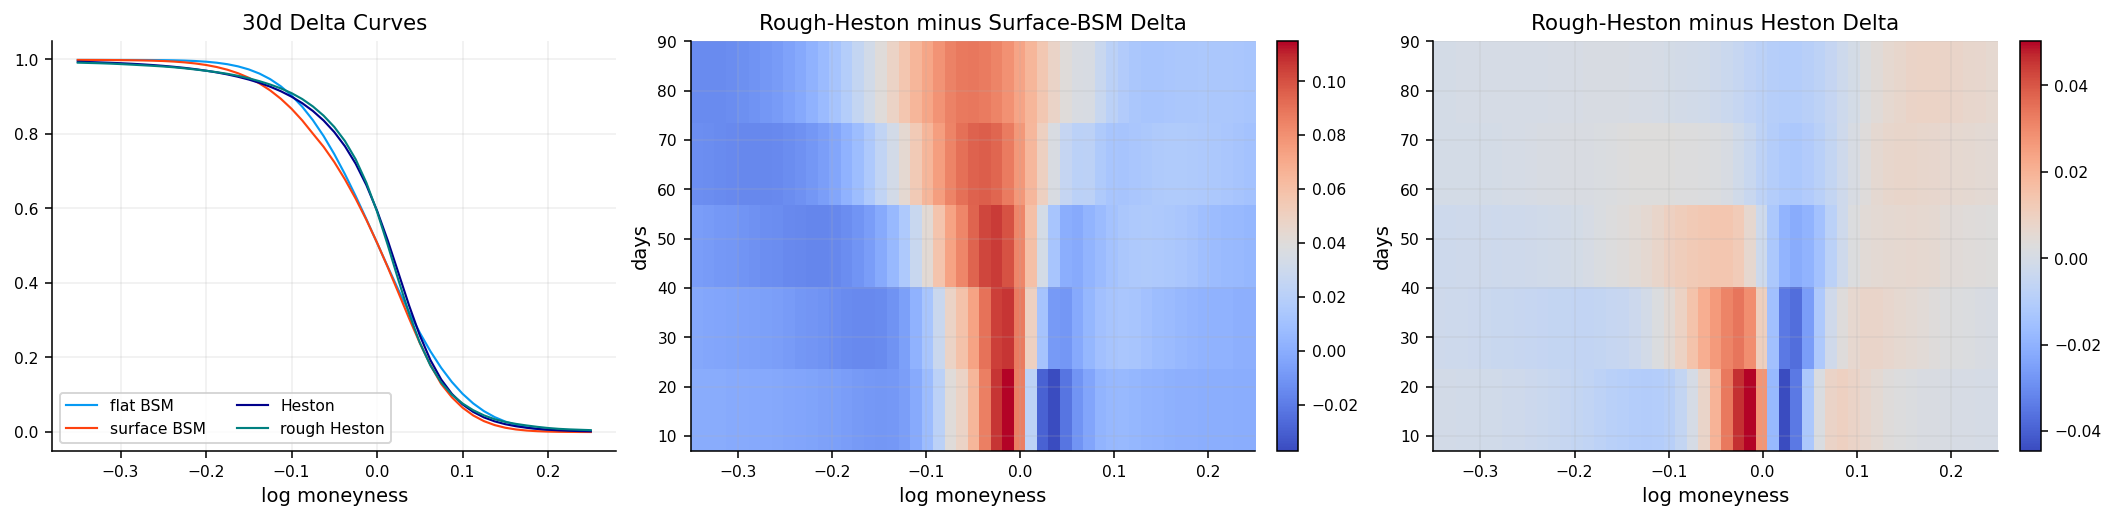

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
plot_delta_day = 30.0 if 30.0 in set(delta_map["tau_days"]) else float(delta_map["tau_days"].iloc[0])
delta_slice = delta_map[delta_map["tau_days"].eq(plot_delta_day)].copy()
for i, (col, label) in enumerate([
    ("flat_bsm_delta", "flat BSM"),
    ("surface_bsm_delta", "surface BSM"),
    ("heston_delta", "Heston"),
    ("rough_heston_delta", "rough Heston"),
]):
    axes[0].plot(delta_slice["k"], delta_slice[col], lw=1.1, color=palette[i], label=label)
for ax, col, title in [(axes[1], "rough_minus_surface_bsm", "Rough-Heston minus Surface-BSM Delta"), (axes[2], "rough_minus_heston", "Rough-Heston minus Heston Delta")]:
    piv = delta_map.pivot_table(index="tau_days", columns="k", values=col)
    im = ax.imshow(piv.to_numpy(dtype=float), origin="lower", aspect="auto", extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()], cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("log moneyness")
    ax.set_ylabel("days")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0].set_title(f"{plot_delta_day:.0f}d Delta Curves")
axes[0].set_xlabel("log moneyness")
axes[0].legend(ncol=2)
plt.show()


roughness_evidence


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16732\57385579.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  "atm_skew_roughness": skew_history[["date", "alpha", "h_from_skew", "r2", "n"]].round(5),


,source,sample,h,standard_error,r2,n,interpretation
0,raw daily squared-return RV,1990-01-03 to 2026-02-24,0.00176,0.00552,0.04415,30,noisy diagnostic
1,rolling Project-5 RV 5d,1990-01-09 to 2026-02-24,0.28778,0.07485,0.89108,30,aggregated Project-5 RV proxy
2,rolling Project-5 RV 10d,1990-01-16 to 2026-02-24,0.45690,0.06523,0.96346,30,aggregated Project-5 RV proxy
3,rolling Project-5 RV 21d,1990-01-31 to 2026-02-24,0.60387,0.03104,0.99442,30,aggregated Project-5 RV proxy
4,ATM skew power law,2022-01-03 to 2023-12-29,0.41075,NaN,0.86409,342,option-skew roughness
5,"ATM skew power law, high quality",2022-01-03 to 2023-12-29,0.36454,NaN,0.96314,204,R2>=0.80 and at least six maturities
6,rough-Heston calibration,2022-01-03 to 2023-12-29,0.38288,NaN,NaN,1580,risk-neutral calibrated H


rv_roughness


,q,slope,h,standard_error,r2,n,proxy
0,0.5,0.27316,0.54632,0.03211,0.94762,6,rolling Project-5 RV 10d
1,1.0,0.49568,0.49568,0.05166,0.95836,6,rolling Project-5 RV 10d
2,1.5,0.68534,0.45690,0.06523,0.96503,6,rolling Project-5 RV 10d
3,2.0,0.85008,0.42504,0.07508,0.96974,6,rolling Project-5 RV 10d
4,3.0,1.12233,0.37411,0.08693,0.97657,6,rolling Project-5 RV 10d


...

,window,median_h_all_dates,median_h_high_quality_dates,dates,high_quality_dates,rejected_dates
0,short_2_7_60,0.41075,0.36454,57,34,23


bucket_improvement


,moneyness_bucket,dte_bucket,heston_abs_median_scaled_residual,rough_abs_median_scaled_residual,improvement_percent,rows_heston,rows_rough
14,"(-0.05, 0.05]","(30, 60]",0.22337,0.04332,80.60450,542,226
3,"(-0.3, -0.15]","(60, 90]",0.56110,0.13412,76.09771,10,6
2,"(-0.3, -0.15]","(30, 60]",0.39028,0.17383,55.45957,22,14
6,"(-0.15, -0.05]","(0, 14]",0.90776,0.45122,50.29299,294,117
17,"(-0.05, 0.05]","(120, 180]",0.15349,0.10011,34.77859,286,118
8,"(-0.15, -0.05]","(30, 60]",0.40500,0.37037,8.54949,188,72
23,"(0.05, 0.15]","(120, 180]",1.06092,0.97926,7.69678,7,4
22,"(0.05, 0.15]","(90, 120]",0.93016,0.86012,7.53046,6,4
19,"(0.05, 0.15]","(14, 30]",0.67643,0.65491,3.18165,4,4
18,"(0.05, 0.15]","(0, 14]",0.44838,0.48765,-8.75838,6,6


delta_differences


,tau_days,tau,k,strike,bsm_delta,flat_bsm_delta,surface_bsm_delta,heston_delta,rough_heston_delta,rough_minus_bsm,rough_minus_flat_bsm,rough_minus_surface_bsm,rough_minus_heston
27,7.0,0.01916,-0.0125,3876.54902,0.63408,0.63408,0.61259,0.67719,0.72741,0.09333,0.09333,0.11482,0.05022
28,7.0,0.01916,0.0000,3925.31000,0.50391,0.50391,0.50583,0.56444,0.59206,0.08815,0.08815,0.08623,0.02762
29,7.0,0.01916,0.0125,3974.68432,0.37330,0.37330,0.39048,0.43061,0.41308,0.03978,0.03978,0.02259,-0.01754
76,14.0,0.03833,-0.0125,3876.54902,0.59825,0.59825,0.59329,0.67115,0.69996,0.10172,0.10172,0.10668,0.02882
77,14.0,0.03833,0.0000,3925.31000,0.50540,0.50540,0.50591,0.58274,0.59333,0.08793,0.08793,0.08742,0.01059
78,14.0,0.03833,0.0125,3974.68432,0.41224,0.41224,0.41185,0.47694,0.46169,0.04945,0.04945,0.04984,-0.01525
125,30.0,0.08214,-0.0125,3876.54902,0.57128,0.57128,0.56945,0.66269,0.66900,0.09772,0.09772,0.09955,0.00631
126,30.0,0.08214,0.0000,3925.31000,0.50761,0.50761,0.50800,0.59396,0.59146,0.08385,0.08385,0.08346,-0.00250
127,30.0,0.08214,0.0125,3974.68432,0.44373,0.44373,0.44241,0.51417,0.50204,0.05831,0.05831,0.05963,-0.01213
174,60.0,0.16427,-0.0125,3876.54902,0.55524,0.55524,0.55493,0.64633,0.64224,0.08700,0.08700,0.08731,-0.00409


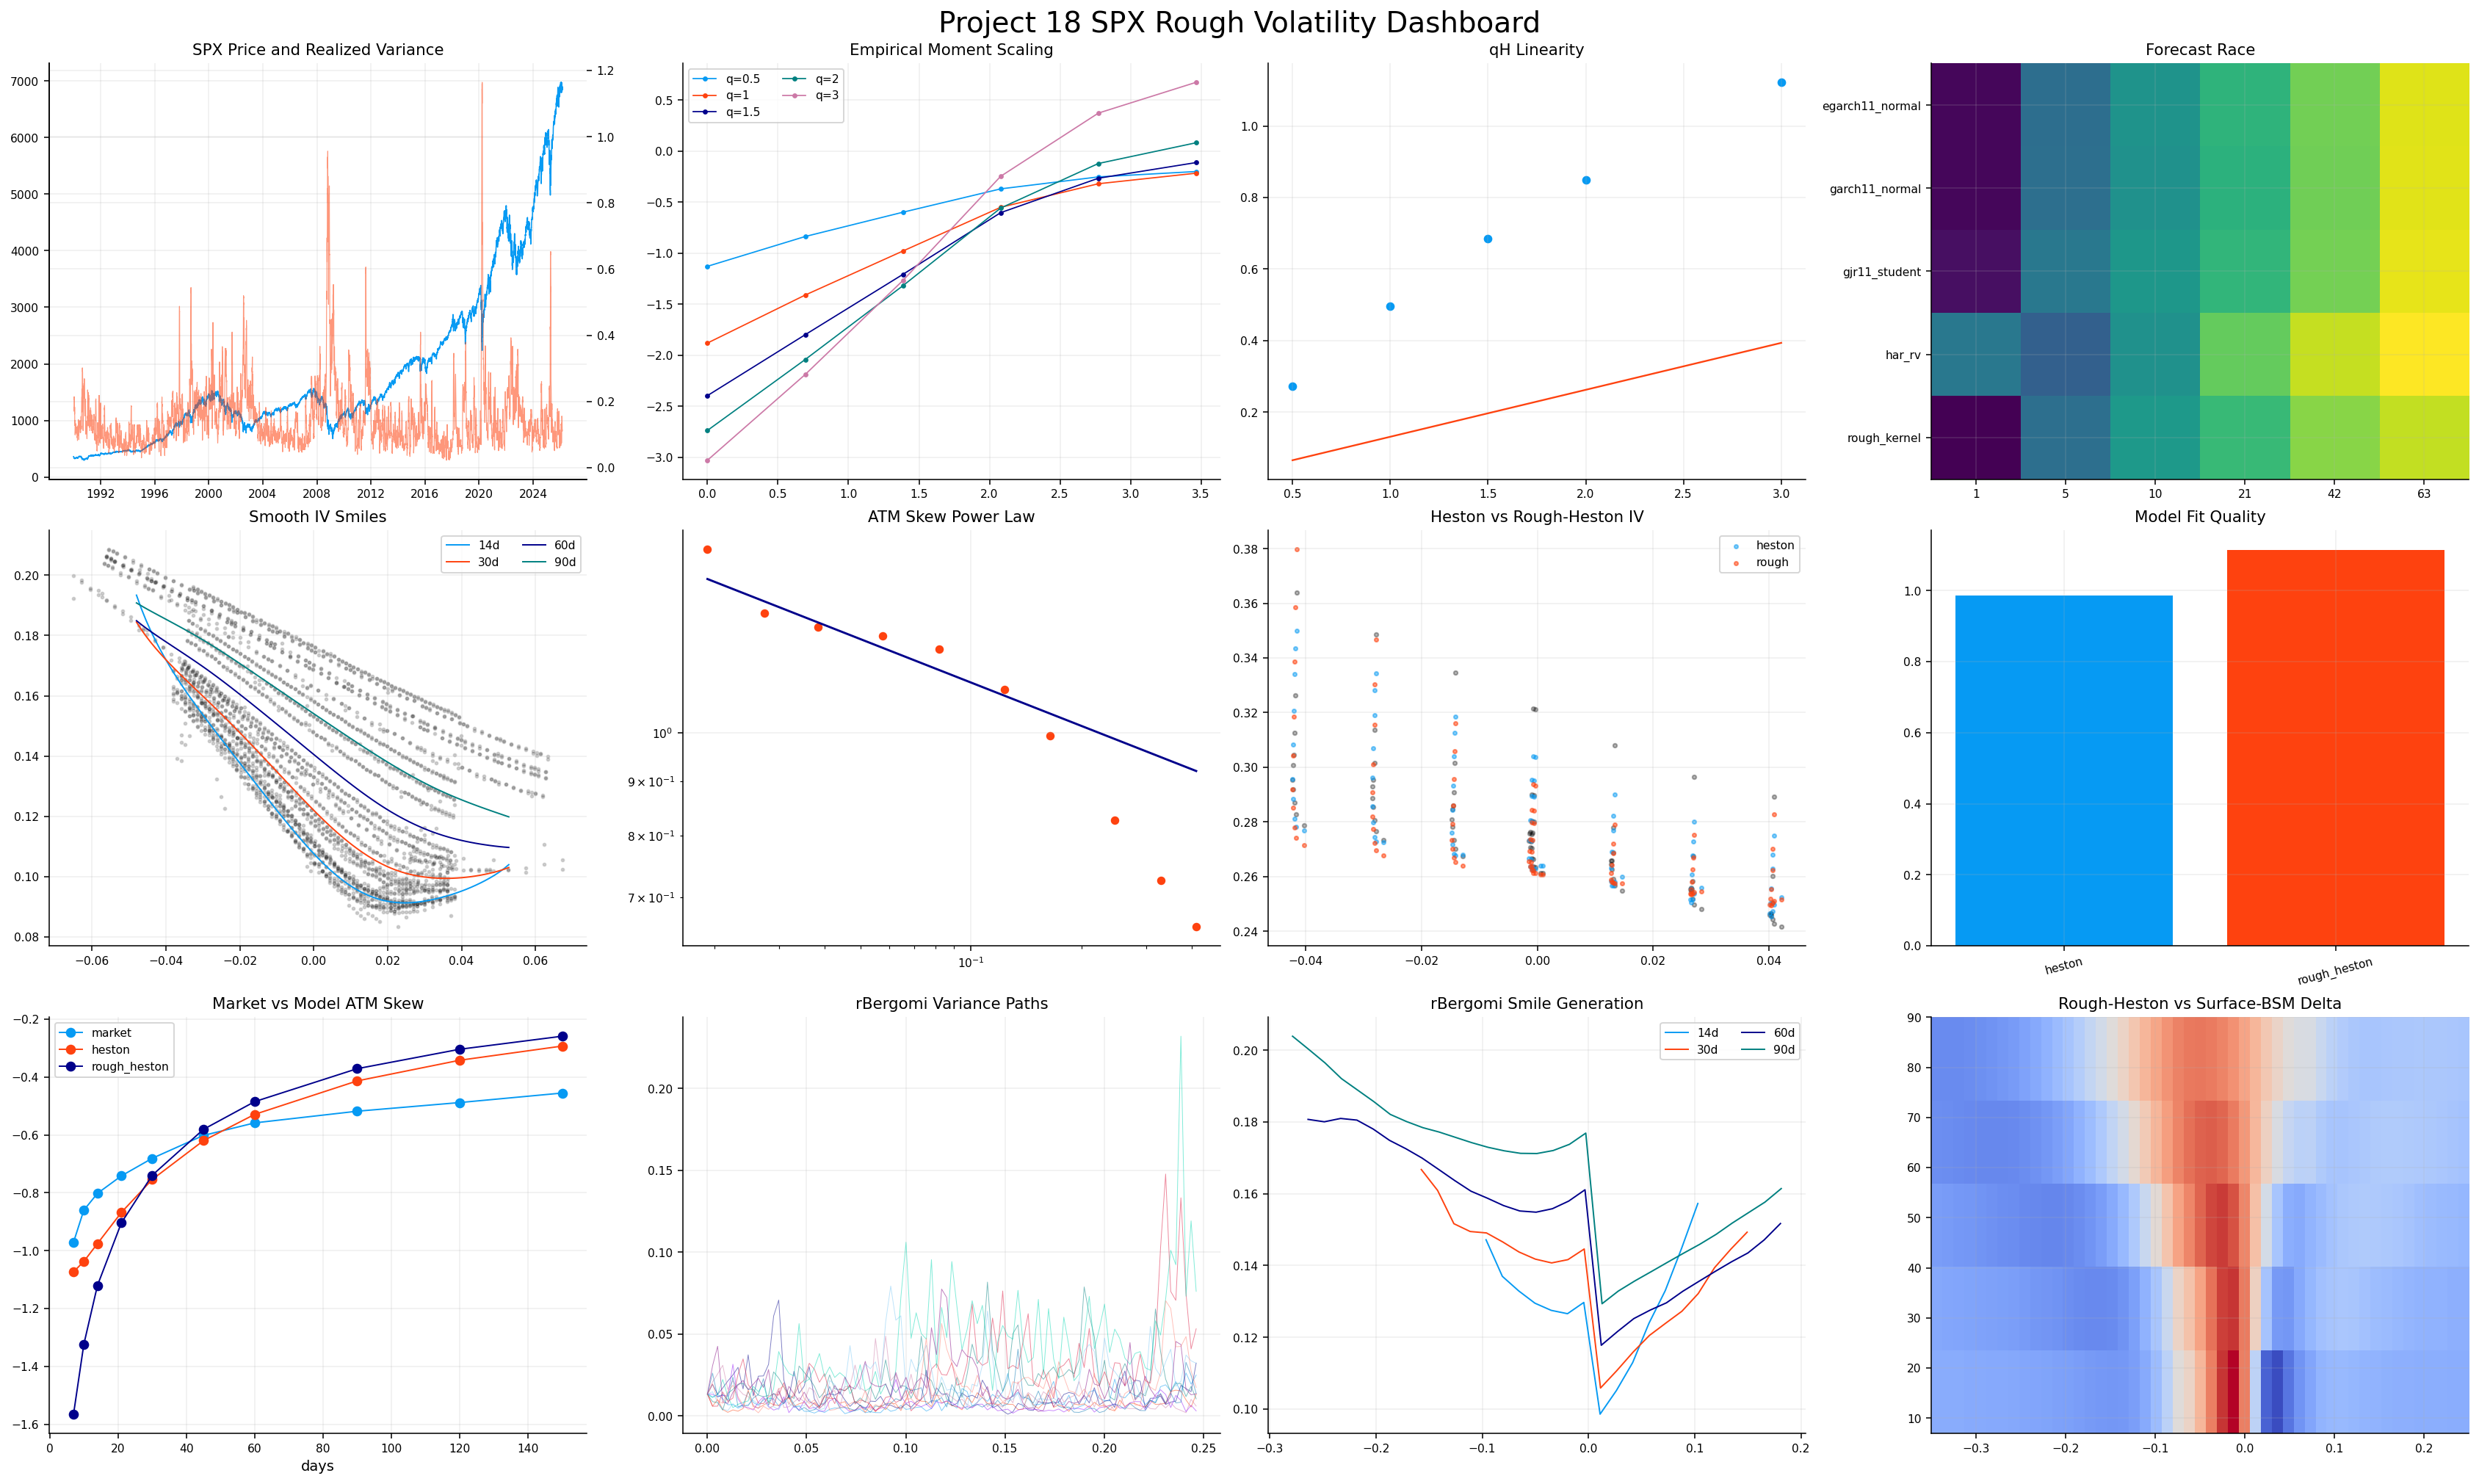

In [37]:
spx_tables = {
    "roughness_evidence": pd.concat([
        roughness_proxy_table,
        pd.DataFrame([{"source": "ATM skew power law", "sample": f"{skew_history['date'].min().date()} to {skew_history['date'].max().date()}", "h": float(skew_history["h_from_skew"].median()), "standard_error": np.nan, "r2": float(skew_history["r2"].median()), "n": int(skew_history["n"].sum()), "interpretation": "option-skew roughness"}]),
        pd.DataFrame([{"source": "ATM skew power law, high quality", "sample": f"{valid_skew_dates['date'].min().date()} to {valid_skew_dates['date'].max().date()}" if not valid_skew_dates.empty else "no dates pass filter", "h": float(valid_skew_dates["h_from_skew"].median()) if not valid_skew_dates.empty else np.nan, "standard_error": np.nan, "r2": float(valid_skew_dates["r2"].median()) if not valid_skew_dates.empty else np.nan, "n": int(valid_skew_dates["n"].sum()) if not valid_skew_dates.empty else 0, "interpretation": "R2>=0.80 and at least six maturities"}]),
        pd.DataFrame([{"source": "rough-Heston calibration", "sample": f"{rough_daily['date'].min().date()} to {rough_daily['date'].max().date()}", "h": float(rough_daily["h"].median()), "standard_error": np.nan, "r2": np.nan, "n": int(rough_daily["quotes"].sum()), "interpretation": "risk-neutral calibrated H"}]),
    ], ignore_index=True).round(5),
    "rv_roughness": emp_hurst.round(5),
    "atm_skew_roughness": skew_history[["date", "alpha", "h_from_skew", "r2", "n"]].round(5),
    "fit_quality": model_quality.round(5),
    "skew_quality_filter": skew_quality_summary.round(5),
    "bucket_improvement": bucket_improvement.head(12).round(5),
    "delta_differences": atm_delta_table.round(5),
}

for name, table in spx_tables.items():
    print(name)
    display(table)

fig, axes = plt.subplots(3, 4, figsize=(24, 14), constrained_layout=True)
axes = axes.ravel()
axes[0].plot(spx_spot.index, spx_spot["close"], lw=0.8, color=palette[0])
axes0b = axes[0].twinx()
axes0b.plot(spx_var.index, np.sqrt(ann_trading * spx_var), lw=0.6, alpha=0.55, color=palette[1])
axes[0].set_title("SPX Price and Realized Variance")
for i, (q, g) in enumerate(emp_scaling.groupby("q")):
    axes[1].plot(g["log_lag"], g["log_moment"], marker="o", ms=2.5, lw=0.9, color=palette[i], label=f"q={q:g}")
axes[1].set_title("Empirical Moment Scaling")
axes[1].legend(ncol=2)
axes[2].scatter(emp_hurst["q"], emp_hurst["slope"], s=25, color=palette[0])
axes[2].plot(np.asarray(q_values), h_rv * np.asarray(q_values), color=palette[1], lw=1.2)
axes[2].set_title("qH Linearity")
heat = forecast_scores.pivot_table(index="model", columns="horizon", values="qlike_var", aggfunc="mean")
axes[3].imshow(heat.to_numpy(dtype=float), aspect="auto", cmap="viridis")
axes[3].set_yticks(range(len(heat.index)))
axes[3].set_yticklabels(heat.index)
axes[3].set_xticks(range(len(heat.columns)))
axes[3].set_xticklabels(heat.columns)
axes[3].set_title("Forecast Race")
for i, d in enumerate([14, 30, 60, 90]):
    k_line = np.linspace(k_grid["k"].min(), k_grid["k"].max(), 80)
    axes[4].plot(k_line, surface_iv(fit_visual, k_line, np.full_like(k_line, d / ann_days)), lw=1.0, color=palette[i], label=f"{d}d")
axes[4].scatter(q_main["k"], q_main["iv_mid"], s=4, alpha=0.15, color="black")
axes[4].set_title("Smooth IV Smiles")
axes[4].legend(ncol=2)
axes[5].scatter(psi_main["tau"], psi_main["atm_skew"].abs(), s=24, color=palette[1])
xs = np.linspace(psi_main["tau"].min(), psi_main["tau"].max(), 80)
axes[5].plot(xs, skew_fit_main["c"].iloc[0] * xs ** (-skew_fit_main["alpha"].iloc[0]), color=palette[2])
axes[5].set_xscale("log")
axes[5].set_yscale("log")
axes[5].set_title("ATM Skew Power Law")
axes[6].scatter(rough_fit_main["k"], rough_fit_main["iv_mid"], s=8, alpha=0.30, color="black")
axes[6].scatter(heston_fit_for_rough_date["k"], heston_fit_for_rough_date["model_iv"], s=7, alpha=0.50, color=palette[0], label="heston")
axes[6].scatter(rough_fit_main["k"], rough_fit_main["model_iv"], s=7, alpha=0.55, color=palette[1], label="rough")
axes[6].set_title("Heston vs Rough-Heston IV")
axes[6].legend()
axes[7].bar(model_quality["model"], model_quality["weighted_price_rmse"], color=palette[:len(model_quality)])
axes[7].set_title("Model Fit Quality")
axes[7].tick_params(axis="x", rotation=15)
for i, (model, g) in enumerate(model_skew_table.groupby("model", sort=False)):
    axes[8].plot(g["tau_days"], g["atm_skew"], marker="o", lw=1.0, color=palette[i], label=model)
axes[8].set_title("Market vs Model ATM Skew")
axes[8].set_xlabel("days")
axes[8].legend(ncol=1)
for i in range(12):
    axes[9].plot(time_grid, rbergomi_v[i], lw=0.5, alpha=0.5)
axes[9].set_title("rBergomi Variance Paths")
for i, (d, g) in enumerate(rbergomi_iv.groupby("tau_days")):
    axes[10].plot(g["k"], g["iv"], lw=1.0, color=palette[i], label=f"{d:.0f}d")
axes[10].set_title("rBergomi Smile Generation")
axes[10].legend(ncol=2)
piv = delta_map.pivot_table(index="tau_days", columns="k", values="rough_minus_surface_bsm")
axes[11].imshow(piv.to_numpy(dtype=float), origin="lower", aspect="auto", extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()], cmap="coolwarm")
axes[11].set_title("Rough-Heston vs Surface-BSM Delta")
fig.suptitle("Project 18 SPX Rough Volatility Dashboard", fontsize=20, y=1.02)
plt.show()


e:\daneshgah\quantitative-finance-lab\.venv\Lib\site-packages\numba\core\typing\typeof.py:268: FutureWarning: future versions will not create a writeable array from broadcast_array. Set the writable flag explicitly to avoid this warning.
  readonly = not val.flags.writeable


summary


,asset,spot_start,spot_end,return_days,option_rows_clean,surface_rows,surface_target_rows,main_date,main_date_rule,h_from_rv,h_from_skew,h_used_for_rough_heston,skew_r2,skew_high_quality_dates,rough_dates,heston_dates
0,BTC,457.334015,73845.9375,4274,121361,120736,27106,2024-01-13,best short-skew R2 with surface RMSE tiebreak,0.35,0.121271,0.121271,0.999026,129,12,12


btc_unit_audit


,input_file,price_unit,spot_median,raw_mid_median_btc,usd_mid_median
0,btc_usd_yfinance_max.csv,base,63931.0229,0.054625,3369.138183


...

,restart,h,nu,rho,iv_mse,iv_rmse
0,29,0.12127,0.80000,-0.30000,0.049163,0.221728
1,-1,0.12127,0.80000,-0.30000,0.051118,0.226093
2,4,0.12127,1.10000,-0.30000,0.071139,0.266719
3,-1,0.12127,1.10000,-0.30000,0.073416,0.270954
4,28,0.12127,0.80000,-0.50000,0.090796,0.301323
5,34,0.12127,1.40000,-0.30000,0.092699,0.304465
6,-1,0.12127,0.80000,-0.50000,0.092907,0.304806
7,27,0.12127,0.80000,-0.55000,0.101254,0.318205
8,9,0.12127,1.60000,-0.30000,0.106195,0.325876
9,50,0.30000,2.00000,-0.70000,0.113188,0.336435


riccati_test


,riccati_steps,terminal_abs,price,abs_change
0,128,0.048171,0.548966,NaN
1,256,0.048171,0.546154,0.002812
2,512,0.048171,0.544404,0.001750


delta_sample


,tau_days,tau,k,strike,bsm_delta,flat_bsm_delta,surface_bsm_delta,heston_delta,rough_heston_delta,rough_minus_bsm,rough_minus_flat_bsm,rough_minus_surface_bsm,rough_minus_heston
27,7.0,0.019165,-0.0125,42806.125228,0.575634,0.575634,0.576919,0.587004,0.617259,0.041626,0.041626,0.040340,0.030256
28,7.0,0.019165,0.0000,43344.560000,0.516110,0.516110,0.515554,0.505719,0.522119,0.006009,0.006009,0.006565,0.016400
29,7.0,0.019165,0.0125,43889.767448,0.456212,0.456212,0.453293,0.425018,0.424689,-0.031522,-0.031522,-0.028604,-0.000328
76,14.0,0.038330,-0.0125,42806.125228,0.564536,0.564536,0.567134,0.569402,0.590869,0.026333,0.026333,0.023735,0.021467
77,14.0,0.038330,0.0000,43344.560000,0.522448,0.522448,0.519844,0.509240,0.527881,0.005434,0.005434,0.008038,0.018642
78,14.0,0.038330,0.0125,43889.767448,0.480094,0.480094,0.471928,0.449453,0.463747,-0.016348,-0.016348,-0.008182,0.014293
125,30.0,0.082136,-0.0125,42806.125228,0.560708,0.560708,0.560518,0.557958,0.576067,0.015359,0.015359,0.015549,0.018109
126,30.0,0.082136,0.0000,43344.560000,0.532053,0.532053,0.528721,0.516963,0.537495,0.005443,0.005443,0.008774,0.020532
127,30.0,0.082136,0.0125,43889.767448,0.503217,0.503217,0.496568,0.476092,0.498406,-0.004811,-0.004811,0.001838,0.022314
174,60.0,0.164271,-0.0125,42806.125228,0.563867,0.563867,0.561582,0.556231,0.574724,0.010858,0.010858,0.013142,0.018494


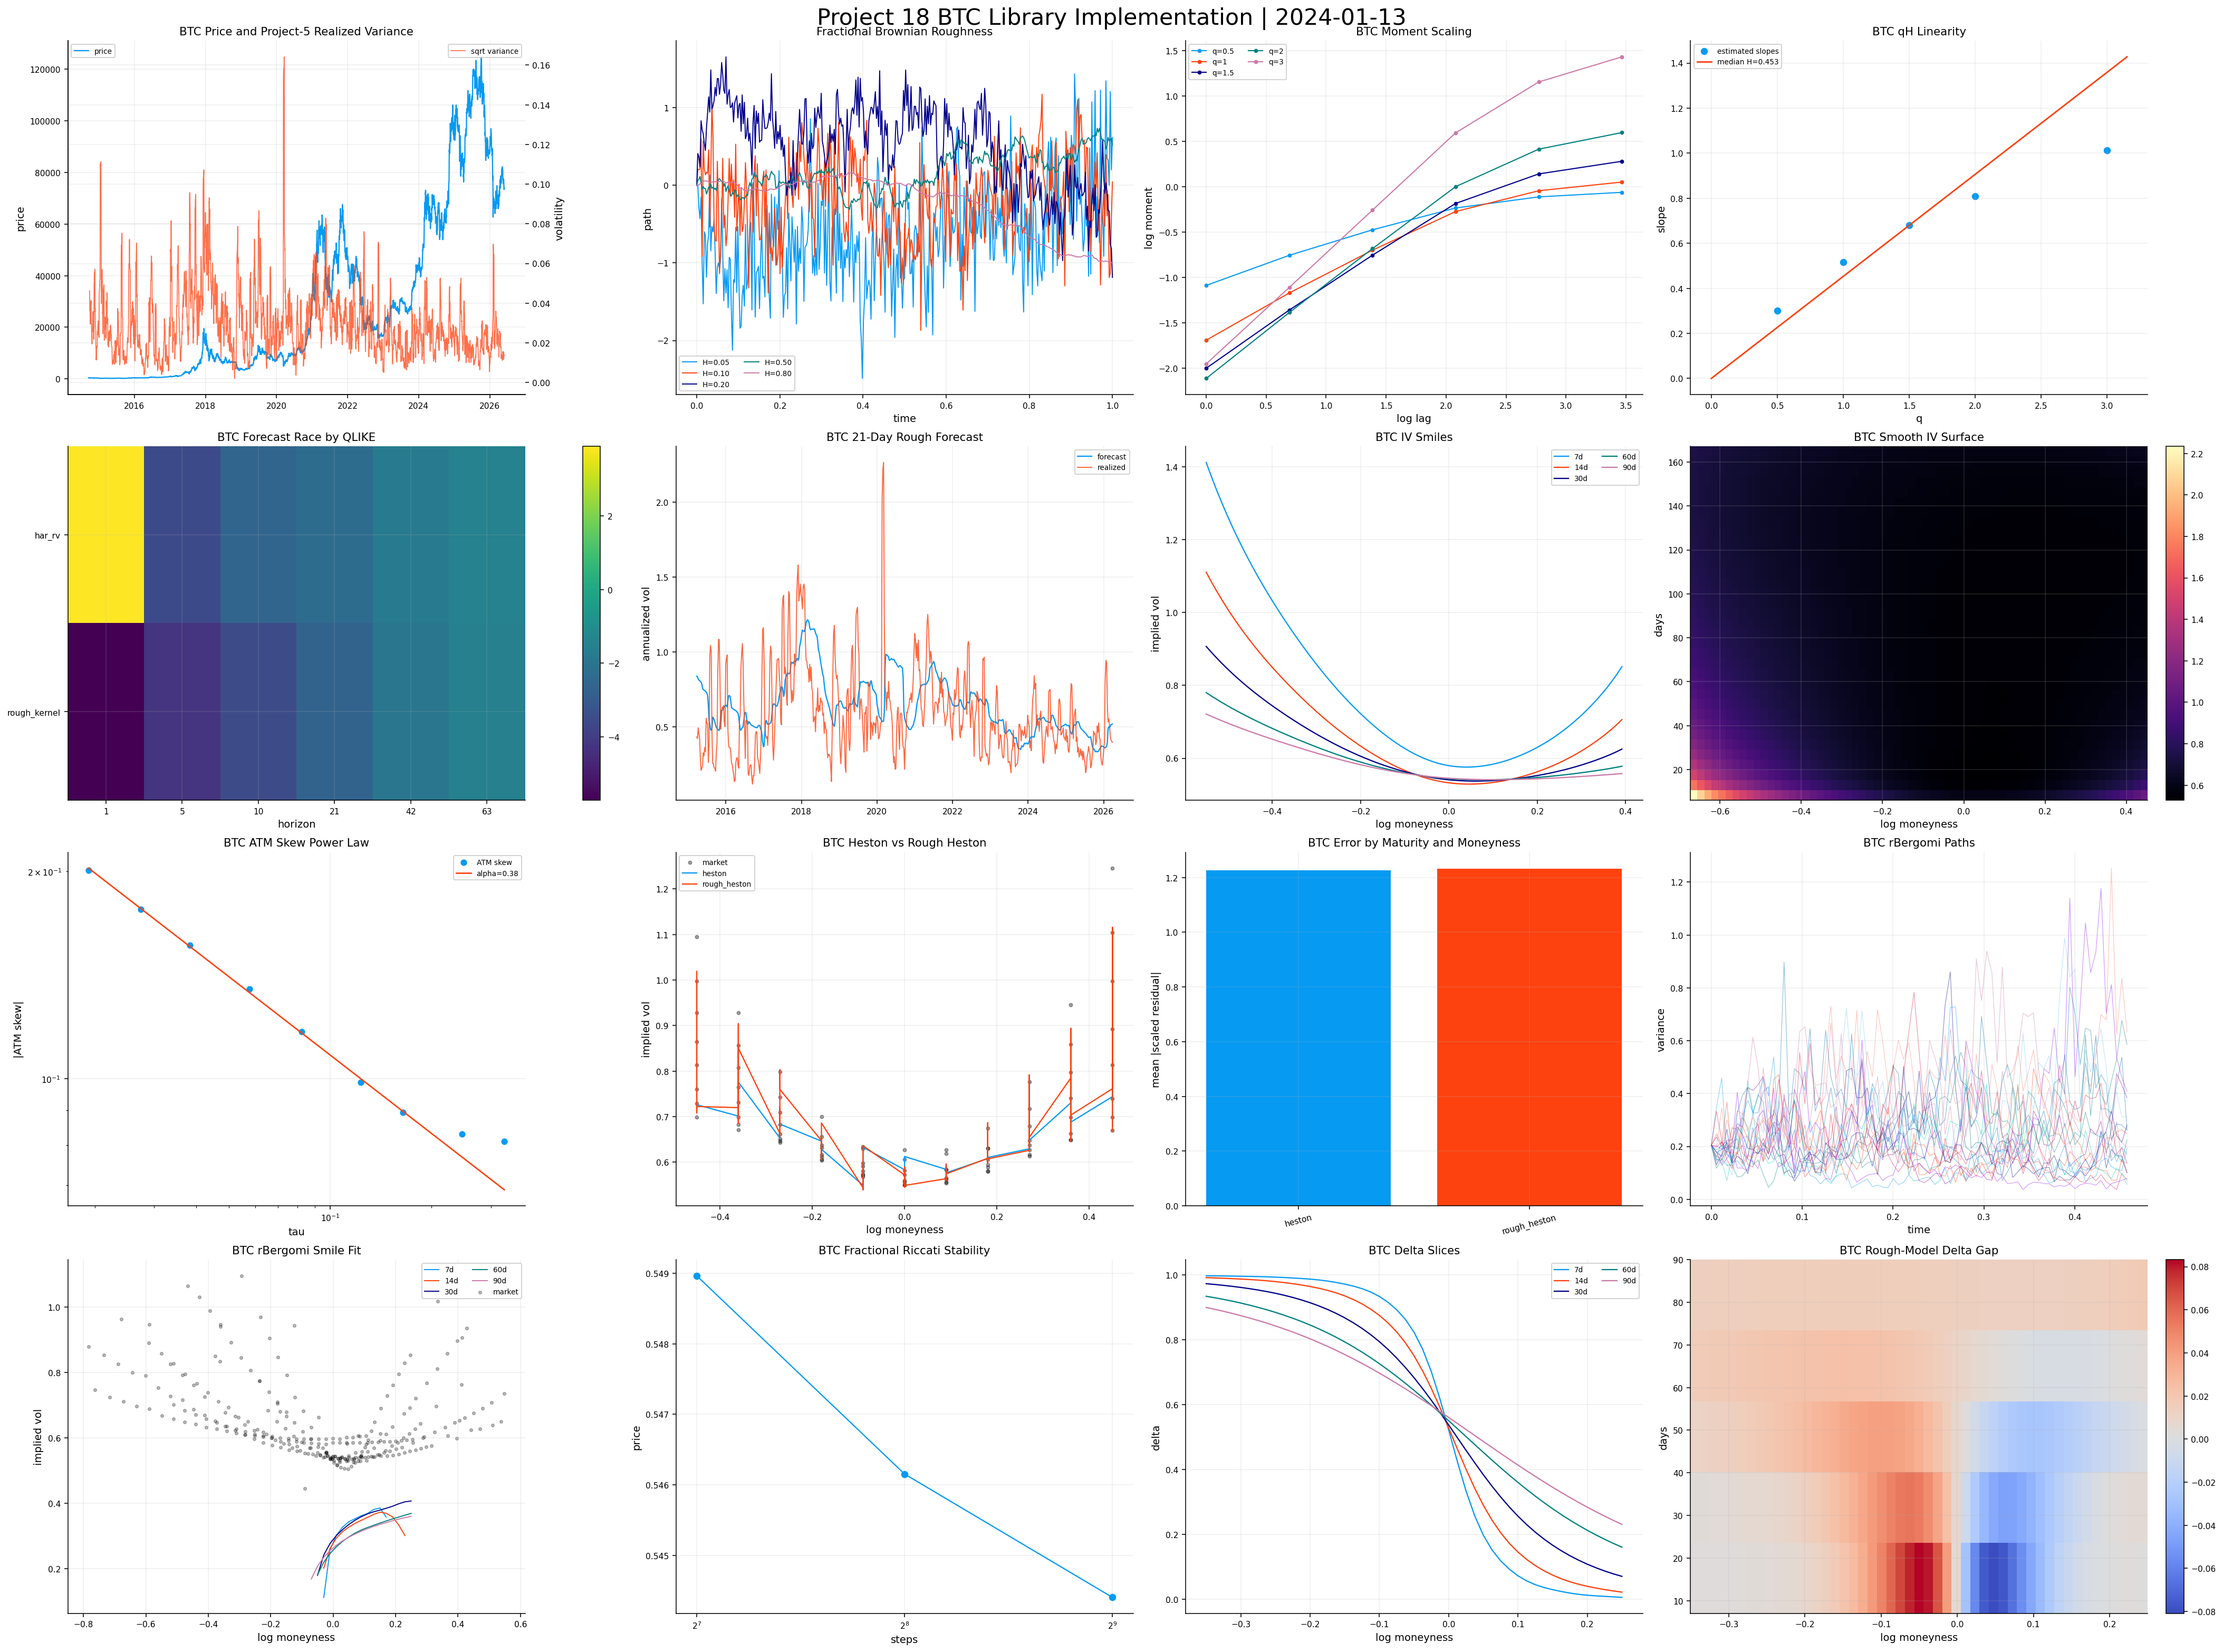

In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from cycler import cycler

from quantfinlab.dataio import load_ohlcv, load_option_chain, load_par_yield_curve
from quantfinlab.volatility.realized import log_returns
from quantfinlab.volatility.forecasting import future_realized_variance, rolling_arch_forecasts_weekly, score_forecasts_by_model
from quantfinlab.volatility.har import rolling_har_forecasts
from quantfinlab.volatility.rough import daily_variance, log_variance, fbm_cholesky_paths, moment_scaling, hurst_from_moments, hurst_from_moments_pooled, rough_kernel_forecasts, rough_forecast_frame
from quantfinlab.options.quote_cleaning import attach_spot_from_series, clean_option_quotes, convert_quotes_to_usd_equivalent, surface_ready_quotes
from quantfinlab.options.rates_dividends import attach_rates, add_discount_factors, infer_carry_from_forward, infer_dividend_yield_from_forward
from quantfinlab.options.parity import infer_forwards_from_parity
from quantfinlab.options.iv import implied_vol_table
from quantfinlab.options.surface import surface_grid, fit_surface_panel, surface_iv_grid, surface_residuals
from quantfinlab.calibration.fft_cos import surface_target_grid_quotes, fit_daily_models, compare_fourier_models, residual_by_bucket
from quantfinlab.options.rough import atm_skew_term_structure, skew_power_law, forward_variance_curve, simulate_rbergomi, rbergomi_smile, rbergomi_calibration, fit_rough_heston_dates, compare_heston_rough_heston, rough_heston_residuals, riccati_convergence, rough_delta_grid
from quantfinlab.plotting.volatility import price_and_variance, fbm_roughness, moment_ladder, hurst_linearity, forecast_race, forecast_path, smile_slices, smooth_surface, skew_power, fit_comparison, maturity_error, rbergomi_paths, rbergomi_fit, riccati_stability, parameter_paths, delta_slices, delta_gap

palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7", "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)

data_dir = Path("../data")
if not data_dir.exists():
    data_dir = Path("data")

cache_dir = data_dir / "cache" / "project18" / "btc"
cache_dir.mkdir(parents=True, exist_ok=True)

ann_days = 365.0
ann_trading = 365
seed = 7
q_values = (0.5, 1.0, 1.5, 2.0, 3.0)
lags = (1, 2, 4, 8, 16, 32)
horizons = (1, 5, 10, 21, 42, 63)

btc_history_path = data_dir / "btc_usd_yfinance_max.csv"
if not btc_history_path.exists():
    btc_history_path = data_dir / "btc_usd_yfinance_2023_10_01_2024_10_15.csv"
btc_spot = load_ohlcv(btc_history_path, source="yfinance_csv", fields=("close",))
btc_raw = load_option_chain(data_dir / "btc_deribit_optiondx_2024_01_09.parquet", source="btc_deribit", annualization_days=ann_days)
us_par_btc = load_par_yield_curve(data_dir / "par-yield-curve-rates-1990-2026.csv", source="us_treasury")

btc_ret = log_returns(btc_spot["close"]).dropna()
btc_var_1d = daily_variance(btc_ret, annualization=ann_trading)
btc_var = (btc_var_1d.rolling(10).sum() / 10.0).dropna().rename("btc_project5_10d_daily_variance")
btc_log_var = log_variance(btc_var)
btc_targets = future_realized_variance(btc_ret, horizons=horizons, annualization=ann_trading)

fbm = fbm_cholesky_paths(h_values=(0.05, 0.10, 0.20, 0.50, 0.80), n_steps=384, n_paths=4, seed=seed)
scaling = moment_scaling(btc_log_var, q_values=q_values, lags=lags)
hurst = hurst_from_moments(scaling, q_col="q", lag_col="lag", moment_col="moment")
hurst_pooled = hurst_from_moments_pooled(scaling)
h = float(np.clip(float(hurst_pooled["H"].iloc[0]) if not hurst_pooled.empty and np.isfinite(float(hurst_pooled["H"].iloc[0])) else hurst["h"].median(), 0.04, 0.35))

train_window = min(180, max(90, len(btc_var) // 2))
rough_fc = rough_kernel_forecasts(btc_var, h=h, horizons=horizons, train_window=train_window, signal_step=7, annualization=ann_trading)
har_fc = rolling_har_forecasts(btc_ret, horizons=horizons, train_window=train_window, refit_every=7, annualization=ann_trading, use_log=True)

btc_forecast_data = rough_forecast_frame(rough_fc=rough_fc, har_fc=har_fc, arch_fc=pd.DataFrame(), rv_targets=btc_targets, horizons=horizons)
forecast_scores = score_forecasts_by_model(btc_forecast_data) if not btc_forecast_data.empty else pd.DataFrame()

btc_quotes = attach_spot_from_series(btc_raw, btc_spot["close"], date_col="date", spot_col="spot", method="previous", overwrite=False)
btc_quotes = convert_quotes_to_usd_equivalent(btc_quotes, unit="base")
btc_unit_audit = pd.DataFrame([{
    "input_file": str(btc_history_path.name),
    "price_unit": str(btc_quotes["price_unit_detected"].iloc[0]),
    "spot_median": float(pd.to_numeric(btc_quotes["spot"], errors="coerce").median()),
    "raw_mid_median_btc": float(pd.to_numeric(btc_quotes["mid_raw"], errors="coerce").replace(0.0, np.nan).median()),
    "usd_mid_median": float(pd.to_numeric(btc_quotes["mid"], errors="coerce").replace(0.0, np.nan).median()),
}])
clean_quotes, clean_steps = clean_option_quotes(btc_quotes, min_dte=3, max_dte=180, moneyness_range=(0.45, 1.75), max_relative_spread=0.60, closest_atm_pairs=90, min_pairs_per_expiry=0, annualization_days=ann_days)
rate_start = clean_quotes["date"].min() - pd.Timedelta(days=30)
rate_end = clean_quotes["date"].max()
us_par_btc = us_par_btc.loc[(us_par_btc.index >= rate_start) & (us_par_btc.index <= rate_end)].copy()
clean_quotes = attach_rates(clean_quotes, us_par_btc, date_col="date", tau_col="tau", out_col="rate")
clean_quotes = add_discount_factors(clean_quotes, rate_col="rate", tau_col="tau", out_col="discount_factor")
clean_quotes = infer_forwards_from_parity(clean_quotes, date_col="date", expiry_col="expiry", strike_col="strike", option_type_col="option_type", mid_col="mid", discount_col="discount_factor", spot_col="spot", out_col="forward")
clean_quotes = infer_carry_from_forward(clean_quotes, spot_col="spot", forward_col="forward", tau_col="tau", out_col="implied_carry")
clean_quotes = infer_dividend_yield_from_forward(clean_quotes, rate_col="rate", carry_col="implied_carry", out_col="implied_dividend_yield")

iv_quotes = implied_vol_table(clean_quotes, price_cols=("bid", "mid", "ask"), option_type_col="option_type", spot_col="spot", forward_col="forward", strike_col="strike", tau_col="tau", rate_col="rate", discount_col="discount_factor", model="black76", engine="auto")
surface_quotes = surface_ready_quotes(iv_quotes, min_iv=0.05, max_iv=3.50, min_tau=3 / ann_days, max_tau=180 / ann_days, min_weight=0.05, max_weight=20.0)

surface_fit = fit_surface_panel(surface_quotes, date_col="date", k_col="k", tau_col="tau", iv_col="iv_mid", weight_col="surface_weight", visual_params=dict(n_k_basis=10, n_tau_basis=7, degree=3, lambda_k=3.0, lambda_tau=2.0), dupire_params=dict(n_k_basis=9, n_tau_basis=6, degree=3, lambda_k=10.0, lambda_tau=16.0), min_quotes=80, min_expiries=4)
visual_fits_by_date = {pd.Timestamp(k).normalize(): v for k, v in surface_fit["visual_fits"].items()}
btc_tau_values = np.array([7, 10, 14, 21, 30, 45, 60, 90, 120], dtype=float) / ann_days
btc_skew_rows = []
for d, fit in visual_fits_by_date.items():
    qd = surface_quotes[surface_quotes["date"].eq(d)].copy()
    psi_d = atm_skew_term_structure(qd, fit=fit, k_col="k", tau_col="tau", iv_col="iv_mid", tau_values=btc_tau_values, dk=0.01)
    for window, lo, hi in [("short_7_60", 7, 60), ("medium_14_90", 14, 90), ("old_14_150", 14, 150)]:
        sub = psi_d[psi_d["tau_days"].between(lo, hi)].copy()
        row = skew_power_law(sub, tau_col="tau", skew_col="atm_skew").iloc[0].to_dict()
        row["date"] = d
        row["window"] = window
        row["h_from_skew"] = row.get("h", np.nan)
        row["quote_count"] = int(len(qd))
        btc_skew_rows.append(row)
btc_skew_history = pd.DataFrame(btc_skew_rows)
surface_summary = surface_fit["fit_summary"]
surface_visual_summary = surface_summary[surface_summary["fit"].eq("visual")].copy() if not surface_summary.empty else pd.DataFrame()
btc_main_candidates = btc_skew_history[btc_skew_history["window"].eq("short_7_60")].copy()
if not surface_visual_summary.empty:
    btc_main_candidates = btc_main_candidates.merge(surface_visual_summary[["date", "weighted_rmse", "quote_count", "number_of_maturities"]], on="date", how="left", suffixes=("", "_surface"))
else:
    btc_main_candidates["weighted_rmse"] = np.nan
    btc_main_candidates["number_of_maturities"] = np.nan
btc_high_quality_skew = btc_main_candidates[btc_main_candidates["r2"].ge(0.80) & btc_main_candidates["n"].ge(6)].copy()
btc_selection_pool = btc_high_quality_skew.copy()
if btc_selection_pool.empty:
    btc_selection_pool = btc_main_candidates[btc_main_candidates["n"].ge(4)].copy()
if btc_selection_pool.empty:
    btc_selection_pool = btc_main_candidates.copy()
btc_selection_pool["surface_quality_rank"] = btc_selection_pool["weighted_rmse"].rank(method="first", ascending=True, na_option="bottom")
main_date = btc_selection_pool.sort_values(["r2", "surface_quality_rank", "quote_count"], ascending=[False, True, False])["date"].iloc[0]
q_main = surface_quotes[surface_quotes["date"].eq(main_date)].copy()
fit_visual = visual_fits_by_date[pd.Timestamp(main_date).normalize()]
k_grid = surface_grid(q_main, k_col="k", tau_col="tau", k_quantiles=(0.02, 0.98), tau_quantiles=(0.02, 0.98), n_k=65, n_tau=35, annualization_days=ann_days)
sigma_grid = surface_iv_grid(fit_visual, k_grid)
surface_err = surface_residuals(q_main, fits={"smooth": fit_visual}, k_col="k", tau_col="tau", iv_col="iv_mid")

psi = atm_skew_term_structure(q_main, fit=fit_visual, k_col="k", tau_col="tau", iv_col="iv_mid", tau_values=btc_tau_values, dk=0.01)
skew_fit = skew_power_law(psi[psi["tau_days"].between(7, 60)], tau_col="tau", skew_col="atm_skew")
xi = forward_variance_curve(q_main, fit=fit_visual, tau_values=np.array([7, 14, 21, 30, 45, 60, 90, 120], dtype=float) / ann_days)

calibration_quotes = surface_target_grid_quotes(
    surface_quotes,
    surface_fit["visual_fits"],
    min_dte=7,
    max_dte=150,
    max_abs_log_moneyness=0.45,
    min_quotes_per_date=45,
    min_source_quotes_per_date=70,
    annualization_days=ann_days,
    iv_floor=0.05,
    iv_cap=3.50,
    iv_error_floor=0.020,
    iv_error_cap=0.140,
    adaptive_k_grid=True,
    adaptive_k_min_nodes=7,
    adaptive_k_max_nodes=11,
)
date_counts = calibration_quotes.groupby("date").size()
eligible_btc_fit_dates = date_counts[date_counts >= 45].index.sort_values()
if len(eligible_btc_fit_dates) > 12:
    fit_dates = eligible_btc_fit_dates[np.linspace(0, len(eligible_btc_fit_dates) - 1, 12).round().astype(int)]
else:
    fit_dates = eligible_btc_fit_dates
h_skew_main = float(skew_fit["h"].iloc[0]) if not skew_fit.empty and np.isfinite(skew_fit["h"].iloc[0]) else h
btc_h_source = btc_high_quality_skew.copy()
if btc_h_source.empty:
    btc_h_source = btc_main_candidates[btc_main_candidates["r2"].ge(0.70)].copy()
btc_h_source = btc_h_source[btc_h_source["h_from_skew"].between(0.04, 0.45)].copy()
btc_h_by_date = btc_h_source.set_index("date")["h_from_skew"].dropna().sort_index()

btc_heston_cache = cache_dir / "btc_heston_surface_grid_daily.parquet"
btc_heston_fit_cache = cache_dir / "btc_heston_surface_grid_fit.parquet"
btc_rough_cache = cache_dir / "btc_rough_heston_surface_grid_skew_anchor_v2_daily.parquet"
btc_rough_fit_cache = cache_dir / "btc_rough_heston_surface_grid_skew_anchor_v2_fit.parquet"

if btc_heston_cache.exists() and btc_heston_fit_cache.exists():
    heston_daily = pd.read_parquet(btc_heston_cache)
    heston_prices = pd.read_parquet(btc_heston_fit_cache)
else:
    heston_out = fit_daily_models(calibration_quotes, ["heston"], calibration_dates=fit_dates, min_quotes=45, max_nfev=18, engine="cpp", n_terms=112, truncation_width=16.0)
    heston_daily = heston_out["params"]
    heston_prices = heston_out["fit"]
    heston_daily.to_parquet(btc_heston_cache, index=False)
    heston_prices.to_parquet(btc_heston_fit_cache, index=False)

if btc_rough_cache.exists() and btc_rough_fit_cache.exists():
    rough_daily = pd.read_parquet(btc_rough_cache)
    rough_prices = pd.read_parquet(btc_rough_fit_cache)
else:
    rough_out = fit_rough_heston_dates(calibration_quotes, calibration_dates=fit_dates, h_start=h_skew_main, h_by_date=btc_h_by_date, h_mode="fixed", min_quotes=45, max_nfev=14, engine="cpp", n_terms=88, truncation_width=16.0, riccati_steps=192, lambda_skew=3.0, surface_fit_map=surface_fit["visual_fits"])
    rough_daily = rough_out["params"]
    rough_prices = rough_out["fit"]
    rough_daily.to_parquet(btc_rough_cache, index=False)
    rough_prices.to_parquet(btc_rough_fit_cache, index=False)

model_table = compare_heston_rough_heston(heston_daily=heston_daily, rough_daily=rough_daily)
heston_table = compare_fourier_models(daily=heston_daily)
heston_buckets = residual_by_bucket(heston_prices)
rough_buckets = rough_heston_residuals(rough_prices, scale_col="calib_scale_px")
rough_valid = rough_daily[
    rough_daily["success"].astype(bool)
    & pd.to_numeric(rough_daily.get("weighted_price_rmse"), errors="coerce").replace([np.inf, -np.inf], np.nan).notna()
    & pd.to_numeric(rough_daily.get("finite_price_share", pd.Series(1.0, index=rough_daily.index)), errors="coerce").ge(0.999)
].copy()
if rough_valid.empty:
    rough_valid = rough_daily[pd.to_numeric(rough_daily.get("weighted_price_rmse"), errors="coerce").replace([np.inf, -np.inf], np.nan).notna()].copy()
if rough_valid.empty:
    raise RuntimeError("No finite BTC rough-Heston parameter row is available for diagnostics.")
display_date = pd.Timestamp(main_date).normalize()
if display_date not in set(pd.to_datetime(rough_valid["date"]).dt.normalize()):
    display_date = pd.Timestamp(rough_valid.sort_values("weighted_price_rmse")["date"].iloc[0]).normalize()
rough_fit = rough_prices[rough_prices["date"].eq(display_date)].copy()
heston_fit = heston_prices[heston_prices["date"].eq(display_date)].copy()
q_main_target = calibration_quotes[calibration_quotes["date"].eq(pd.Timestamp(main_date).normalize())].copy()
if q_main_target.empty:
    q_main_target = q_main.copy()
rough_param_row = rough_valid[rough_valid["date"].eq(display_date)].sort_values("weighted_price_rmse").iloc[0]
riccati_test = riccati_convergence(q_main_target, params=rough_param_row, n_grid_values=(128, 256, 512), n_terms=96, engine="cpp")

rbergomi = rbergomi_calibration(q_main_target, xi=xi, h_start=h_skew_main, nu_start=2.0, rho_start=-0.70, paths=5200, steps=88, restarts=6, seed=seed, engine="numba", use_sobol=True, lambda_skew=1.0)
rbergomi_sim = simulate_rbergomi(spot=float(q_main["spot"].median()), xi=xi, h=float(rbergomi["params"]["h"]), nu=float(rbergomi["params"]["nu"]), rho=float(rbergomi["params"]["rho"]), tau=float(np.nanmax(q_main["tau"])), paths=1200, steps=80, seed=seed, engine="numba", rate=float(q_main["rate"].median()), dividend_yield=float(q_main["implied_dividend_yield"].median()), antithetic=True)
rbergomi_iv = rbergomi_smile(q_main_target, xi=xi, params=rbergomi["params"], maturity_days=(7, 14, 30, 60, 90), paths=3000, steps=88, seed=seed, engine="numba")

delta_map = rough_delta_grid(q_main, heston_params=heston_daily.dropna().iloc[-1], rough_params=rough_param_row, rbergomi_params=rbergomi["params"], xi=xi, surface_fit=fit_visual, k_values=np.linspace(-0.35, 0.25, 49), tau_days=np.array([7, 14, 30, 60, 90], dtype=float), n_terms=96, riccati_steps=192, bump=0.005, paths=2500, steps=80, seed=seed, engine="cpp", mc_engine="numba")

summary = pd.DataFrame([{"asset": "BTC", "spot_start": float(btc_spot["close"].dropna().iloc[0]), "spot_end": float(btc_spot["close"].dropna().iloc[-1]), "return_days": int(btc_ret.shape[0]), "option_rows_clean": int(clean_quotes.shape[0]), "surface_rows": int(surface_quotes.shape[0]), "surface_target_rows": int(calibration_quotes.shape[0]), "main_date": pd.Timestamp(main_date).date(), "main_date_rule": "best short-skew R2 with surface RMSE tiebreak", "h_from_rv": float(h), "h_from_skew": float(skew_fit["h"].iloc[0]), "h_used_for_rough_heston": float(h_skew_main), "skew_r2": float(skew_fit["r2"].iloc[0]), "skew_high_quality_dates": int(len(btc_high_quality_skew)), "rough_dates": int(rough_daily["date"].nunique()), "heston_dates": int(heston_daily["date"].nunique())}])

for name, table in {"summary": summary, "btc_unit_audit": btc_unit_audit, "hurst": hurst, "forecast_scores": forecast_scores.sort_values(["horizon", "qlike_var"]).head(20) if not forecast_scores.empty else forecast_scores, "btc_skew_history": btc_skew_history.sort_values(["window", "r2"], ascending=[True, False]).head(12), "skew_fit": skew_fit, "model_table": model_table, "heston_table": heston_table, "rbergomi_params": pd.DataFrame([rbergomi["params"]]), "rbergomi_restart_loss": rbergomi["fit"], "riccati_test": riccati_test, "delta_sample": delta_map[np.isclose(delta_map["k"], 0.0, atol=0.015)].copy()}.items():
    print(name)
    display(table)

fig, axes = plt.subplots(4, 4, figsize=(30, 22), constrained_layout=True)
axes = axes.ravel()
price_and_variance(axes[0], btc_spot, btc_var, title="BTC Price and Project-5 Realized Variance")
fbm_roughness(axes[1], fbm, title="Fractional Brownian Roughness")
moment_ladder(axes[2], scaling, title="BTC Moment Scaling")
hurst_linearity(axes[3], hurst, title="BTC qH Linearity")
forecast_race(axes[4], forecast_scores, metric="qlike_var", title="BTC Forecast Race by QLIKE")
forecast_path(axes[5], btc_forecast_data, model="rough_kernel", horizon=21, title="BTC 21-Day Rough Forecast")
smile_slices(axes[6], q_main, fit=fit_visual, maturities_days=(7, 14, 30, 60, 90), title="BTC IV Smiles")
smooth_surface(axes[7], k_grid, sigma_grid, q_main, title="BTC Smooth IV Surface")
skew_power(axes[8], psi, skew_fit, title="BTC ATM Skew Power Law")
fit_comparison(axes[9], heston_fit, rough_fit, title="BTC Heston vs Rough Heston")
maturity_error(axes[10], heston_buckets, rough_buckets, title="BTC Error by Maturity and Moneyness")
rbergomi_paths(axes[11], rbergomi_sim, title="BTC rBergomi Paths")
rbergomi_fit(axes[12], rbergomi_iv, q_main, title="BTC rBergomi Smile Fit")
riccati_stability(axes[13], riccati_test, title="BTC Fractional Riccati Stability")
delta_slices(axes[14], delta_map, title="BTC Delta Slices")
delta_gap(axes[15], delta_map, base_col="surface_bsm_delta", title="BTC Rough-Model Delta Gap")
fig.suptitle(f"Project 18 BTC Library Implementation | {pd.Timestamp(main_date).date()}", fontsize=22, y=1.01)
plt.show()
